# Crazyhouse Tactical Retrieval — Full Pipeline Notebook

This notebook contains every script in the project in execution order.  
Run each section sequentially to go from raw PGN files all the way to the running Flask app.

> **Library modules** (`encode.py`, `encodev2.py`, `engine_wrapper.py`) are included at the bottom — they are **not run directly**, but must be present in your `src/` directory.

---


## Phase 1 — Data Mining (Raw PGNs → Tactical Positions)

Mine tactical events from all monthly Lichess Crazyhouse PGN files using Fairy-Stockfish.


### 1. `tactic_miner_full.py`
Mines all monthly PGN files for tactical events (CP swings). Writes `tactics_full.jsonl`.

> **Requires:** Fairy-Stockfish engine binary, PGN files in `db/`

In [ ]:
"""
tactic_miner_full.py
--------------------
Mine tactical events from ALL monthly PGN files in the db/ folder.

Key differences from tactic_miner.py:
  - Iterates over every lichess_db_crazyhouse_rated_*.pgn in db/
  - No hard cap on number of tactics (mines everything)
  - Resume support: skips games whose site ID is already in the output file
  - Progress is written line-by-line (safe to Ctrl-C and restart)
  - Writes to tactics_full.jsonl (separate from the old tactics_1k.jsonl)
  - Prints a per-file summary and a grand total at the end

Usage:
    python tactic_miner_full.py

Tunable constants (top of file):
    MAX_PLIES          - ignore moves beyond this ply (avoids very long games)
    MOVETIME_MS        - engine think time per position in milliseconds
    DELTA_CP_THRESHOLD - minimum centipawn swing to record a tactical event
"""

from pathlib import Path
import chess.pgn
import chess.variant
import orjson
from tqdm import tqdm

from engine_wrapper import FairyStockfish

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
ROOT        = Path(__file__).resolve().parents[1]
DB_DIR      = ROOT.parents[0] / "db"           # magistrska/db  (monthly PGNs live here)
OUT_JSONL   = ROOT / "data" / "derived" / "tactics_full.jsonl"
ENGINE_PATH = next((ROOT / "engines").glob("fairy-stockfish-largeboard_x86-64*"))

# ---------------------------------------------------------------------------
# Tunable parameters
# ---------------------------------------------------------------------------
MAX_PLIES          = 80    # only analyse the first N plies of each game
MOVETIME_MS        = 80    # ms per engine call (keep low for large-scale mining)
DELTA_CP_THRESHOLD = 500   # centipawn loss threshold to flag a tactical event

# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def score_to_cp(cp, mate) -> float | None:
    """Normalise engine output to a single numeric scale (side-to-move perspective)."""
    if mate is not None:
        return 100_000.0 if mate > 0 else -100_000.0
    if cp is None:
        return None
    return float(cp)


def load_seen_sites(path: Path) -> set[str]:
    """
    Read already-written output and collect every site ID that was recorded.
    This allows safe resume: run the script again after a crash/stop and it
    will skip all games that produced at least one event in a previous run.

    NOTE: A game that produced ZERO events will be re-analysed on resume
    (we have no record of it).  That is acceptable — it is just a small amount
    of redundant engine work.
    """
    seen = set()
    if not path.exists():
        return seen
    with path.open("rb") as f:
        for raw in f:
            raw = raw.strip()
            if not raw:
                continue
            try:
                rec = orjson.loads(raw)
                seen.add(rec["site"])
            except Exception:
                pass
    return seen


def iter_pgn_files(db_dir: Path):
    """Yield PGN files sorted chronologically (they are named by month)."""
    files = sorted(db_dir.glob("lichess_db_crazyhouse_rated_*.pgn"))
    if not files:
        raise FileNotFoundError(f"No crazyhouse PGN files found in {db_dir}")
    return files


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main():
    OUT_JSONL.parent.mkdir(parents=True, exist_ok=True)

    pgn_files = iter_pgn_files(DB_DIR)
    print(f"Found {len(pgn_files)} PGN file(s) in {DB_DIR}:")
    for p in pgn_files:
        print(f"  {p.name}")

    # Resume: collect site IDs already present in the output file
    seen_sites = load_seen_sites(OUT_JSONL)
    print(f"\nResume: {len(seen_sites)} site(s) already processed — will skip them.\n")

    eng = FairyStockfish(str(ENGINE_PATH))
    eng.new_game()

    total_games   = 0
    total_skipped = 0
    total_found   = 0

    # Open output in append mode so resume works correctly
    with OUT_JSONL.open("ab") as out:

        for pgn_path in pgn_files:
            file_games   = 0
            file_skipped = 0
            file_found   = 0

            print(f"\n{'='*60}")
            print(f"Processing: {pgn_path.name}")
            print(f"{'='*60}")

            with pgn_path.open("r", encoding="utf-8", errors="replace") as f:
                pbar = tqdm(desc=f"  Games ({pgn_path.stem[-7:]})", unit="game")

                while True:
                    game = chess.pgn.read_game(f)
                    if game is None:
                        break

                    site  = game.headers.get("Site", "?")
                    white = game.headers.get("White")
                    black = game.headers.get("Black")

                    file_games += 1
                    pbar.update(1)

                    # Resume: skip if we already have events from this game
                    if site in seen_sites:
                        file_skipped += 1
                        continue

                    board      = chess.variant.CrazyhouseBoard()
                    uci_prefix = []
                    game_found = 0

                    for ply_idx, move in enumerate(game.mainline_moves(), start=1):
                        if ply_idx > MAX_PLIES:
                            break
                        if board.is_game_over():
                            break

                        prefix_before = uci_prefix.copy()

                        cp_before, mate_before, best_before, pv_before = eng.analyze_moves(
                            prefix_before,
                            movetime_ms=MOVETIME_MS,
                        )
                        s_before = score_to_cp(cp_before, mate_before)

                        if s_before is None:
                            try:
                                board.push(move)
                                uci_prefix.append(move.uci())
                            except Exception:
                                break
                            continue

                        played_uci = move.uci()

                        try:
                            board.push(move)
                            uci_prefix.append(played_uci)
                        except Exception:
                            break

                        if board.is_game_over():
                            continue

                        cp_after, mate_after, best_after, pv_after = eng.analyze_moves(
                            uci_prefix,
                            movetime_ms=MOVETIME_MS,
                        )
                        s_after = score_to_cp(cp_after, mate_after)
                        if s_after is None:
                            continue

                        after_for_mover  = -s_after
                        loss_for_mover   = s_before - after_for_mover

                        if loss_for_mover >= DELTA_CP_THRESHOLD:
                            rec = {
                                "event_id":            f"{site}_{ply_idx}",
                                "site":                site,
                                "white":               white,
                                "black":               black,
                                "ply":                 ply_idx,
                                "uci_moves":           prefix_before,
                                "played_move":         played_uci,
                                "bestmove_before":     best_before,
                                "pv_before":           (pv_before or [])[:12],
                                "cp_before":           cp_before,
                                "mate_before":         mate_before,
                                "cp_after":            cp_after,
                                "mate_after":          mate_after,
                                "score_before_stm":    s_before,
                                "score_after_stm":     s_after,
                                "score_after_for_mover": after_for_mover,
                                "delta":               loss_for_mover,
                                # track which source file this came from
                                "source_pgn":          pgn_path.name,
                            }
                            out.write(orjson.dumps(rec) + b"\n")
                            out.flush()   # ensure data is on disk after each record
                            game_found += 1
                            file_found += 1
                            total_found += 1

                    # Mark site as seen so we won't re-process it on resume
                    seen_sites.add(site)
                    file_skipped += (game_found == 0)  # no-event games are "implicitly" processed

                pbar.close()

            total_games   += file_games
            total_skipped += file_skipped

            print(f"  Games in file : {file_games}")
            print(f"  Skipped (resume): {file_skipped}")
            print(f"  Tactics found : {file_found}")

    eng.close()

    print(f"\n{'='*60}")
    print("GRAND TOTAL")
    print(f"  PGN files processed : {len(pgn_files)}")
    print(f"  Games seen          : {total_games}")
    print(f"  Tactics written     : {total_found}")
    print(f"  Output              : {OUT_JSONL}")
    print(f"{'='*60}")


if __name__ == "__main__":
    main()


### 2. `augment_tactics_full.py`
Rebuilds board state, pockets, and FEN for each mined tactic. Writes `tactics_full_aug.jsonl`.

In [ ]:
"""
augment_tactics_full.py
-----------------------
Augments tactics_full.jsonl (mined from all monthly PGNs) with
reconstructed board state, pockets, and FEN.

Identical logic to augment_tactics.py — only the input/output paths differ.
"""

from pathlib import Path
import json
import chess
import chess.variant

ROOT = Path(__file__).resolve().parents[1]
INP  = ROOT / "data" / "derived" / "tactics_full.jsonl"
OUT  = ROOT / "data" / "derived" / "tactics_full_aug.jsonl"


PIECE_LETTERS = {
    chess.PAWN:   "P",
    chess.KNIGHT: "N",
    chess.BISHOP: "B",
    chess.ROOK:   "R",
    chess.QUEEN:  "Q",
}


def pocket_counts(pocket) -> dict:
    d = {}
    for pt, letter in PIECE_LETTERS.items():
        n = pocket.count(pt)
        if n:
            d[letter] = int(n)
    return d


def reconstruct_event_board(rec: dict):
    uci_moves = rec.get("uci_moves") or rec.get("uci_moves_prefix") or []
    ply       = rec.get("ply")

    board = chess.variant.CrazyhouseBoard()

    if not isinstance(uci_moves, list):
        raise ValueError("uci_moves is not a list")

    prefix = uci_moves[: max(0, ply - 1)] if isinstance(ply, int) and ply > 0 else uci_moves

    for u in prefix:
        mv = board.parse_uci(u)
        board.push(mv)

    return board, prefix


def main():
    OUT.parent.mkdir(parents=True, exist_ok=True)

    n_in = n_ok = n_bad = n_terminal = 0

    with INP.open("r", encoding="utf-8", errors="replace") as f, \
         OUT.open("w", encoding="utf-8") as out:

        for line in f:
            line = line.strip()
            if not line:
                continue
            n_in += 1

            try:
                rec = json.loads(line)
            except Exception:
                n_bad += 1
                continue

            try:
                board, prefix = reconstruct_event_board(rec)
            except Exception:
                n_bad += 1
                continue

            if board.is_game_over():
                n_terminal += 1
                continue

            rec2 = dict(rec)
            rec2["event_id"]       = rec.get("event_id") or f"{rec.get('site', '?')}_{rec.get('ply', '?')}"
            rec2["uci_moves_prefix"] = prefix
            rec2["board_fen"]      = board.board_fen()
            rec2["turn"]           = "white" if board.turn == chess.WHITE else "black"
            rec2["pockets_white"]  = pocket_counts(board.pockets[chess.WHITE])
            rec2["pockets_black"]  = pocket_counts(board.pockets[chess.BLACK])
            try:
                rec2["fen"] = board.fen()
            except Exception:
                rec2["fen"] = None

            out.write(json.dumps(rec2, ensure_ascii=False) + "\n")
            n_ok += 1

            if n_ok % 5000 == 0:
                print(f"  augmented: {n_ok} …")

    print("DONE")
    print(f"  in:               {n_in}")
    print(f"  augmented (ok):   {n_ok}")
    print(f"  bad/parse errors: {n_bad}")
    print(f"  terminal skipped: {n_terminal}")
    print(f"  out:              {OUT}")


if __name__ == "__main__":
    main()


### 3. `filter_tactics_full.py`
Keeps only Crazyhouse-relevant positions (drop in solution or non-empty pocket). Writes `tactics_full_tactical.jsonl`.

In [ ]:
"""
filter_tactics_full.py
----------------------
Filters tactics_full_aug.jsonl to keep only Crazyhouse-relevant positions
(drop in PV/bestmove, or non-empty pocket on either side).

Identical logic to filter_tactics.py — only the input/output paths differ.
"""

from pathlib import Path
import json

ROOT = Path(__file__).resolve().parents[1]
INP  = ROOT / "data" / "derived" / "tactics_full_aug.jsonl"
OUT  = ROOT / "data" / "derived" / "tactics_full_tactical.jsonl"


def pockets_nonempty(p):
    return bool(p) and sum(int(v) for v in p.values()) > 0


def main():
    OUT.parent.mkdir(parents=True, exist_ok=True)

    total = kept = kept_drop = kept_pockets = 0

    with INP.open("r", encoding="utf-8", errors="replace") as f, \
         OUT.open("w", encoding="utf-8") as out:

        for line in f:
            line = line.strip()
            if not line:
                continue
            total += 1

            try:
                r = json.loads(line)
            except Exception:
                continue

            pv = r.get("pv_before") or r.get("pv_prev") or []
            bm = r.get("bestmove_before") or r.get("best_prev") or ""

            has_drop    = any("@" in m for m in pv[:10]) or ("@" in bm)
            has_pockets = (
                pockets_nonempty(r.get("pockets_white", {})) or
                pockets_nonempty(r.get("pockets_black", {}))
            )

            if has_drop or has_pockets:
                out.write(json.dumps(r, ensure_ascii=False) + "\n")
                kept += 1
                if has_drop:
                    kept_drop += 1
                if has_pockets:
                    kept_pockets += 1

            if total % 10_000 == 0:
                print(f"  processed: {total}, kept: {kept} …")

    print("DONE")
    print(f"  total:          {total}")
    print(f"  kept:           {kept}")
    print(f"  kept_by_drop:   {kept_drop}")
    print(f"  kept_by_pocket: {kept_pockets}")
    print(f"  out:            {OUT}")


if __name__ == "__main__":
    main()


---
## Phase 2 — Checkmate Corpus Building

Mine and verify forced mate-in-5 positions directly from PGNs.


### 4. `miner_v2.py`
Fast parallel pipeline: mines checkmate positions from PGNs with no engine calls. Writes `checkmates5.jsonl`.

> **Note:** Modern, faster alternative to Phase 1 for mate-in-N specifically.

In [ ]:
"""
mine_checkmates.py
------------------
Fast parallel pipeline: mine + augment + filter in one pass.
Zero engine calls — pure board logic only.

How it works
------------
1. Termination filter  — skip time forfeits/resignations instantly.
                         Only process Termination = "Normal" games.
2. Checkmate filter    — replay full game, confirm final position is
                         actual checkmate via board.is_checkmate().
3. Solution            — last MATE_IN_PLIES moves actually played.
                         Guaranteed to end in checkmate. No engine needed.
4. Crazyhouse filter   — keep only positions where Crazyhouse mechanics
                         are in play (drop in solution or pocket non-empty).
5. Deduplication       — hash table of seen site URLs, persists on resume.
6. Multiprocessing     — one worker per CPU core, no engine overhead at all.

Usage
-----
    python mine_checkmates.py
    WORKERS=4 python mine_checkmates.py

Output
------
    data/derived/checkmates5.jsonl   — one JSON line per qualifying puzzle

Schema
------
  event_id          "{site}_mate5"
  site / event / white / black / result
  utc_date / utc_time
  white_elo / black_elo / game_rating_avg
  white_rating_diff / black_rating_diff
  white_title / black_title
  time_control / termination / variant
  puzzle_url        None (not in monthly PGN dumps)
  ply               1-indexed ply of puzzle start position
  turn              "white" or "black" (who delivers mate)
  uci_moves         all moves before the puzzle starts
  solution_uci      last 5 UCI moves of the game (ends in checkmate)
  solution_san      same in SAN notation
  board_fen         board FEN at puzzle start
  fen               full Crazyhouse FEN at puzzle start
  pockets_white / pockets_black
  mate_in           5 (always)
  bestmove_before   first move of the solution
  source_pgn        source PGN filename
"""

import io
import os
import queue
import multiprocessing as mp
from pathlib import Path
from typing import Optional

import chess
import chess.pgn
import chess.variant
import orjson

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
ROOT        = Path(__file__).resolve().parents[1]
DB_DIR      = ROOT.parents[0] / "db"
OUT_JSONL   = ROOT / "data" / "derived" / "checkmates5.jsonl"

# ---------------------------------------------------------------------------
# Tunable parameters
# ---------------------------------------------------------------------------
MATE_IN_PLIES = 5
WORKERS       = int(os.environ.get("WORKERS", max(1, mp.cpu_count() - 1)))

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------
PIECE_LETTERS = {
    chess.PAWN:   "P",
    chess.KNIGHT: "N",
    chess.BISHOP: "B",
    chess.ROOK:   "R",
    chess.QUEEN:  "Q",
}


# ===========================================================================
# Helpers
# ===========================================================================

def _pocket_counts(pocket) -> dict:
    d = {}
    for pt, letter in PIECE_LETTERS.items():
        n = pocket.count(pt)
        if n:
            d[letter] = int(n)
    return d


def _safe_int(s) -> Optional[int]:
    try:
        return int(s)
    except (TypeError, ValueError):
        return None


def _extract_headers(game: chess.pgn.Game) -> dict:
    h  = game.headers
    we = _safe_int(h.get("WhiteElo"))
    be = _safe_int(h.get("BlackElo"))
    return {
        "event":              h.get("Event"),
        "site":               h.get("Site", "?"),
        "white":              h.get("White"),
        "black":              h.get("Black"),
        "result":             h.get("Result"),
        "utc_date":           h.get("UTCDate"),
        "utc_time":           h.get("UTCTime"),
        "white_elo":          we,
        "black_elo":          be,
        "white_rating_diff":  _safe_int(h.get("WhiteRatingDiff")),
        "black_rating_diff":  _safe_int(h.get("BlackRatingDiff")),
        "white_title":        h.get("WhiteTitle"),
        "black_title":        h.get("BlackTitle"),
        "time_control":       h.get("TimeControl"),
        "termination":        h.get("Termination"),
        "variant":            h.get("Variant", "Crazyhouse"),
        "game_rating_avg":    (we + be) // 2 if (we and be) else None,
        "puzzle_url":         None,
    }


def _uci_to_san(board_before: chess.variant.CrazyhouseBoard, uci_moves: list) -> list:
    b, san = board_before.copy(), []
    for uci in uci_moves:
        try:
            mv = b.parse_uci(uci)
            san.append(b.san(mv))
            b.push(mv)
        except Exception:
            san.append(uci)
    return san


def _pockets_nonempty(p: dict) -> bool:
    return bool(p) and any(v > 0 for v in p.values())


def _is_crazyhouse_relevant(sol_uci: list, pw: dict, pb: dict) -> bool:
    return (
        any("@" in m for m in sol_uci)
        or _pockets_nonempty(pw)
        or _pockets_nonempty(pb)
    )


# ===========================================================================
# Worker — no engine, pure board logic
# ===========================================================================

def _worker(task_q: mp.Queue, result_q: mp.Queue):
    while True:
        item = task_q.get()
        if item is None:
            break

        pgn_text, pgn_name = item
        game = chess.pgn.read_game(io.StringIO(pgn_text))
        if game is None:
            result_q.put(None)
            continue

        headers = _extract_headers(game)

        # Filter 1: only games that ended normally
        if headers.get("termination") != "Normal":
            result_q.put(None)
            continue

        all_moves = list(game.mainline_moves())

        # Filter 2: enough moves for a puzzle
        if len(all_moves) < MATE_IN_PLIES + 1:
            result_q.put(None)
            continue

        # Filter 3: replay and confirm actual checkmate
        board   = chess.variant.CrazyhouseBoard()
        uci_all = []
        ok      = True
        for mv in all_moves:
            try:
                board.push(mv)
                uci_all.append(mv.uci())
            except Exception:
                ok = False
                break

        if not ok or not board.is_checkmate():
            result_q.put(None)
            continue

        # Solution = last MATE_IN_PLIES moves actually played
        candidate_uci = uci_all[:-MATE_IN_PLIES]
        solution_uci  = uci_all[-MATE_IN_PLIES:]
        ply_idx       = len(candidate_uci) + 1

        # Reconstruct board at puzzle start position
        board_snap = chess.variant.CrazyhouseBoard()
        for u in candidate_uci:
            try:
                board_snap.push(board_snap.parse_uci(u))
            except Exception:
                ok = False
                break

        if not ok:
            result_q.put(None)
            continue

        pw = _pocket_counts(board_snap.pockets[chess.WHITE])
        pb = _pocket_counts(board_snap.pockets[chess.BLACK])

        # Filter 4: must involve Crazyhouse mechanics
        if not _is_crazyhouse_relevant(solution_uci, pw, pb):
            result_q.put(None)
            continue

        rec = {
            "event_id":        f"{headers['site']}_mate{MATE_IN_PLIES}",
            "mate_in":         MATE_IN_PLIES,
            "source_pgn":      pgn_name,
            **headers,
            "ply":             ply_idx,
            "turn":            "white" if board_snap.turn == chess.WHITE else "black",
            "uci_moves":       candidate_uci,
            "solution_uci":    solution_uci,
            "solution_san":    _uci_to_san(board_snap, solution_uci),
            "board_fen":       board_snap.board_fen(),
            "fen":             board_snap.fen(),
            "pockets_white":   pw,
            "pockets_black":   pb,
            "bestmove_before": solution_uci[0],
        }

        result_q.put(rec)


# ===========================================================================
# Main
# ===========================================================================

def _load_seen(path: Path) -> set:
    seen = set()
    if not path.exists():
        return seen
    with path.open("rb") as f:
        for raw in f:
            raw = raw.strip()
            if not raw:
                continue
            try:
                seen.add(orjson.loads(raw)["site"])
            except Exception:
                pass
    return seen


def main():
    from tqdm import tqdm

    OUT_JSONL.parent.mkdir(parents=True, exist_ok=True)

    pgn_files = sorted(DB_DIR.glob("lichess_db_crazyhouse_rated_*.pgn"))
    if not pgn_files:
        raise FileNotFoundError(f"No PGN files found in {DB_DIR}")

    print(f"Found {len(pgn_files)} PGN file(s)  |  workers: {WORKERS}")
    print(f"Mate-in: {MATE_IN_PLIES}  |  no engine — pure board logic\n")

    seen_sites = _load_seen(OUT_JSONL)
    print(f"Resume: {len(seen_sites)} sites already done.\n")

    task_q   = mp.Queue(maxsize=WORKERS * 8)
    result_q = mp.Queue()

    procs = []
    for _ in range(WORKERS):
        p = mp.Process(target=_worker, args=(task_q, result_q), daemon=True)
        p.start()
        procs.append(p)

    total_games = total_written = total_skipped = 0
    pending = 0

    overall = tqdm(
        total=len(pgn_files),
        desc="PGN files",
        unit="file",
        position=0,
        colour="cyan",
    )

    def drain(block: bool, pbar):
        nonlocal total_written, pending
        while pending > 0:
            try:
                rec = result_q.get(timeout=60 if block else 0.005)
                pending -= 1
                if rec is not None:
                    out.write(orjson.dumps(rec) + b"\n")
                    out.flush()
                    total_written += 1
                    pbar.set_postfix({"puzzles": total_written}, refresh=False)
            except queue.Empty:
                if not block:
                    break

    with OUT_JSONL.open("ab") as out:
        for pgn_path in pgn_files:
            file_written_start = total_written

            pbar = tqdm(
                desc=pgn_path.stem[-10:],
                unit="game",
                position=1,
                leave=False,
                colour="green",
                postfix={"puzzles": total_written},
            )

            with pgn_path.open("r", encoding="utf-8", errors="replace") as f:
                while True:
                    game = chess.pgn.read_game(f)
                    if game is None:
                        break

                    total_games += 1
                    pbar.update(1)

                    site = game.headers.get("Site", "?")
                    if site in seen_sites:
                        total_skipped += 1
                        continue
                    seen_sites.add(site)

                    buf = io.StringIO()
                    game.accept(chess.pgn.FileExporter(buf))

                    drain(block=False, pbar=pbar)
                    task_q.put((buf.getvalue(), pgn_path.name))
                    pending += 1

            drain(block=True, pbar=pbar)

            file_written = total_written - file_written_start
            pbar.set_description(f"{pgn_path.stem[-10:]} ✓ {file_written} puzzles")
            pbar.close()
            overall.update(1)
            overall.set_postfix({"total_puzzles": total_written})

    overall.close()

    for _ in procs:
        task_q.put(None)
    for p in procs:
        p.join()

    print(f"\n{'='*60}")
    print("GRAND TOTAL")
    print(f"  PGN files : {len(pgn_files)}")
    print(f"  Games     : {total_games}")
    print(f"  Skipped   : {total_skipped}")
    print(f"  Written   : {total_written}")
    print(f"  Output    : {OUT_JSONL}")
    print(f"{'='*60}")


if __name__ == "__main__":
    mp.set_start_method("spawn", force=True)
    main()

### 5. `verify_checkmates.py`
Verifies each puzzle with Fairy-Stockfish + NNUE, replaces solutions with the engine's optimal mating line. Writes `checkmates5_verified.jsonl`.

In [ ]:
"""
verify_checkmates.py
--------------------
Reads checkmates5.jsonl, verifies each puzzle with Fairy-Stockfish + NNUE,
replaces solution with engine's optimal mating line.

Logic
-----
1. Board check  — replay uci_moves + solution_uci on CrazyhouseBoard.
                  Discard instantly if final position is not checkmate.
                  Fast, no engine needed.
2. Engine check — `go movetime MOVETIME_MS` with NNUE.
                  Engine must find a forced mate (any length).
                  PV is replayed move by move until is_checkmate() — this
                  gives us the exact mating sequence, no guessing on length.
3. Replace      — solution_uci/san replaced with engine's optimal line.
                  mate_in updated to actual engine-found value.
                  All _before fields removed (not needed per mentor).

Setup
-----
Place crazyhouse-*.nnue in engines/ folder before running.

Usage
-----
    python verify_checkmates.py
    WORKERS=4 python verify_checkmates.py

    Resume from a specific game: change START_FROM_GAME at the top.
"""

import os
import queue
import subprocess
import time
import multiprocessing as mp
from pathlib import Path

import chess
import chess.variant
import orjson

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
ROOT        = Path(__file__).resolve().parents[1]
IN_JSONL    = ROOT / "data" / "derived" / "checkmates5.jsonl"
OUT_JSONL   = ROOT / "data" / "derived" / "temp.jsonl"
ENGINE_PATH = str(next((ROOT / "engines").glob("fairy-stockfish-largeboard_x86-64*")))
NNUE_PATH   = str(next((ROOT / "engines").glob("crazyhouse-*.nnue")))

# ---------------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------------
MATE_IN_PLIES   = 5      # only keep puzzles with exactly 5-ply mating sequence
MOVETIME_MS     = 5000   # 5s per position — faster test run
START_FROM_GAME = 3786961   # change to resume from a specific game number... temp.jsonl of 156266 excluding naprej = ko bos mergov fajle
WORKERS         = int(os.environ.get("WORKERS", max(1, mp.cpu_count() - 1)))

# Fields to remove from output — leftovers from old pipeline
FIELDS_TO_REMOVE = {"mate_before", "cp_before", "bestmove_before", "pv_before",
                    "cp_after", "mate_after", "score_before_stm", "score_after_stm",
                    "score_after_for_mover", "delta", "played_move", "uci_moves_prefix",
                    "mate_in_plies"}


# ===========================================================================
# Engine
# ===========================================================================

class _Engine:
    def __init__(self, engine_path: str, nnue_path: str):
        self._p = subprocess.Popen(
            [engine_path],
            stdin=subprocess.PIPE,
            stdout=subprocess.PIPE,
            stderr=subprocess.DEVNULL,
            bufsize=1,
            universal_newlines=True,
        )
        self._handshake(nnue_path)

    def _send(self, cmd: str):
        self._p.stdin.write(cmd + "\n")
        self._p.stdin.flush()

    def _read_until(self, token: str, timeout: float = 15.0):
        deadline = time.time() + timeout
        while time.time() < deadline:
            if token in self._p.stdout.readline().strip():
                return
        raise TimeoutError(f"Engine never saw '{token}'")

    def _handshake(self, nnue_path: str):
        self._send("uci")
        self._read_until("uciok")
        self._send("setoption name UCI_Variant value crazyhouse")
        self._send("setoption name Use NNUE value true")
        self._send(f"setoption name EvalFile value {nnue_path}")
        self._send("isready")
        self._read_until("readyok")

    def new_game(self):
        self._send("ucinewgame")
        self._send("isready")
        self._read_until("readyok")

    def find_mate(self, uci_moves: list):
        """
        Search for MOVETIME_MS ms. Returns (mate_score, pv) or (None, []).
        mate_score is positive int = side to move delivers mate.
        """
        self._send("position startpos moves " + " ".join(uci_moves))
        self._send(f"go movetime {MOVETIME_MS}")

        mate     = None
        pv       = []
        deadline = time.time() + (MOVETIME_MS / 1000) + 15.0

        while time.time() < deadline:
            line = self._p.stdout.readline().strip()
            if not line:
                continue
            if line.startswith("info "):
                parts = line.split()
                if "score" in parts:
                    i = parts.index("score")
                    if i + 2 < len(parts) and parts[i + 1] == "mate":
                        try:
                            m = int(parts[i + 2])
                            if m > 0:
                                mate = m
                        except ValueError:
                            pass
                if "pv" in parts:
                    pv = parts[parts.index("pv") + 1:]
            if line.startswith("bestmove"):
                break

        return mate, pv

    def close(self):
        try:
            self._send("quit")
        except Exception:
            pass
        if self._p.poll() is None:
            self._p.kill()


# ===========================================================================
# Helpers
# ===========================================================================

def _uci_to_san(board: chess.variant.CrazyhouseBoard, uci_moves: list) -> list:
    """Convert UCI moves to SAN, correctly handling drop moves (P@g2 etc)."""
    b, san = board.copy(), []
    for uci in uci_moves:
        try:
            mv = b.parse_uci(uci)
            san.append(b.san(mv))
            b.push(mv)
        except Exception:
            san.append(uci)
    return san


def _extract_solution(board_snap: chess.variant.CrazyhouseBoard,
                      pv: list) -> tuple[list, list] | tuple[None, None]:
    """
    Replay PV on board_snap move by move, stop at first checkmate.
    Returns (solution_uci, solution_san) or (None, None) if PV
    never reaches checkmate.
    """
    b            = board_snap.copy()
    solution_uci = []
    solution_san = []

    for uci in pv:
        try:
            mv = b.parse_uci(uci)
            san = b.san(mv)
            b.push(mv)
            solution_uci.append(uci)
            solution_san.append(san)
        except Exception:
            break

        if b.is_checkmate():
            return solution_uci, solution_san

    return None, None


def _clean(rec: dict) -> dict:
    """Remove legacy _before/_after fields."""
    return {k: v for k, v in rec.items() if k not in FIELDS_TO_REMOVE}


# ===========================================================================
# Worker
# ===========================================================================

def _worker(task_q: mp.Queue, result_q: mp.Queue, engine_path: str, nnue_path: str):
    def make_engine():
        e = _Engine(engine_path, nnue_path)
        e.new_game()
        return e

    eng = make_engine()

    while True:
        item = task_q.get()
        if item is None:
            break

        # Restart engine if it crashed
        if eng._p.poll() is not None:
            try:
                eng.close()
            except Exception:
                pass
            eng = make_engine()

        rec          = item
        uci_moves    = rec.get("uci_moves", [])
        solution_uci = rec.get("solution_uci", [])

        # Step 1: board check — replay played solution, confirm checkmate
        board = chess.variant.CrazyhouseBoard()
        ok    = True
        for u in uci_moves:
            try:
                board.push(board.parse_uci(u))
            except Exception:
                ok = False
                break

        if not ok:
            result_q.put(None)
            continue

        board_snap = board.copy()  # puzzle start position

        for u in solution_uci:
            try:
                board.push(board.parse_uci(u))
            except Exception:
                ok = False
                break

        if not ok or not board.is_checkmate():
            result_q.put(None)
            continue

        # Step 2: engine finds optimal mating line with NNUE
        try:
            mate, pv = eng.find_mate(uci_moves)
        except Exception:
            try:
                eng.close()
            except Exception:
                pass
            eng = make_engine()
            result_q.put(None)
            continue

        if not mate or mate <= 0 or not pv:
            result_q.put(None)
            continue

        # Step 3: replay PV until checkmate to get exact solution
        opt_uci, opt_san = _extract_solution(board_snap, pv)
        if opt_uci is None:
            result_q.put(None)
            continue

        # Must be exactly MATE_IN_PLIES plies — discard shorter or longer
        if len(opt_uci) != MATE_IN_PLIES:
            result_q.put(None)
            continue

        # Build clean output record
        out_rec = _clean(rec)
        out_rec.update({
            "mate_in":         len(opt_uci) // 2 + 1,
            "solution_uci":    opt_uci,
            "solution_san":    opt_san,
            "engine_verified": True,
        })

        result_q.put(out_rec)

    eng.close()


# ===========================================================================
# Main
# ===========================================================================

def _load_seen(path: Path) -> set:
    seen = set()
    if not path.exists():
        return seen
    with path.open("rb") as f:
        for raw in f:
            raw = raw.strip()
            if not raw:
                continue
            try:
                seen.add(orjson.loads(raw)["site"])
            except Exception:
                pass
    return seen


def main():
    from tqdm import tqdm

    if not IN_JSONL.exists():
        raise FileNotFoundError(f"Input not found: {IN_JSONL}")

    OUT_JSONL.parent.mkdir(parents=True, exist_ok=True)

    total_records = sum(1 for line in IN_JSONL.open("rb") if line.strip())

    print(f"Input      : {IN_JSONL}  ({total_records:,} records)")
    print(f"Output     : {OUT_JSONL}")
    print(f"Engine     : {ENGINE_PATH}")
    print(f"NNUE       : {NNUE_PATH}")
    print(f"Movetime   : {MOVETIME_MS // 1000}s per position")
    print(f"Start from : game {START_FROM_GAME}")
    print(f"Workers    : {WORKERS}\n")

    seen_sites = _load_seen(OUT_JSONL)
    print(f"Resume: {len(seen_sites):,} already verified.\n")

    task_q   = mp.Queue(maxsize=WORKERS * 8)
    result_q = mp.Queue()

    procs = []
    for _ in range(WORKERS):
        p = mp.Process(
            target=_worker,
            args=(task_q, result_q, ENGINE_PATH, NNUE_PATH),
            daemon=True,
        )
        p.start()
        procs.append(p)

    total_read = total_written = total_skipped = 0
    pending = 0

    pbar = tqdm(
        total=total_records,
        desc="Verifying",
        unit="puzzle",
        colour="cyan",
        postfix={"verified": 0, "rejected": 0},
    )

    def drain(block: bool):
        nonlocal total_written, pending
        while pending > 0:
            try:
                rec = result_q.get(
                    timeout=(MOVETIME_MS / 1000 + 30) if block else 0.005
                )
                pending -= 1
                if rec is not None:
                    out.write(orjson.dumps(rec) + b"\n")
                    out.flush()
                    total_written += 1
                pbar.set_postfix(
                    {"verified": total_written,
                     "rejected": total_read - total_skipped - total_written},
                    refresh=False,
                )
            except queue.Empty:
                if not block:
                    break

    with OUT_JSONL.open("ab") as out:
        with IN_JSONL.open("rb") as f:
            for raw in f:
                raw = raw.strip()
                if not raw:
                    continue
                try:
                    rec = orjson.loads(raw)
                except Exception:
                    continue

                total_read += 1

                if total_read < START_FROM_GAME:
                    pbar.update(1)
                    continue

                pbar.update(1)

                site = rec.get("site", "")
                if site in seen_sites:
                    total_skipped += 1
                    continue
                seen_sites.add(site)

                drain(block=False)
                task_q.put(rec)
                pending += 1

        drain(block=True)

    pbar.close()

    for _ in procs:
        task_q.put(None)
    for p in procs:
        p.join()

    print(f"\n{'='*60}")
    print("GRAND TOTAL")
    print(f"  Records read     : {total_read:,}")
    print(f"  Skipped (resume) : {total_skipped:,}")
    print(f"  Verified & kept  : {total_written:,}")
    print(f"  Rejected         : {total_read - total_skipped - total_written:,}")
    print(f"  Output           : {OUT_JSONL}")
    print(f"{'='*60}")


if __name__ == "__main__":
    mp.set_start_method("spawn", force=True)
    main()

### 6. `filter_verified_temporary.py`
Filters verified puzzles to keep only exact mate-in-5 (5-ply solutions). Writes `checkmates5_verified_filtered.jsonl`.

In [ ]:
"""
samo makeshift da je res filtriralo samo mate in 5
filter_verified.py
------------------
Quick one-pass filter: reads checkmates5_verified.jsonl and keeps only
records where the solution is exactly 5 plies (mate in 3 moves).

Run:
    python filter_verified.py
"""

from pathlib import Path
import orjson

ROOT     = Path(__file__).resolve().parents[1]
IN_FILE  = ROOT / "data" / "derived" / "checkmates5_verified.jsonl"
OUT_FILE = ROOT / "data" / "derived" / "checkmates5_verified_filtered.jsonl"

EXACT_PLIES = 5

n_read = n_kept = n_discarded = 0

with IN_FILE.open("rb") as f_in, OUT_FILE.open("wb") as f_out:
    for raw in f_in:
        raw = raw.strip()
        if not raw:
            continue
        n_read += 1
        try:
            rec = orjson.loads(raw)
        except Exception:
            n_discarded += 1
            continue

        sol = rec.get("solution_uci") or []
        if len(sol) != EXACT_PLIES:
            n_discarded += 1
            continue

        f_out.write(orjson.dumps(rec) + b"\n")
        n_kept += 1

        if n_kept % 1000 == 0:
            print(f"  kept: {n_kept:,}  discarded: {n_discarded:,}  read: {n_read:,}")

print(f"\nDone.")
print(f"  Read      : {n_read:,}")
print(f"  Kept      : {n_kept:,}")
print(f"  Discarded : {n_discarded:,}")
print(f"  Output    : {OUT_FILE}")


---
## Phase 3 — Corpus Encoding (For BM25 / Lucene)

Encode verified puzzles into token fields and build the retrieval index.


### 7. `build_corpus_checkmates5.py`
Encodes verified puzzles into BM25 token fields (`text_static`, `text_dynamic`, `text_all`, etc.). Writes `corpus_checkmates5.jsonl`.

> Depends on `encode.py` and `encodev2.py` — see library modules section at the bottom.

In [ ]:
"""
build_corpus_full.py
--------------------
Builds the BM25 corpus from checkmates5_verified.jsonl.

Input is already filtered (engine-verified forced mate-in-3, Crazyhouse
relevant) so no additional filtering is needed here.

Output corpus records contain five text fields:
  text_dynamic_general   — whole-solution flags (?#, ?px, !#q, !SN, ...)
  text_dynamic_solution  — per-move events (!-R, !xq, !Q>k, !@N, ...)
  text_dynamic           — gen + sol combined (for single-field BM25)
  text_static            — board piece placement + pocket tokens
  text_all               — weighted: gen×3 + sol×2 + pocket×2 + static×1
"""

from pathlib import Path
import json

from encode   import encode_static, encode_pockets, encode_pawn_structure
from encodev2 import encode_corpus_fields

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
MIN_PLY = 6   # safety filter — skip extremely short games
# ---------------------------------------------------------------------------

ROOT = Path(__file__).resolve().parents[1]
INP  = ROOT / "data" / "derived" / "checkmates5_600k.jsonl"
OUT  = ROOT / "data" / "derived" / "corpus_checkmates5.jsonl"


def main():
    OUT.parent.mkdir(parents=True, exist_ok=True)

    n_read = n_skipped = n_written = 0

    print(f"Input  : {INP}")
    print(f"Output : {OUT}")
    print(f"Min ply: {MIN_PLY}")
    print()

    with INP.open("r", encoding="utf-8", errors="replace") as f, \
         OUT.open("w", encoding="utf-8") as out:

        for line in f:
            if not line.strip():
                continue
            n_read += 1

            rec = json.loads(line)

            # Skip positions too early in the game
            if rec.get("ply", 0) < MIN_PLY:
                n_skipped += 1
                continue

            board_fen = rec.get("board_fen")
            if not board_fen:
                n_skipped += 1
                continue

            pw = rec.get("pockets_white", {})
            pb = rec.get("pockets_black", {})

            static_toks      = encode_static(board_fen)
            pawn_toks        = encode_pawn_structure(board_fen)
            pocket_toks      = encode_pockets(pw, pb)
            static_toks_full = static_toks + pawn_toks
            fields           = encode_corpus_fields(rec, static_toks_full, pocket_toks)

            # Build doc id — prefer event_id, fall back to site+ply
            doc_id = (
                rec.get("event_id")
                or f"{rec.get('site', '?')}_{rec.get('ply', 0)}"
            )

            rec_out = {
                "id":          doc_id,
                "site":        rec.get("site"),
                "ply":         rec.get("ply"),
                "board_fen":   board_fen,
                "turn":        rec.get("turn", "white"),
                "pockets_white": pw,
                "pockets_black": pb,

                # Puzzle metadata
                "mate_in":          rec.get("mate_in"),
                "solution_uci":     rec.get("solution_uci", []),
                "solution_san":     rec.get("solution_san", []),
                "engine_verified":  rec.get("engine_verified", False),

                # Game metadata (for display / filtering in webapp)
                "white":            rec.get("white"),
                "black":            rec.get("black"),
                "white_elo":        rec.get("white_elo"),
                "black_elo":        rec.get("black_elo"),
                "game_rating_avg":  rec.get("game_rating_avg"),
                "time_control":     rec.get("time_control"),
                "utc_date":         rec.get("utc_date"),
                "result":           rec.get("result"),
                "source_pgn":       rec.get("source_pgn"),

                # Meta fields used by retrieval / re-ranking
                # mate_before is gone — use mate_in as the mate depth
                "mate_before":      rec.get("mate_in"),   # kept for backwards compat with app.py
                "meta_mate_in":     rec.get("mate_in"),
                "meta_length":      len(rec.get("solution_uci") or []),
                "meta_avg_rating":  rec.get("game_rating_avg"),
                "meta_white_rating": rec.get("white_elo"),
                "meta_black_rating": rec.get("black_elo"),

                # Fields not available in new data — set to None for compatibility
                "meta_delta":       None,
                "meta_cp_before":   None,
                "meta_solver_rating": None,
                "meta_estimated_time": None,
                "meta_clock_initial": None,
                "meta_clock_inc":   None,
                "meta_speed":       None,

                **fields,
            }

            out.write(json.dumps(rec_out, ensure_ascii=False) + "\n")
            n_written += 1

            if n_written % 10_000 == 0:
                print(f"  written: {n_written:,}  (read: {n_read:,}, skipped: {n_skipped:,}) …")

    print()
    print("DONE")
    print(f"  read    : {n_read:,}")
    print(f"  skipped : {n_skipped:,}  ({n_skipped / max(n_read, 1) * 100:.1f}%)")
    print(f"  written : {n_written:,}")
    print(f"  output  : {OUT}")


if __name__ == "__main__":
    main()

### 8. `build_sqlite_index.py`
Converts `corpus_checkmates5.jsonl` into a SQLite FTS5 database for fast doc retrieval. Writes `corpus_checkmates5.db`.

In [ ]:
"""
build_sqlite_index.py
---------------------
One-time script: converts corpus_mates.jsonl into a SQLite database
with FTS5 full-text search (BM25 ranking built in).

Also stores all corpus fields as a regular table so app.py can
retrieve any doc by id without loading the full corpus into RAM.

Run once:
    python build_sqlite_index.py

Output:
    data/derived/corpus_mates.db   (~2-4 GB, replaces in-memory corpus+BM25)

After this, app.py starts in ~1 second instead of minutes.
"""

from pathlib import Path
import json
import sqlite3
import time

ROOT        = Path(__file__).resolve().parents[1]
CORPUS_PATH = ROOT / "data" / "derived" / "corpus_checkmates5.jsonl"
DB_PATH     = ROOT / "data" / "derived" / "corpus_checkmates5.db"

CHUNK_SIZE  = 10_000   # rows per transaction


def main():
    print(f"Input : {CORPUS_PATH}")
    print(f"Output: {DB_PATH}")

    if DB_PATH.exists():
        print(f"\nDB already exists. Delete it first to rebuild:\n  {DB_PATH}")
        return

    con = sqlite3.connect(str(DB_PATH))
    con.execute("PRAGMA journal_mode=WAL")
    con.execute("PRAGMA synchronous=NORMAL")
    con.execute("PRAGMA cache_size=-512000")   # 512 MB page cache during build

    # ── Main document store ────────────────────────────────────────────────
    # Stores all fields needed to serve hits and re-ranking
    con.execute("""
        CREATE TABLE docs (
            id              TEXT PRIMARY KEY,
            site            TEXT,
            ply             INTEGER,
            mate_before     INTEGER,
            board_fen       TEXT,
            turn            TEXT,
            pockets_white   TEXT,   -- JSON
            pockets_black   TEXT,   -- JSON
            text_dynamic    TEXT,
            text_static     TEXT,
            text_all        TEXT,
            text_dynamic_general  TEXT,
            text_dynamic_solution TEXT
        )
    """)

    # ── FTS5 index for BM25 search ─────────────────────────────────────────
    # text_all   → main search field (already weighted in build_corpus)
    # text_static → fallback for static-only search
    # content=''  means FTS stores its own copy of the text
    con.execute("""
        CREATE VIRTUAL TABLE fts_all USING fts5(
            id UNINDEXED,
            text_all,
            content='docs',
            content_rowid='rowid'
        )
    """)

    con.execute("""
        CREATE VIRTUAL TABLE fts_static USING fts5(
            id UNINDEXED,
            text_static,
            content='docs',
            content_rowid='rowid'
        )
    """)

    # ── Board FEN index for exact-match search ─────────────────────────────
    con.execute("CREATE INDEX idx_board_fen ON docs(board_fen)")

    print("\nBuilding index...")
    t0 = time.time()

    n_total = 0
    buf = []

    def flush(buf):
        con.executemany("""
            INSERT OR IGNORE INTO docs
              (id, site, ply, mate_before, board_fen, turn,
               pockets_white, pockets_black,
               text_dynamic, text_static, text_all,
               text_dynamic_general, text_dynamic_solution)
            VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?)
        """, buf)
        # Populate FTS from the docs table (content= mode)
        con.execute("INSERT INTO fts_all(fts_all) VALUES('rebuild')")
        con.execute("INSERT INTO fts_static(fts_static) VALUES('rebuild')")
        con.commit()

    with CORPUS_PATH.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except Exception:
                continue

            buf.append((
                rec.get("id", ""),
                rec.get("site", ""),
                rec.get("ply", 0),
                rec.get("mate_before"),
                rec.get("board_fen", ""),
                rec.get("turn", "white"),
                json.dumps(rec.get("pockets_white", {})),
                json.dumps(rec.get("pockets_black", {})),
                rec.get("text_dynamic", ""),
                rec.get("text_static", ""),
                rec.get("text_all", ""),
                rec.get("text_dynamic_general", ""),
                rec.get("text_dynamic_solution", ""),
            ))
            n_total += 1

            if len(buf) >= CHUNK_SIZE:
                flush(buf)
                buf = []
                elapsed = time.time() - t0
                print(f"  {n_total:,} rows  ({elapsed:.0f}s)")

    if buf:
        flush(buf)

    # Final FTS rebuild to ensure consistency
    con.execute("INSERT INTO fts_all(fts_all) VALUES('rebuild')")
    con.execute("INSERT INTO fts_static(fts_static) VALUES('rebuild')")
    con.execute("PRAGMA optimize")
    con.commit()
    con.close()

    elapsed = time.time() - t0
    size_mb = DB_PATH.stat().st_size / 1024 / 1024
    print(f"\nDone in {elapsed:.0f}s")
    print(f"  Rows    : {n_total:,}")
    print(f"  DB size : {size_mb:.0f} MB")
    print(f"  Path    : {DB_PATH}")
    print(f"\nNow restart app.py — it will use the SQLite index with ~0 startup time.")


if __name__ == "__main__":
    main()


---
## Phase 4 — Feature Extraction (For ML)

Convert the corpus into a flat numeric feature matrix for machine learning.


### 9. `extract_features_crazyhouse.py`
Converts the corpus into a flat feature DataFrame (~178 features per puzzle). Writes `puzzle_features_mates.parquet` + `.csv`.

In [ ]:
"""
extract_features_crazyhouse.py
------------------------------
Converts corpus_full.jsonl into a flat feature DataFrame (1 row per puzzle).
Mirrors the mentor's extract_features() from puzzle_dataset notebook,
adapted for Crazyhouse (adds PK_ pocket features, drop flags, etc.).

v2 enrichments (feature_descriptions_summary_2_.md alignment, April 2026):
  Static connectivity (section 3.3):
    white_attacks, white_defends, white_xrays (and black equiv.)
    parsed from X>Y, X<Y, X=Y tokens in text_static
  Static pawn structure (section 3.4):
    white_isolated, white_passed, white_protected_passed, white_backward,
    white_doubled, white_pawn_chain, white_pawn_islands (and black equiv.)
    parsed from I/F/'F/L/S/W/P tokens in text_static (static_pawns field)

v4 enrichments (encodev2.py v4 new tokens):
  DS_!piece_moved_X   — from pv:pieceMoved:X tokens
  DS_!attack_X>Y      — from pv:attack:X>Y tokens
  DG_!F_p+            — from dyn:hasPromotion token (FIXED: was missing)
  DG_!mating_piece_X  — from dyn:mating_piece:X (FIXED naming, was matingPiece)
  DG_!matingPiecePair_XY — from dyn:matingPiecePair:XY (NEW)

Writes output incrementally in chunks so progress is visible.

Output:
    data/derived/puzzle_features_mates.parquet   (primary ML input)
    data/derived/puzzle_features_mates.csv       (human-readable)

Usage:
    python extract_features_crazyhouse.py
"""

from pathlib import Path
from collections import defaultdict
import json
import re
import pandas as pd

ROOT        = Path(__file__).resolve().parents[1]
CORPUS      = ROOT / "data" / "derived" / "corpus_checkmates5.jsonl"
OUT_PARQUET = ROOT / "data" / "derived" / "puzzle_features_checkmates5.parquet"
OUT_CSV     = ROOT / "data" / "derived" / "puzzle_features_checkmates5.csv"

CHUNK_SIZE = 50_000   # flush to disk every N records

# ---------------------------------------------------------------------------
# Regex helpers
# ---------------------------------------------------------------------------
pocket_tok = re.compile(r'^([wb])pocket:([QRBNP])$')
weight_re  = re.compile(r'\|(\d+\.?\d*)$')

# Static connectivity: X>Ysq, X<Ysq, X=Ysq
# Uppercase first char = White piece acting; lowercase = Black piece acting
conn_re = re.compile(r'^([A-Za-z])(>|<|=)([A-Za-z])([a-h][1-8])$')

# Pawn structure tokens (from static_pawns / encode_pawn_structure output)
# I{sq} i{sq} F{sq} f{sq} 'F{sq} 'f{sq} L{sq} l{sq} S{sq} s{sq}
pawn_struct_re = re.compile(
    r"^(\'?)([IiFfLlSs])([a-h][1-8])$"   # single-pawn tags
)
pawn_chain_re  = re.compile(r"^([Ww])\[([a-h][1-8/]+)\]$")
pawn_island_re = re.compile(r"^([Pp])\((\d+)\)$")


def _sq_zone(sq: str) -> str:
    if len(sq) < 2:
        return "unknown"
    file = sq[0]
    rank = int(sq[1]) if sq[1].isdigit() else 0
    if rank == 1 or rank == 8:
        return "back_rank"
    if file in "efgh":
        return "kingside"
    if file in "abcd":
        return "queenside"
    return "center"


# ---------------------------------------------------------------------------
# Feature extractor
# ---------------------------------------------------------------------------
def extract_features(rec: dict) -> dict:
    f = defaultdict(float)

    # =========================================================================
    # 1) Static board features
    # =========================================================================
    static_tokens = rec.get("text_static", "").split()
    mob_sum = 0.0
    mob_n   = 0

    for tok in static_tokens:
        # ── Piece placement ──────────────────────────────────────────────
        m = re.match(r'^([wb])([KQRBNPkqrbnp])@([a-h][1-8])$', tok)
        if m:
            color_char, piece_char, sq = m.group(1), m.group(2), m.group(3)
            side = "white" if color_char == 'w' else "black"
            kind = piece_char.lower()
            f[f"{side}_{kind}_count"] += 1
            if kind == 'k':
                f[f"{side}_king_rank"] = int(sq[1])
                f[f"{side}_king_file"] = ord(sq[0]) - 96
            m_w = weight_re.search(tok)
            if m_w:
                mob_sum += float(m_w.group(1))
                mob_n   += 1
            continue

        # ── Pocket tokens ────────────────────────────────────────────────
        m = pocket_tok.match(tok)
        if m:
            side  = "white" if m.group(1) == 'w' else "black"
            piece = m.group(2)
            f[f"PK_{side}_{piece}"] += 1
            continue

        # ── Connectivity tokens (v2 enrichment) ─────────────────────────
        # Format: ActorPiece > TargetPiece TargetSquare
        # e.g. B>pg7, R<Kg1, Q=pe6
        # Uppercase actor = White piece acting; lowercase = Black piece acting
        m = conn_re.match(tok)
        if m:
            actor_sym, relation, target_sym, sq = m.groups()
            # Determine acting side from case of actor symbol
            actor_side = "white" if actor_sym.isupper() else "black"
            if relation == ">":
                f[f"{actor_side}_attacks"] += 1
            elif relation == "<":
                f[f"{actor_side}_defends"] += 1
            elif relation == "=":
                f[f"{actor_side}_xrays"] += 1
            continue

        # ── Pawn structure tokens (v2 enrichment) ───────────────────────
        # Single-pawn tags: I/i=isolated, F/f=passed, 'F/'f=protected_passed,
        #                   L/l=backward, S/s=doubled
        m = pawn_struct_re.match(tok)
        if m:
            prefix, letter, sq = m.group(1), m.group(2), m.group(3)
            side = "white" if letter.isupper() else "black"
            is_protected = (prefix == "'")

            letter_lower = letter.lower()
            if letter_lower == 'i':
                f[f"{side}_isolated"] += 1
            elif letter_lower == 'f':
                if is_protected:
                    f[f"{side}_protected_passed"] += 1
                else:
                    f[f"{side}_passed"] += 1
            elif letter_lower == 'l':
                f[f"{side}_backward"] += 1
            elif letter_lower == 's':
                f[f"{side}_doubled"] += 1
            continue

        # Pawn chain: W[sq/sq/...] or w[sq/sq/...]
        m = pawn_chain_re.match(tok)
        if m:
            sym, sqs = m.group(1), m.group(2)
            side = "white" if sym == "W" else "black"
            n_chain = len(sqs.split("/"))
            f[f"{side}_pawn_chain"] += n_chain
            continue

        # Pawn island count: P(n) or p(n)
        m = pawn_island_re.match(tok)
        if m:
            sym, n = m.group(1), int(m.group(2))
            side = "white" if sym == "P" else "black"
            f[f"{side}_pawn_islands"] = float(n)
            continue

    if mob_n:
        f["mobility_weight_sum"] = mob_sum
        f["mobility_weight_n"]   = mob_n
        f["avg_piece_mobility"]  = mob_sum / mob_n

    for piece in "QRBNP":
        f.setdefault(f"PK_white_{piece}", 0.0)
        f.setdefault(f"PK_black_{piece}", 0.0)

    total_w = sum(f[f"PK_white_{p}"] for p in "QRBNP")
    total_b = sum(f[f"PK_black_{p}"] for p in "QRBNP")
    f["PK_total_white"] = total_w
    f["PK_total_black"] = total_b

    turn = rec.get("turn", "white")
    if turn == "white":
        f["PK_total_solver"]   = total_w
        f["PK_total_opponent"] = total_b
    else:
        f["PK_total_solver"]   = total_b
        f["PK_total_opponent"] = total_w

    # =========================================================================
    # 2) Dynamic features
    # =========================================================================
    dyn_tokens = rec.get("text_dynamic", "").split()
    seen_dyn = set()

    for tok in dyn_tokens:
        if tok in seen_dyn:
            continue
        seen_dyn.add(tok)

        # ── Dynamic General flags (DG_) ──────────────────────────────────
        if tok == "dyn:hasMate":
            f["DG_!F_checkmate"] = 1
        elif tok == "dyn:hasDrop":
            f["DG_!F_drop"] = 1
        elif tok == "dyn:hasDropCheck":
            f["DG_!F_drop+"] = 1
        elif tok == "dyn:hasCapture":
            f["DG_!F_px"] = 1
        elif tok == "dyn:hasCheck":
            f["DG_!F_+"] = 1
        elif tok == "dyn:hasPromotion":          # NEW v4 — was missing, maps to DG_!F_p+
            f["DG_!F_p+"] = 1
        elif tok == "dyn:hasSacrifice":
            f["DG_!F_sacrifice"] = 1
        elif tok == "dyn:oppCaptures":
            f["DG_!F_ox"] = 1
        elif tok == "dyn:noOppCaptures":
            f["DG_!F_noOx"] = 1
        elif tok == "dyn:noDrop":
            f["DG_!F_noDrop"] = 1
        elif tok == "dyn:noCapture":
            f["DG_!F_noCapture"] = 1

        # ── Mating piece identity (FIXED naming: mating_piece not matingPiece) ──
        elif tok.startswith("dyn:mating_piece:"):
            piece = tok.split("dyn:mating_piece:")[1]
            f[f"DG_!mating_piece_{piece}"] = 1
        elif tok.startswith("dyn:mateDrop:"):
            piece = tok.split("dyn:mateDrop:")[1]
            f[f"DG_!mateDrop_{piece}"] = 1
            f["DG_!F_mateByDrop"] = 1

        # ── Mating piece PAIRS (NEW v4) ──────────────────────────────────
        # e.g. dyn:matingPiecePair:bb → DG_!mating_piece_bb (LogReg top-10)
        elif tok.startswith("dyn:matingPiecePair:"):
            pair = tok.split("dyn:matingPiecePair:")[1]
            f[f"DG_!mating_piece_{pair}"] = 1

        # ── Per-move tokens (DS_) ────────────────────────────────────────
        elif tok == "pv:drop":
            f["DS_!drop"] = 1
        elif tok == "pv:dropCheck":
            f["DS_!dropCheck"] = 1
        elif tok == "pv:mate":
            f["DS_!mate"] = 1
        elif tok == "pv:capture":
            f["DS_!capture"] = 1
        elif tok == "pv:captureCheck":
            f["DS_!captureCheck"] = 1
        elif tok == "pv:promotion":              # NEW v4
            f["DS_!promotion"] = 1

        elif tok.startswith("pv:dropPiece:"):
            piece = tok.split("pv:dropPiece:")[1]
            f[f"DS_!drop_piece_{piece}"] = 1
        elif tok.startswith("pv:dropSq:"):
            sq   = tok.split("pv:dropSq:")[1]
            zone = _sq_zone(sq)
            f[f"DS_!drop_sq_zone_{zone}"] = 1
        elif tok.startswith("pv:capturePiece:"):
            piece = tok.split("pv:capturePiece:")[1]
            f[f"DS_!piece_captured_{piece}"] = 1
        elif tok.startswith("pv:promotionPiece:"):  # NEW v4
            piece = tok.split("pv:promotionPiece:")[1]
            f[f"DS_!promotionPiece_{piece}"] = 1

        # ── Piece-moved tokens (NEW v4) ──────────────────────────────────
        # pv:pieceMoved:X → DS_!piece_moved_X (permutation rank 17)
        elif tok.startswith("pv:pieceMoved:"):
            piece = tok.split("pv:pieceMoved:")[1]
            f[f"DS_!piece_moved_{piece}"] += 1   # count occurrences

        # ── Attack-relation tokens (NEW v4) ──────────────────────────────
        # pv:attack:X>Y → DS_!attack_X>Y (permutation rank 14)
        elif tok.startswith("pv:attack:"):
            relation = tok.split("pv:attack:")[1]  # e.g. Q>r
            f[f"DS_!attack_{relation}"] += 1        # count occurrences

        elif tok == "pv:sacrifice":
            f["DS_!sacrifice"] = 1
        elif tok == "pv:dropSacrifice":
            f["DS_!dropSacrifice"] = 1
        elif tok.startswith("pv:sacrificePiece:"):
            piece = tok.split("pv:sacrificePiece:")[1]
            f[f"DS_!sacrificePiece_{piece}"] = 1

        # ── Aggregate counts (dyn: tokens) ───────────────────────────────
        elif tok.startswith("dyn:drops:"):
            f[f"dyn_drops_{tok.split(':')[2]}"] = 1
        elif tok.startswith("dyn:captures:"):
            f[f"dyn_captures_{tok.split(':')[2]}"] = 1
        elif tok.startswith("dyn:pvLen:"):
            f[f"dyn_pvLen_{tok.split(':')[2]}"] = 1
        elif tok.startswith("dyn:first:"):
            f[f"dyn_first_{tok.split(':')[2]}"] = 1
        elif tok.startswith("dyn:dropPieces:"):
            pieces = tok.split("dyn:dropPieces:")[1]
            f[f"dyn_dropPieces_{pieces}"] = 1
            for p in pieces:
                f[f"dyn_dropHas_{p}"] = 1

        # ── Consecutive capture pairs (Tier-3) ────────────────────────────
        elif tok.startswith("dyn:capPair:"):
            pair = tok.split("dyn:capPair:")[1]
            f[f"DS_!piece_captured_{pair}"] = 1   # DS_!piece_captured_XY (consecutive)

        # ── Per-piece capture totals ──────────────────────────────────────
        elif tok.startswith("dyn:capPieceTotal:"):
            rest  = tok.split("dyn:capPieceTotal:")[1]
            piece = rest[0]
            count = int(rest[1]) if len(rest) > 1 and rest[1].isdigit() else 1
            f[f"DS_!capTotal_{piece}"] += count

        # ── Drop proximity ────────────────────────────────────────────────
        elif tok == "dyn:dropNearKing":
            f["DS_!dropNearKing"] = 1
        elif tok == "dyn:dropFarKing":
            f["DS_!dropFarKing"] = 1

        # ── Summary block tokens (sum:) ───────────────────────────────────
        elif tok.startswith("sum:mating_piece:"):
            piece = tok.split("sum:mating_piece:")[1]
            f[f"sum_mating_piece_{piece}"] = 1
        elif tok == "sum:hasSacrifice":
            f["sum_hasSacrifice"] = 1
        elif tok == "sum:oppCaptures":
            f["sum_oppCaptures"] = 1
        elif tok == "sum:hasPromotion":          # NEW v4
            f["sum_hasPromotion"] = 1

        elif tok.startswith("sum:pocketGain:"):
            rest  = tok.split("sum:pocketGain:")[1]
            piece = rest[0]
            count = int(rest[1]) if len(rest) > 1 and rest[1].isdigit() else 1
            f[f"sum_pocketGain_{piece}"] += count
        elif tok.startswith("sum:pocketSpend:"):
            rest  = tok.split("sum:pocketSpend:")[1]
            piece = rest[0]
            count = int(rest[1]) if len(rest) > 1 and rest[1].isdigit() else 1
            f[f"sum_pocketSpend_{piece}"] += count

    f["ply"] = float(rec.get("ply", 0))

    # =========================================================================
    # 3) Metadata features (section 4.3 of feature_descriptions_summary_2_.md)
    #    MD fields: length, rating, popularity
    #    Our equivalents (game-mined tactics have no Lichess rating/popularity):
    #      meta_length    — PV length in half-moves (solution complexity)
    #      meta_delta     — centipawn loss triggering the tactic (difficulty)
    #      meta_cp_before — engine eval before tactic (position sharpness)
    #      meta_mate_in   — forced mate depth (0 = not a forced mate)
    # =========================================================================
    # ── Engine-derived metadata ──────────────────────────────────────────────
    meta_length = rec.get("meta_length")
    if meta_length is not None:
        f["meta_length"] = float(meta_length)

    meta_delta = rec.get("meta_delta")
    if meta_delta is not None:
        f["meta_delta"] = float(min(meta_delta, 10_000))   # cap at mate-level

    meta_cp = rec.get("meta_cp_before")
    if meta_cp is not None:
        f["meta_cp_before"] = float(max(-2_000, min(2_000, meta_cp)))  # clip outliers

    meta_mate = rec.get("meta_mate_in")
    f["meta_mate_in"] = float(meta_mate) if meta_mate is not None else 0.0

    # ── Lichess-API-derived metadata (from enrich_with_ratings.py) ───────────
    # These map to the MD spec's "rating" and "popularity" fields.
    # They are None for records not yet enriched — stored as 0.0 (treated as missing).

    meta_avg_rating = rec.get("meta_avg_rating")
    if meta_avg_rating is not None:
        # Clip to [500, 3500] — valid Elo range on Lichess
        f["meta_avg_rating"] = float(max(500, min(3_500, meta_avg_rating)))

    meta_solver_rating = rec.get("meta_solver_rating")
    if meta_solver_rating is not None:
        f["meta_solver_rating"] = float(max(500, min(3_500, meta_solver_rating)))

    meta_white_rating = rec.get("meta_white_rating")
    if meta_white_rating is not None:
        f["meta_white_rating"] = float(max(500, min(3_500, meta_white_rating)))

    meta_black_rating = rec.get("meta_black_rating")
    if meta_black_rating is not None:
        f["meta_black_rating"] = float(max(500, min(3_500, meta_black_rating)))

    meta_est_time = rec.get("meta_estimated_time")
    if meta_est_time is not None:
        # Clip to [30, 7200] seconds — from bullet to classical
        f["meta_estimated_time"] = float(max(30, min(7_200, meta_est_time)))

    meta_clock_init = rec.get("meta_clock_initial")
    if meta_clock_init is not None:
        f["meta_clock_initial"] = float(meta_clock_init)

    meta_clock_inc = rec.get("meta_clock_inc")
    if meta_clock_inc is not None:
        f["meta_clock_inc"] = float(meta_clock_inc)

    # Speed as ordinal: bullet=1, blitz=2, rapid=3, classical=4, correspondence=5
    _SPEED_ORD = {"bullet": 1, "blitz": 2, "rapid": 3, "classical": 4, "correspondence": 5}
    meta_speed = rec.get("meta_speed")
    if meta_speed is not None:
        f["meta_speed_ord"] = float(_SPEED_ORD.get(meta_speed, 0))

    return dict(f)


# ---------------------------------------------------------------------------
# Chunked writer
# ---------------------------------------------------------------------------
def flush_chunk(rows: list, first_chunk: bool, columns: list) -> list:
    df = pd.DataFrame(rows).fillna(0)

    if first_chunk:
        id_cols = ["puzzle_id", "site", "ply", "board_fen", "turn",
                   "pockets_white_raw", "pockets_black_raw"]
        other   = sorted(c for c in df.columns if c not in id_cols)
        columns = id_cols + other
        for col in columns:
            if col not in df.columns:
                df[col] = 0
        df = df[columns]
        df.to_csv(OUT_CSV, index=False, mode='w')
    else:
        for col in columns:
            if col not in df.columns:
                df[col] = 0
        new_cols = [c for c in df.columns if c not in columns]
        if new_cols:
            columns = columns + sorted(new_cols)
        df = df.reindex(columns=columns, fill_value=0)
        df.to_csv(OUT_CSV, index=False, mode='a', header=False)

    return columns


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    OUT_PARQUET.parent.mkdir(parents=True, exist_ok=True)

    chunk   = []
    columns = []
    n_total = 0
    n_chunk = 0
    first   = True

    print(f"Reading: {CORPUS}")
    print(f"Writing: {OUT_CSV}")
    print(f"Chunk size: {CHUNK_SIZE:,}")
    print()

    with CORPUS.open("r", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except Exception:
                continue

            pid = rec.get("id") or rec.get("event_id")
            if not pid:
                continue

            features = extract_features(rec)
            base = {
                "puzzle_id":         pid,
                "site":              rec.get("site", ""),
                "ply":               rec.get("ply", 0),
                "board_fen":         rec.get("board_fen", ""),
                "turn":              rec.get("turn", "white"),
                "pockets_white_raw": json.dumps(rec.get("pockets_white", {})),
                "pockets_black_raw": json.dumps(rec.get("pockets_black", {})),
            }
            chunk.append({**base, **features})
            n_total += 1
            n_chunk += 1

            if n_chunk >= CHUNK_SIZE:
                columns = flush_chunk(chunk, first, columns)
                first   = False
                chunk   = []
                n_chunk = 0
                print(f"  written: {n_total:,} rows ...")

    if chunk:
        columns = flush_chunk(chunk, first, columns)
        print(f"  written: {n_total:,} rows (final chunk)")

    print(f"\nTotal puzzles: {n_total:,}")
    print(f"Total columns: {len(columns)}")

    print(f"\nConverting CSV to parquet (chunked, tolerates column mismatches)...")
    import pyarrow as pa
    import pyarrow.parquet as pq

    writer = None
    schema = None
    n_rows = 0

    for chunk_df in pd.read_csv(OUT_CSV, chunksize=50_000, low_memory=False, on_bad_lines="skip"):
        chunk_df = chunk_df.fillna(0)
        table = pa.Table.from_pandas(chunk_df, preserve_index=False)

        if writer is None:
            schema = table.schema
            writer = pq.ParquetWriter(OUT_PARQUET, schema)

        try:
            table = table.cast(schema)
        except Exception:
            for col in schema.names:
                if col not in chunk_df.columns:
                    chunk_df[col] = 0
            chunk_df = chunk_df[schema.names]
            table = pa.Table.from_pandas(chunk_df, schema=schema, preserve_index=False)

        writer.write_table(table)
        n_rows += len(chunk_df)

    if writer:
        writer.close()

    print(f"\nDone.")
    print(f"  {OUT_CSV}")
    print(f"  {OUT_PARQUET}")
    print(f"  Rows written: {n_rows:,}")


if __name__ == "__main__":
    main()

### 10. `csv_to_parquet.py` *(optional / legacy)*
Converts `puzzle_features.csv` to `.parquet` in chunks. Only needed if step 9 produced a CSV that needs converting separately.

In [ ]:
"""
csv_to_parquet.py
-----------------
Converts the large puzzle_features.csv to parquet in chunks,
without loading the whole file into memory.

Usage:
    python csv_to_parquet.py
"""

from pathlib import Path
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

ROOT        = Path(__file__).resolve().parents[1]
OUT_CSV     = ROOT / "data" / "derived" / "puzzle_features.csv"
OUT_PARQUET = ROOT / "data" / "derived" / "puzzle_features.parquet"

CHUNK_SIZE = 200_000  # rows per chunk


def main():
    print(f"Input:  {OUT_CSV}")
    print(f"Output: {OUT_PARQUET}")
    print(f"Chunk:  {CHUNK_SIZE:,} rows")
    print()

    writer = None
    n_total = 0

    reader = pd.read_csv(OUT_CSV, chunksize=CHUNK_SIZE, low_memory=False)

    for i, chunk in enumerate(reader):
        chunk = chunk.fillna(0)
        table = pa.Table.from_pandas(chunk, preserve_index=False)

        if writer is None:
            writer = pq.ParquetWriter(OUT_PARQUET, table.schema)

        writer.write_table(table)
        n_total += len(chunk)

        if (i + 1) % 10 == 0:
            print(f"  written: {n_total:,} rows ...")

    if writer:
        writer.close()

    print(f"\nDone. Total rows: {n_total:,}")
    print(f"Saved: {OUT_PARQUET}")


if __name__ == "__main__":
    main()

### 11. `to_parquet_temp.py` *(optional / legacy)*
Older hardcoded-path version of the CSV → Parquet converter. Only run if you have a legacy `puzzle_features_mates.csv`.

In [ ]:
# run this once from your src/ directory to convert the existing CSV
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path

OUT_CSV = Path(r"C:\Users\tgrum\Desktop\magistrska\crazyhouse\data\derived\puzzle_features_mates.csv")
OUT_PARQUET = Path(r"C:\Users\tgrum\Desktop\magistrska\crazyhouse\data\derived\puzzle_features_mates.parquet")

writer = None
schema = None
n_rows = 0

for chunk_df in pd.read_csv(OUT_CSV, chunksize=50_000, low_memory=False, on_bad_lines="skip"):
    chunk_df = chunk_df.fillna(0)
    table = pa.Table.from_pandas(chunk_df, preserve_index=False)
    if writer is None:
        schema = table.schema
        writer = pq.ParquetWriter(OUT_PARQUET, schema)
    try:
        table = table.cast(schema)
    except Exception:
        for col in schema.names:
            if col not in chunk_df.columns:
                chunk_df[col] = 0
        chunk_df = chunk_df[schema.names]
        table = pa.Table.from_pandas(chunk_df, schema=schema, preserve_index=False)
    writer.write_table(table)
    n_rows += len(chunk_df)

if writer:
    writer.close()
print(f"Done. {n_rows:,} rows written to {OUT_PARQUET}")

### 12. `build_feature_cache.py`
Converts the parquet feature matrix into a numpy memmap (`.npy`) + index (`.json`) for fast on-demand re-ranking by `app.py`.

In [ ]:
"""
build_feature_cache.py
----------------------
One-time script: converts puzzle_features_mates.parquet into a
numpy memmap (.npy binary) + a compact id→row index (.json).

The memmap is ~3.3 GB on disk but the OS loads only the pages
(rows) that are actually accessed — so RAM usage is proportional
to the number of unique positions queried, not the full corpus.

app.py uses this for fast on-demand re-ranking without loading
the full feature matrix into RAM at startup.

Run once after extract_features_crazyhouse.py:
    python build_feature_cache.py
"""

from pathlib import Path
import json
import numpy as np
import pandas as pd

ROOT        = Path(__file__).resolve().parents[1]
FEAT_PATH   = ROOT / "data" / "derived" / "puzzle_features_checkmates5.parquet"
CACHE_DIR   = ROOT / "data" / "models"
CACHE_NPY   = CACHE_DIR / "feat_matrix_checkmates5.npy"
CACHE_IDX   = CACHE_DIR / "feat_index_checkmates5.json"   # puzzle_id -> row int
CACHE_COLS  = CACHE_DIR / "feat_cols_checkmates5.json"    # ordered list of feature col names

META_COLS = [
    "puzzle_id", "site", "ply", "board_fen", "turn",
    "pockets_white_raw", "pockets_black_raw",
]

CHUNK_SIZE = 200_000


def main():
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

    print(f"Reading schema from: {FEAT_PATH}")
    sample = pd.read_parquet(FEAT_PATH, columns=["puzzle_id"])
    n_rows = len(sample)
    del sample

    # Get feature columns
    all_cols = pd.read_parquet(FEAT_PATH, columns=None).columns.tolist()
    feat_cols = [c for c in all_cols if c not in META_COLS]
    n_feats   = len(feat_cols)
    print(f"  Rows     : {n_rows:,}")
    print(f"  Features : {n_feats}")

    size_mb = n_rows * n_feats * 4 / 1024 / 1024
    print(f"  Memmap   : {size_mb:.0f} MB ({size_mb/1024:.1f} GB) on disk")

    # Save feature column names
    with open(CACHE_COLS, "w") as f:
        json.dump(feat_cols, f)
    print(f"Saved feat_cols: {CACHE_COLS}")

    # Create memmap
    mm = np.lib.format.open_memmap(
        str(CACHE_NPY),
        mode="w+",
        dtype=np.float32,
        shape=(n_rows, n_feats),
    )

    id_index = {}
    row = 0

    print(f"\nWriting memmap in chunks of {CHUNK_SIZE:,}...")
    reader = pd.read_parquet(FEAT_PATH, columns=["puzzle_id"] + feat_cols)

    # Process in chunks manually since parquet doesn't natively chunk
    # Use numpy slicing on the loaded df
    n_chunks = (n_rows + CHUNK_SIZE - 1) // CHUNK_SIZE
    df = reader  # full load needed for parquet, but we write chunk-by-chunk to memmap

    for chunk_start in range(0, n_rows, CHUNK_SIZE):
        chunk = df.iloc[chunk_start:chunk_start + CHUNK_SIZE]
        chunk_vals = chunk[feat_cols].fillna(0).values.astype(np.float32)
        mm[chunk_start:chunk_start + len(chunk)] = chunk_vals

        for pid in chunk["puzzle_id"]:
            id_index[pid] = row
            row += 1

        print(f"  written: {row:,} / {n_rows:,}")

    mm.flush()
    print(f"\nMemmap written: {CACHE_NPY}")

    # Save id index
    with open(CACHE_IDX, "w") as f:
        json.dump(id_index, f)
    print(f"Index written : {CACHE_IDX}  ({len(id_index):,} entries)")
    print("\nDone. app.py will use this cache for fast re-ranking.")


if __name__ == "__main__":
    main()


### 13. `generate_mate_meta.py`
Extracts lightweight metadata (id, site, ply, FEN, pockets) from the corpus into `mates_meta.jsonl`. Useful for quick lookups.

In [ ]:
import json
from pathlib import Path

ROOT = Path(r"C:\Users\tgrum\Desktop\magistrska\crazyhouse")
INP  = ROOT / "data" / "derived" / "corpus_mates.jsonl"
OUT  = ROOT / "data" / "derived" / "mates_meta.jsonl"

n = 0
with INP.open("r", encoding="utf-8") as f, OUT.open("w", encoding="utf-8") as out:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        meta = {
            "event_id":      rec.get("id"),
            "site":          rec.get("site"),
            "ply":           rec.get("ply"),
            "board_fen":     rec.get("board_fen"),
            "pockets_white": rec.get("pockets_white"),
            "pockets_black": rec.get("pockets_black"),
        }
        out.write(json.dumps(meta) + "\n")
        n += 1
        if n % 500_000 == 0:
            print(f"  processed: {n:,} ...")

print(f"Done. Total: {n:,}")

---
## Phase 5 — Clustering & Weak Labels (For Training)

Cluster positions into tactical groups and auto-generate similarity labels.


### 14. `unsupervised_clustering.py`
Clusters puzzle features with KMeans + PCA. Writes `puzzle_features_mates_clustered.parquet` (puzzle_id → cluster label).

> Requires: output of step 9

In [1]:
"""
unsupervised_clustering.py
--------------------------
Unsupervised learning on puzzle_features_mates.parquet.
Clusters Crazyhouse mate positions to discover natural tactical groups
without any labels.

Steps:
  1. Load features
  2. Select numeric feature columns (drop metadata)
  3. Standardize
  4. Reduce dimensions with PCA
  5. Cluster with KMeans
  6. Analyze and label clusters
  7. Save results to puzzle_features_mates_clustered.parquet

Usage:
    python unsupervised_clustering.py

Requirements:
    pip install pandas numpy scikit-learn pyarrow matplotlib seaborn
"""

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

def _resolve_root() -> Path:
    if "__file__" in globals():
        return Path(__file__).resolve().parents[1]

    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent, cwd.parent.parent):
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate

    for candidate in (cwd, cwd.parent, cwd.parent.parent):
        if (candidate / "data").exists():
            return candidate

    return cwd

ROOT        = _resolve_root()
INP         = ROOT / "data" / "derived" / "puzzle_features_mates.parquet"
OUT         = ROOT / "data" / "derived" / "puzzle_features_mates_clustered.parquet"
OUT_SUMMARY = ROOT / "data" / "derived" / "cluster_summary.csv"
OUT_PLOTS   = ROOT / "data" / "derived"
OUT_PLOTS.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
N_CLUSTERS   = 10      # number of clusters — tune this
PCA_VARIANCE = 0.95    # keep components explaining 95% of variance
SAMPLE_SIZE  = 200_000 # use a sample for silhouette scoring (expensive on 4M rows)
RANDOM_STATE = 42

# Metadata columns — excluded from feature matrix
META_COLS = [
    "puzzle_id", "site", "ply", "board_fen", "turn",
    "pockets_white_raw", "pockets_black_raw",
]


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def get_feature_cols(df: pd.DataFrame) -> list:
    """Return numeric feature columns, excluding metadata."""
    return [c for c in df.columns
            if c not in META_COLS
            and pd.api.types.is_numeric_dtype(df[c])]


def describe_cluster(df_cluster: pd.DataFrame, feat_cols: list) -> pd.Series:
    """Return mean of each feature for a cluster — useful for naming."""
    return df_cluster[feat_cols].mean()


def name_cluster(means: pd.Series) -> str:
    """
    Heuristic cluster name based on dominant features.
    Looks at drop flags, mate flags, first-action type, pocket size.
    """
    parts = []

    # First action
    first_cols = {c: means[c] for c in means.index if c.startswith("dyn_first_") and means[c] > 0.3}
    if first_cols:
        dominant = max(first_cols, key=first_cols.get)
        parts.append(dominant.replace("dyn_first_", "first:"))

    # Drop flag
    if means.get("DG_!F_drop", 0) > 0.5:
        parts.append("hasDrop")
    else:
        parts.append("noDrop")

    # Drop+ (drop check)
    if means.get("DG_!F_drop+", 0) > 0.4:
        parts.append("dropCheck")

    # Pocket size
    solver_pocket = means.get("PK_total_solver", 0)
    if solver_pocket > 2:
        parts.append(f"pocket>{solver_pocket:.1f}")
    elif solver_pocket < 0.5:
        parts.append("emptyPocket")

    # PV length
    if means.get("dyn_pvLen_short", 0) > 0.5:
        parts.append("shortMate")
    elif means.get("dyn_pvLen_long", 0) > 0.4:
        parts.append("longMate")

    # Drop piece types
    for p in "NBRQP":
        if means.get(f"dyn_dropHas_{p}", 0) > 0.4:
            parts.append(f"drops{p}")

    return " | ".join(parts) if parts else "misc"


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    # ── 1) Load ──────────────────────────────────────────────────────────────
    print(f"Loading: {INP}")
    df = pd.read_parquet(INP)
    print(f"Shape: {df.shape}")

    feat_cols = get_feature_cols(df)
    print(f"Feature columns: {len(feat_cols)}")
    print(f"Sample features: {feat_cols[:10]}")
    print()

    X = df[feat_cols].values.astype(np.float32)

    # ── 2) Standardize ───────────────────────────────────────────────────────
    print("Standardizing features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── 3) PCA ───────────────────────────────────────────────────────────────
    print(f"Running PCA (keeping {PCA_VARIANCE*100:.0f}% variance)...")
    pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    print(f"PCA components: {X_pca.shape[1]} (from {X_scaled.shape[1]})")
    print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")
    print()

    # ── 4) Elbow plot (optional, quick) ──────────────────────────────────────
    print("Computing elbow curve (k=2..15)...")
    inertias = []
    ks = range(2, 16)
    for k in ks:
        km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                             batch_size=10_000, n_init=3)
        km.fit(X_pca)
        inertias.append(km.inertia_)
        print(f"  k={k:2d}  inertia={km.inertia_:.1f}")

    plt.figure(figsize=(8, 4))
    plt.plot(list(ks), inertias, 'bo-')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Elbow curve — Crazyhouse mate positions")
    plt.tight_layout()
    elbow_path = OUT_PLOTS / "elbow_curve.png"
    plt.savefig(elbow_path, dpi=150)
    plt.close()
    print(f"Saved elbow curve: {elbow_path}")
    print()

    # ── 5) Final clustering ───────────────────────────────────────────────────
    print(f"Clustering with k={N_CLUSTERS} (MiniBatchKMeans)...")
    kmeans = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        batch_size=10_000,
        n_init=5,
        max_iter=300,
    )
    labels = kmeans.fit_predict(X_pca)
    df["cluster"] = labels
    print(f"Cluster sizes:")
    print(df["cluster"].value_counts().sort_index().to_string())
    print()

    # ── 6) Silhouette score on sample ─────────────────────────────────────────
    print(f"Computing silhouette score on {SAMPLE_SIZE:,} sample...")
    idx = np.random.default_rng(RANDOM_STATE).choice(
        len(X_pca), size=min(SAMPLE_SIZE, len(X_pca)), replace=False)
    sil = silhouette_score(X_pca[idx], labels[idx], sample_size=None)
    print(f"Silhouette score: {sil:.4f}  (range -1..1, higher=better)")
    print()

    # ── 7) Name clusters ──────────────────────────────────────────────────────
    print("Cluster profiles:")
    cluster_names = {}
    summary_rows  = []

    for c in range(N_CLUSTERS):
        mask  = df["cluster"] == c
        means = describe_cluster(df[mask], feat_cols)
        name  = name_cluster(means)
        cluster_names[c] = name
        size  = mask.sum()

        row = {"cluster": c, "size": size, "name": name,
               "silhouette": sil}
        # Add top feature means
        top = means.nlargest(10)
        for feat, val in top.items():
            row[f"mean_{feat}"] = round(val, 3)
        summary_rows.append(row)

        print(f"  Cluster {c:2d} ({size:7,} pos): {name}")
        print(f"    top features: {dict(top.round(3))}")

    df["cluster_name"] = df["cluster"].map(cluster_names)

    # ── 8) PCA scatter plot (first 2 components) ──────────────────────────────
    print("\nGenerating PCA scatter plot...")
    # Sample for plot
    plot_n = min(50_000, len(df))
    plot_idx = np.random.default_rng(RANDOM_STATE).choice(len(df), plot_n, replace=False)
    plot_df = pd.DataFrame({
        "PC1":     X_pca[plot_idx, 0],
        "PC2":     X_pca[plot_idx, 1],
        "cluster": labels[plot_idx].astype(str),
    })

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster",
                    palette="tab10", alpha=0.3, s=5, linewidth=0)
    plt.title(f"Crazyhouse mate positions — PCA + KMeans (k={N_CLUSTERS})")
    plt.tight_layout()
    scatter_path = OUT_PLOTS / "pca_clusters.png"
    plt.savefig(scatter_path, dpi=150)
    plt.close()
    print(f"Saved scatter plot: {scatter_path}")

    # ── 9) Feature heatmap per cluster ────────────────────────────────────────
    print("Generating cluster feature heatmap...")
    # Pick most discriminative features
    important_feats = [
        "DG_!F_checkmate", "DG_!F_drop", "DG_!F_drop+", "DG_!F_px",
        "DG_!F_+", "DG_!F_noDrop",
        "dyn_first_drop", "dyn_first_dropCheck", "dyn_first_capture",
        "dyn_first_capCheck", "dyn_first_mate",
        "dyn_pvLen_short", "dyn_pvLen_med", "dyn_pvLen_long",
        "dyn_dropHas_N", "dyn_dropHas_B", "dyn_dropHas_R",
        "dyn_dropHas_Q", "dyn_dropHas_P",
        "PK_total_solver", "PK_total_opponent",
        "DS_!drop_sq_zone_kingside", "DS_!drop_sq_zone_queenside",
        "DS_!drop_sq_zone_back_rank",
    ]
    # Keep only cols that exist
    important_feats = [f for f in important_feats if f in df.columns]

    heatmap_data = df.groupby("cluster")[important_feats].mean()
    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data.T, annot=True, fmt=".2f", cmap="YlOrRd",
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title(f"Mean feature values per cluster (k={N_CLUSTERS})")
    plt.tight_layout()
    heatmap_path = OUT_PLOTS / "cluster_heatmap.png"
    plt.savefig(heatmap_path, dpi=150)
    plt.close()
    print(f"Saved heatmap: {heatmap_path}")

    # ── 10) Save results ──────────────────────────────────────────────────────
    print(f"\nSaving clustered data: {OUT}")
    # Save only metadata + cluster (not full feature matrix to save space)
    out_cols = META_COLS + ["cluster", "cluster_name"]
    out_cols = [c for c in out_cols if c in df.columns]
    df[out_cols].to_parquet(OUT, index=False)

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(OUT_SUMMARY, index=False)
    print(f"Saved cluster summary: {OUT_SUMMARY}")

    print(f"\n{'='*60}")
    print("DONE")
    print(f"  Silhouette score : {sil:.4f}")
    print(f"  Clusters         : {N_CLUSTERS}")
    print(f"  Total positions  : {len(df):,}")
    print(f"  Output           : {OUT}")
    print(f"  Plots            : {OUT_PLOTS}/elbow_curve.png, pca_clusters.png, cluster_heatmap.png")


if __name__ == "__main__":
    main()

Loading: C:\Users\tgrum\Desktop\magistrska\crazyhouse\data\derived\puzzle_features_mates.parquet
Shape: (5048807, 254)
Feature columns: 247
Sample features: ['DG_!F_+', 'DG_!F_checkmate', 'DG_!F_drop', 'DG_!F_drop+', 'DG_!F_mateByDrop', 'DG_!F_noCapture', 'DG_!F_noDrop', 'DG_!F_noOx', 'DG_!F_ox', 'DG_!F_p+']

Standardizing features...
Running PCA (keeping 95% variance)...
PCA components: 138 (from 247)
Explained variance: 0.951

Computing elbow curve (k=2..15)...
  k= 2  inertia=1111814016.0
  k= 3  inertia=1085976576.0
  k= 4  inertia=1062386368.0
  k= 5  inertia=1034401664.0
  k= 6  inertia=1001507648.0
  k= 7  inertia=987206656.0
  k= 8  inertia=969712512.0
  k= 9  inertia=950381376.0
  k=10  inertia=942560960.0
  k=11  inertia=934267456.0
  k=12  inertia=921956992.0
  k=13  inertia=918083968.0
  k=14  inertia=917945216.0
  k=15  inertia=907986944.0
Saved elbow curve: C:\Users\tgrum\Desktop\magistrska\crazyhouse\data\derived\elbow_curve.png

Clustering with k=10 (MiniBatchKMeans)...

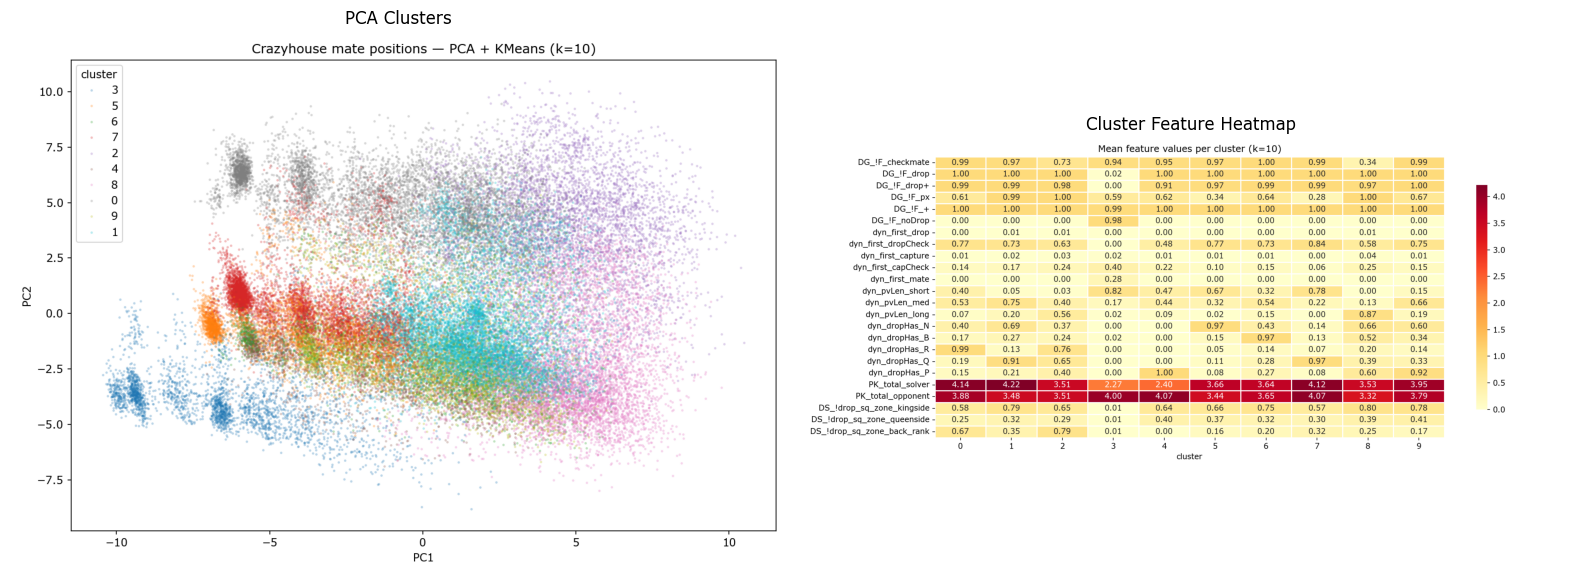

In [2]:
from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt

pca_path = OUT_PLOTS / "pca_clusters.png"
heatmap_path = OUT_PLOTS / "cluster_heatmap.png"

exists_pca = pca_path.exists()
exists_heat = heatmap_path.exists()

if not exists_pca and not exists_heat:
    raise FileNotFoundError(f"Neither {pca_path} nor {heatmap_path} found.")

# display whichever images exist; side-by-side if both present
if exists_pca and exists_heat:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(Image.open(pca_path))
    axes[0].axis("off")
    axes[0].set_title("PCA Clusters")
    axes[1].imshow(Image.open(heatmap_path))
    axes[1].axis("off")
    axes[1].set_title("Cluster Feature Heatmap")
    plt.tight_layout()
    plt.show()
else:
    path = pca_path if exists_pca else heatmap_path
    plt.figure(figsize=(10, 6))
    plt.imshow(Image.open(path))
    plt.axis("off")
    plt.title(path.name)
    plt.tight_layout()
    plt.show()

### 15. `generate_static_labels.py`
Auto-generates similarity labels using static features + BM25 candidates. Writes `dataset_static_labels.jsonl`.

> Requires: corpus JSONL + **Lucene server running**

In [4]:
"""
generate_static_labels.py
--------------------------
Automatically generates similarity labels for Crazyhouse tactical positions
based on STATIC features only (board position, piece counts, king position,
pawn structure, pockets). No engine required.

Pipeline:
  1. Load corpus_checkmates5.jsonl
  2. For each puzzle, query Lucene BM25 for top-K candidates
  3. Compute static similarity score between query and each candidate
  4. Assign label=1 (similar) if score >= threshold, else label=0
  5. Save as dataset_static_labels.jsonl (compatible with train_similarity.py)

Usage:
    python generate_static_labels.py

Configuration (edit below):
    CORPUS_PATH  — path to corpus_checkmates5.jsonl
    LUCENE_URL   — Lucene server URL (must be running)
    OUT_PATH     — output JSONL file
    N_QUERIES    — how many puzzles to use as queries (None = all)
    TOPK         — how many BM25 candidates to retrieve per query
    THRESHOLD    — static similarity score cutoff for label=1

Feature weights summary:
    same_turn         0.20  — both sides to move match
    piece_counts      0.25  — per-piece-type count similarity
    total_material    0.10  — overall piece count difference
    att_pocket        0.10  — attacker's pocket (mating side)
    def_pocket        0.05  — defender's pocket
    king_zone         0.10  — kingside / queenside / centre
    king_rank         0.10  — rank proximity of defending king
    pawn_structure    0.05  — pawn file distribution
    castling_status   0.05  — whether defending king has castled
"""

from pathlib import Path
from collections import Counter
import json
import urllib.parse
import urllib.request
import sys
import random

try:
    import chess
except ImportError:
    print("ERROR: python-chess not installed. Run: pip install chess")
    sys.exit(1)

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
ROOT = Path(r"C:\Users\tgrum\Desktop\magistrska\crazyhouse") # Something was wrong, temporarily hardcoded file path
CORPUS_PATH  = ROOT / "data" / "derived" / "corpus_checkmates5.jsonl"
LUCENE_URL   = "http://localhost:8983"
OUT_PATH     = ROOT / "data" / "derived" / "dataset_static_labels.jsonl"

N_QUERIES    = 500    # number of puzzles to use as queries (None = all)
TOPK         = 10     # BM25 candidates per query
THRESHOLD    = 0.63   # static similarity threshold for label=1

RUN_FULL_PIPELINE = True  # set to False to only run tests

# ---------------------------------------------------------------------------
# Lucene helpers
# ---------------------------------------------------------------------------

def lucene_search(query_tokens: str, topk: int = 10,
                  exclude_id: str = "") -> list[dict]:
    params = urllib.parse.urlencode({
        "q":          query_tokens,
        "field":      "text_static",
        "topk":       topk,
        "exclude_id": exclude_id,
    })
    try:
        with urllib.request.urlopen(
            f"{LUCENE_URL}/search?{params}", timeout=15
        ) as r:
            return json.loads(r.read().decode())
    except Exception as e:
        print(f"  Lucene error: {e}")
        return []


def check_lucene() -> bool:
    try:
        with urllib.request.urlopen(
            f"{LUCENE_URL}/status", timeout=5
        ) as r:
            status = json.loads(r.read().decode())
            if status.get("status") == "ok":
                print(f"Lucene connected: {status.get('docs', '?'):,} docs")
                return True
    except Exception:
        pass
    print("ERROR: Lucene server not reachable at", LUCENE_URL)
    print("  Start it: java -Xmx2g -cp '.;../lucene/*' CrazyhouseLuceneServer")
    return False

# ---------------------------------------------------------------------------
# Board helpers
# ---------------------------------------------------------------------------

def parse_board(board_fen: str) -> chess.Board | None:
    """Parse board FEN into chess.Board. Returns None on failure."""
    for fen in [board_fen + " w - - 0 1", board_fen]:
        try:
            return chess.Board(fen=fen)
        except Exception:
            continue
    return None


def piece_counts(board_fen: str) -> Counter:
    """
    Count pieces by color+type, e.g. Counter({'wp':6,'bn':2,...}).
    Coordinate-free — only cares about how many of each piece type exist.
    """
    counts = Counter()
    board = parse_board(board_fen)
    if board is None:
        return counts
    for sq, piece in board.piece_map().items():
        color = "w" if piece.color == chess.WHITE else "b"
        counts[color + piece.symbol().lower()] += 1
    return counts


def count_similarity(a: Counter, b: Counter) -> float:
    """
    How similar are two piece-count profiles?
    1.0 = identical counts, 0.0 = completely different.
    Formula: 1 - (sum of abs differences) / (sum of maxima)
    """
    keys = set(a) | set(b)
    if not keys:
        return 1.0
    total_diff = sum(abs(a.get(k, 0) - b.get(k, 0)) for k in keys)
    total_max  = sum(max(a.get(k, 0), b.get(k, 0)) for k in keys)
    return 1.0 - total_diff / total_max if total_max > 0 else 1.0


def king_zone(board_fen: str, color: str) -> str:
    """
    Returns where the king is: 'kingside' (files f-h),
    'queenside' (files a-c), 'centre' (files d-e), or 'unknown'.
    """
    board = parse_board(board_fen)
    if board is None:
        return "unknown"
    king_sq = board.king(chess.WHITE if color == "white" else chess.BLACK)
    if king_sq is None:
        return "unknown"
    file = chess.square_file(king_sq)
    if file >= 5:
        return "kingside"
    if file <= 2:
        return "queenside"
    return "centre"


def king_rank(board_fen: str, color: str) -> int:
    """
    Returns rank of the king (1-8).
    Starting position: rank 1 (white) or 8 (black).
    Mid-game centre king: rank 4-5.
    Returns -1 on failure.
    """
    board = parse_board(board_fen)
    if board is None:
        return -1
    king_sq = board.king(chess.WHITE if color == "white" else chess.BLACK)
    if king_sq is None:
        return -1
    return chess.square_rank(king_sq) + 1   # 1-indexed


def king_castled(board_fen: str, color: str) -> bool:
    """
    Heuristic: is the king castled?
    White castled kingside: king on g1. Queenside: king on c1.
    Black castled kingside: king on g8. Queenside: king on c8.
    """
    board = parse_board(board_fen)
    if board is None:
        return False
    king_sq = board.king(chess.WHITE if color == "white" else chess.BLACK)
    if king_sq is None:
        return False
    sq_name = chess.square_name(king_sq)
    if color == "white":
        return sq_name in ("g1", "c1")
    else:
        return sq_name in ("g8", "c8")


def pawn_file_profile(board_fen: str) -> dict:
    """
    Returns {'w': Counter(file→count), 'b': Counter(file→count)}.
    Captures pawn structure as file distribution.
    """
    profile = {"w": Counter(), "b": Counter()}
    board = parse_board(board_fen)
    if board is None:
        return profile
    for sq, piece in board.piece_map().items():
        if piece.piece_type == chess.PAWN:
            color = "w" if piece.color == chess.WHITE else "b"
            profile[color][chess.square_file(sq)] += 1
    return profile


def pawn_similarity(fen_a: str, fen_b: str) -> float:
    """Average pawn-file-profile similarity across both colours."""
    pa = pawn_file_profile(fen_a)
    pb = pawn_file_profile(fen_b)
    return sum(count_similarity(pa[c], pb[c]) for c in ("w", "b")) / 2


def pawn_rank_similarity(fen_a: str, fen_b: str) -> float:
    """
    Compare pawn RANK distribution — the strongest discriminator between
    starting positions (all pawns on ranks 2/7) and mid-game positions
    (pawns advanced/exchanged across all ranks).
    """
    def rank_profile(fen: str) -> dict:
        profile = {"w": Counter(), "b": Counter()}
        board = parse_board(fen)
        if board is None:
            return profile
        for sq, piece in board.piece_map().items():
            if piece.piece_type == chess.PAWN:
                color = "w" if piece.color == chess.WHITE else "b"
                profile[color][chess.square_rank(sq)] += 1
        return profile

    pa = rank_profile(fen_a)
    pb = rank_profile(fen_b)
    return sum(count_similarity(pa[c], pb[c]) for c in ("w", "b")) / 2


def pocket_multiset(pocket: dict) -> list:
    """{'N':2,'Q':1} → ['N','N','Q']  (sorted)"""
    if not isinstance(pocket, dict):
        return []
    items = []
    for piece, cnt in pocket.items():
        items.extend([piece.upper()] * max(0, int(cnt or 0)))
    return sorted(items)


def multiset_jaccard(a: list, b: list) -> float:
    """Jaccard similarity of two multisets. 0.5 when both empty (neutral)."""
    ca, cb = Counter(a), Counter(b)
    keys = set(ca) | set(cb)
    if not keys:
        return 0.5   # both empty → neutral
    inter = sum(min(ca[k], cb[k]) for k in keys)
    union = sum(max(ca[k], cb[k]) for k in keys)
    return inter / union if union > 0 else 0.0


def parse_pocket_field(val) -> dict:
    """Parse pocket field that may be a dict, JSON string, or None."""
    if isinstance(val, dict):
        return val
    if isinstance(val, str):
        try:
            return json.loads(val)
        except Exception:
            return {}
    return {}

# ---------------------------------------------------------------------------
# Static similarity — main function
# ---------------------------------------------------------------------------

def static_similarity(query: dict, candidate: dict) -> float:
    """
    Compute static similarity score in [0.0, 1.0].

    Feature               Weight  Description
    ─────────────────────────────────────────────────────────────────────
    same_turn             0.08   1.0 same, 0.7 different (soft penalty)
    piece_counts          0.30   Per-type piece count similarity
    total_material        0.08   Overall piece count closeness
    attacker_pocket       0.09   Pocket of the mating side (Jaccard)
    defender_pocket       0.05   Pocket of the defending side (Jaccard)
    king_zone             0.10   Defending king: kingside/queenside/centre
    king_rank             0.08   Defending king rank proximity
    castling_status       0.05   Both defending kings castled or both not
    pawn_file_structure   0.07   Pawn file distribution similarity
    pawn_rank_structure   0.10   Pawn rank distribution — key discriminator
                                 (starting pos: all on ranks 2/7 vs mid-game)

    Suggested threshold for label=1: score >= 0.63
    """
    q_fen  = query.get("board_fen") or query.get("query_fen") or ""
    c_fen  = candidate.get("board_fen") or candidate.get("candidate_fen") or ""

    def norm_turn(t):
        t = (t or "white").strip().lower()
        return "black" if t.startswith("b") else "white"

    q_turn = norm_turn(query.get("turn") or query.get("query_turn"))
    c_turn = norm_turn(candidate.get("turn") or candidate.get("candidate_turn"))

    score        = 0.0
    total_weight = 0.0

    def add(s: float, w: float):
        nonlocal score, total_weight
        score        += s * w
        total_weight += w

    # ── 1. Same side to move (weight 0.08) ───────────────────────────────
    # Soft penalty: different turn = 0.7 (not 0.0) because the board
    # structure is still similar even if who moves differs.
    add(1.0 if q_turn == c_turn else 0.7, 0.08)

    # ── 2. Piece count similarity per type (weight 0.30) ─────────────────
    q_cnt = piece_counts(q_fen)
    c_cnt = piece_counts(c_fen)
    add(count_similarity(q_cnt, c_cnt), 0.30)

    # ── 3. Total material (weight 0.08) ──────────────────────────────────
    diff = abs(sum(q_cnt.values()) - sum(c_cnt.values()))
    add(max(0.0, 1.0 - diff / 8.0), 0.08)

    # ── 4 & 5. Pockets (weight 0.09 + 0.05) ─────────────────────────────
    q_pw = parse_pocket_field(query.get("pockets_white") or {})
    q_pb = parse_pocket_field(query.get("pockets_black") or {})
    c_pw = parse_pocket_field(candidate.get("pockets_white") or {})
    c_pb = parse_pocket_field(candidate.get("pockets_black") or {})

    q_att = pocket_multiset(q_pb if q_turn == "black" else q_pw)
    c_att = pocket_multiset(c_pb if c_turn == "black" else c_pw)
    add(multiset_jaccard(q_att, c_att), 0.09)

    q_def_pkt = pocket_multiset(q_pw if q_turn == "black" else q_pb)
    c_def_pkt = pocket_multiset(c_pw if c_turn == "black" else c_pb)
    add(multiset_jaccard(q_def_pkt, c_def_pkt), 0.05)

    # ── 6, 7, 8. Defending king position (weight 0.10 + 0.08 + 0.05) ────
    q_def_color = "white" if q_turn == "black" else "black"
    c_def_color = "white" if c_turn == "black" else "black"

    q_kzone = king_zone(q_fen, q_def_color)
    c_kzone = king_zone(c_fen, c_def_color)
    add(1.0 if q_kzone == c_kzone and q_kzone != "unknown"
        else 0.5 if q_kzone == "unknown" else 0.0, 0.10)

    q_krank = king_rank(q_fen, q_def_color)
    c_krank = king_rank(c_fen, c_def_color)
    add(max(0.0, 1.0 - abs(q_krank - c_krank) / 4.0)
        if q_krank > 0 and c_krank > 0 else 0.5, 0.08)

    add(1.0 if king_castled(q_fen, q_def_color) == king_castled(c_fen, c_def_color)
        else 0.0, 0.05)

    # ── 9. Pawn file distribution (weight 0.07) ───────────────────────────
    add(pawn_similarity(q_fen, c_fen), 0.07)

    # ── 10. Pawn rank distribution (weight 0.10) ──────────────────────────
    # Starting position: all pawns on ranks 2/7.
    # Mid-game: pawns advanced/exchanged. Strong discriminator.
    add(pawn_rank_similarity(q_fen, c_fen), 0.10)

    return score / total_weight if total_weight > 0 else 0.0

# ---------------------------------------------------------------------------
# Self-test
# ---------------------------------------------------------------------------

def run_tests():
    """Sanity-check the similarity function with known cases."""
    print("Running self-tests...\n")

    ref = {
        "board_fen":     "r3kbnr/1pp2ppp/p1p2q2/4p3/4P3/2NP1B2/PPP2PRp/R1BQK3",
        "turn":          "black",
        "pockets_white": {"P": 1, "N": 1, "B": 1},
        "pockets_black": {},
    }

    tests = [
        ("1. Identical positions",      ref, ref,                                                                               1, "~0.95"),
        ("2. Same board, diff turn",    ref, {**ref, "turn": "white"},                                                          1, "~0.75"),
        ("3. Starting vs mid-game",     ref, {"board_fen":"rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR",
                                              "turn":"white","pockets_white":{},"pockets_black":{}},                            0, "~0.50"),
        ("4. Very similar mid-game",    ref, {"board_fen":"r3kbnr/1pp2ppp/p1p2q2/4p3/4P3/2NP1B2/PPP2P1p/R1BQK2R",
                                              "turn":"black","pockets_white":{"P":1,"N":1},"pockets_black":{}},                 1, "~0.93"),
        ("5. Same turn, diff material", ref, {"board_fen":"6k1/5ppp/8/8/8/8/5PPP/6K1",
                                              "turn":"black","pockets_white":{},"pockets_black":{}},                            0, "~0.35"),
    ]

    all_ok = True
    print(f"{'Test':<32} {'Score':>6}  {'Label':>6}  {'Expected':>8}  OK?")
    print("─" * 68)
    for name, q, c, expected_lbl, expected_score in tests:
        s   = static_similarity(q, c)
        lbl = 1 if s >= THRESHOLD else 0
        ok  = "✓" if lbl == expected_lbl else "✗"
        if lbl != expected_lbl:
            all_ok = False
        print(f"{name:<32} {s:>6.3f}  {lbl:>6}  {expected_score:>8}  {ok}")

    print(f"\nThreshold: {THRESHOLD}")
    print(f"All tests passed: {all_ok}")
    print("─" * 68)

# ---------------------------------------------------------------------------
# Main pipeline
# ---------------------------------------------------------------------------

def main():
    print("=" * 60)
    print("generate_static_labels.py — Static Similarity Labeler")
    print("=" * 60)

    if not check_lucene():
        print("Aborting: Lucene not available.")
        return

    if not CORPUS_PATH.exists():
        print(f"ERROR: Corpus not found at {CORPUS_PATH}")
        return

    # Load corpus
    print(f"\nLoading corpus from {CORPUS_PATH} ...")
    corpus = []
    with open(CORPUS_PATH, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                corpus.append(json.loads(line))
            except Exception:
                continue
    print(f"Loaded {len(corpus):,} puzzles")

    # Sample queries
    if N_QUERIES is not None and N_QUERIES < len(corpus):
        random.seed(42)
        queries = random.sample(corpus, N_QUERIES)
        print(f"Sampled {N_QUERIES} queries (seed=42 for reproducibility)")
    else:
        queries = corpus
        print(f"Using all {len(queries)} puzzles as queries")

    # Process
    OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    total_pairs = 0
    total_pos   = 0
    total_neg   = 0
    n_done      = 0

    print(f"\nSettings: TOPK={TOPK}, THRESHOLD={THRESHOLD}")
    print(f"Output: {OUT_PATH}\n")

    with open(OUT_PATH, "w", encoding="utf-8") as out_f:
        for query in queries:
            query_id  = query.get("id", "")
            board_fen = query.get("board_fen", "")

            if not board_fen:
                n_done += 1
                continue

            # Use text_static tokens for BM25 retrieval
            query_tokens = query.get("text_static", "")
            if not query_tokens:
                n_done += 1
                continue

            hits = lucene_search(query_tokens, topk=TOPK, exclude_id=query_id)

            for rank, hit in enumerate(hits, start=1):
                hit_id = hit.get("id", "")
                if not hit_id or hit_id == query_id:
                    continue

                hit_rec = {
                    "board_fen":     hit.get("board_fen", ""),
                    "turn":          hit.get("turn", "white"),
                    "pockets_white": parse_pocket_field(hit.get("pockets_white") or {}),
                    "pockets_black": parse_pocket_field(hit.get("pockets_black") or {}),
                }

                sim_score = static_similarity(query, hit_rec)
                label     = 1 if sim_score >= THRESHOLD else 0

                record = {
                    # Required by train_similarity.py
                    "query_id":               query_id,
                    "candidate_id":           hit_id,
                    "label":                  label,
                    "bm25_rank":              rank,
                    "query_fen":              board_fen,
                    "candidate_fen":          hit_rec["board_fen"],
                    "query_mate":             query.get("mate_in") or query.get("mate_before"),
                    "candidate_mate":         hit.get("mate_in") or hit.get("mate_before"),
                    "query_turn":             query.get("turn", "white"),
                    "candidate_turn":         hit.get("turn", "white"),
                    "query_text_static":      query.get("text_static", ""),
                    "candidate_text_static":  hit.get("text_static", ""),
                    "query_text_dynamic":     query.get("text_dynamic", ""),
                    "candidate_text_dynamic": hit.get("text_dynamic", ""),
                    "query_solution_san":     query.get("solution_san", []),
                    "candidate_solution_san": hit.get("solution_san", []),
                    "query_solution_uci":     query.get("solution_uci", []),
                    "candidate_solution_uci": hit.get("solution_uci", []),
                    "query_rating_avg":       query.get("game_rating_avg"),
                    "candidate_rating_avg":   hit.get("game_rating_avg"),
                    # Extra analysis column
                    "static_sim_score":       round(sim_score, 4),
                }

                out_f.write(json.dumps(record, ensure_ascii=False) + "\n")
                total_pairs += 1
                if label == 1:
                    total_pos += 1
                else:
                    total_neg += 1

            n_done += 1
            if n_done % 50 == 0 or n_done == len(queries):
                pct = 100 * total_pos / max(total_pairs, 1)
                print(f"  {n_done:>4}/{len(queries)} queries | "
                      f"{total_pairs:,} pairs | "
                      f"pos={total_pos:,} ({pct:.0f}%) "
                      f"neg={total_neg:,}")

    print()
    print("=" * 60)
    print("DONE")
    print(f"  Queries processed : {n_done:,}")
    print(f"  Total pairs       : {total_pairs:,}")
    print(f"  Label=1 (similar) : {total_pos:,}  "
          f"({100*total_pos/max(total_pairs,1):.1f}%)")
    print(f"  Label=0 (differ.) : {total_neg:,}  "
          f"({100*total_neg/max(total_pairs,1):.1f}%)")
    print(f"  Output            : {OUT_PATH}")
    print()
    print("Next step:")
    print(f"  python train_similarity.py "
          f"--data {OUT_PATH.name} --out output/")


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    run_tests()
    if RUN_FULL_PIPELINE:
        print()
        main()

Running self-tests...

Test                              Score   Label  Expected  OK?
────────────────────────────────────────────────────────────────────
1. Identical positions            0.955       1     ~0.95  ✓
2. Same board, diff turn          0.756       1     ~0.75  ✓
3. Starting vs mid-game           0.628       0     ~0.50  ✓
4. Very similar mid-game          0.938       1     ~0.93  ✓
5. Same turn, diff material       0.348       0     ~0.35  ✓

Threshold: 0.63
All tests passed: True
────────────────────────────────────────────────────────────────────

generate_static_labels.py — Static Similarity Labeler
Lucene connected: 556,807 docs

Loading corpus from C:\Users\tgrum\Desktop\magistrska\crazyhouse\data\derived\corpus_checkmates5.jsonl ...
Loaded 556,807 puzzles
Sampled 500 queries (seed=42 for reproducibility)

Settings: TOPK=10, THRESHOLD=0.63
Output: C:\Users\tgrum\Desktop\magistrska\crazyhouse\data\derived\dataset_static_labels.jsonl

    50/500 queries | 500 pairs | p

---
## Phase 6 — Training

Train similarity classifiers using weak labels, then refine with human-labelled data.


### 16. `train_classifier_weak.py`
Trains a similarity classifier using cluster-based weak labels (same cluster = similar). Writes `similarity_classifier.pkl`.

> Requires: outputs of steps 9 and 14

In [8]:
"""
train_classifier_weak.py
------------------------
Trains a similarity classifier using cluster-based weak labels.
Weak label definition:
  - Same cluster  → label 1 (similar)
  - Diff cluster  → label 0 (different)
The silhouette score was 0.058, so these labels are noisy.
That's fine — the classifier is a "rough first pass" to be refined
later with human-annotated labels from the web app.
Pipeline:
  1. Load puzzle_features_mates.parquet       (feature matrix, 178 features)
  2. Load puzzle_features_mates_clustered.parquet  (puzzle_id → cluster)
  3. Sample pairs: N_SAME same-cluster pairs + N_DIFF different-cluster pairs
  4. Build pair feature vector = |q_feat - c_feat|  (absolute difference)
     Also append q_feat and c_feat as raw features (mentor's approach)
  5. Train RandomForest + LogisticRegression
  6. Cross-validate, print AUC
  7. Save model to models/similarity_classifier.pkl
The saved model can be used by app.py to re-rank BM25 results.
Usage:
    python train_classifier_weak.py
    python train_classifier_weak.py --n_pairs 50000 --n_clusters_skip 4
"""
from pathlib import Path
import argparse
import random
import pickle
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Paths — hardcoded for Jupyter compatibility
# ---------------------------------------------------------------------------
ROOT       = Path(r"C:\Users\tgrum\Desktop\magistrska\crazyhouse")
FEAT_PATH  = ROOT / "data" / "derived" / "puzzle_features_mates.parquet"
CLUS_PATH  = ROOT / "data" / "derived" / "puzzle_features_mates_clustered.parquet"
MODEL_DIR  = ROOT / "data" / "models"
MODEL_PATH = MODEL_DIR / "similarity_classifier.pkl"

# Metadata columns — not used as features
META_COLS = [
    "puzzle_id", "site", "ply", "board_fen", "turn",
    "pockets_white_raw", "pockets_black_raw",
]

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
N_SAME          = 30_000   # same-cluster pairs to sample
N_DIFF          = 30_000   # different-cluster pairs to sample
RANDOM_STATE    = 42
CV_FOLDS        = 5

# Jupyter-friendly run options (replaces argparse)
MODEL_TYPE      = "xgb"    # "rf", "lr", "gb", "xgb", "lgb"
N_PAIRS         = None     # set to int to override N_SAME and N_DIFF
N_CLUSTERS_SKIP = None     # set to int cluster id to skip from positive pairs
RUN_CV          = True     # set to False to skip cross-validation


def get_feat_cols(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns
            if c not in META_COLS
            and pd.api.types.is_numeric_dtype(df[c])]


def sample_pairs(df: pd.DataFrame, cluster_col: str,
                 n_same: int, n_diff: int,
                 skip_clusters: set | None = None,
                 rng: random.Random = None) -> list[tuple]:
    """
    Sample (idx_a, idx_b, label) pairs.
    skip_clusters: cluster ids to exclude from positive pairs
                   (e.g. the large no-drop cluster which is too different
                    from everything else to be a useful positive signal)
    """
    if rng is None:
        rng = random.Random(RANDOM_STATE)

    cluster_to_idxs: dict[int, list[int]] = {}
    for i, c in enumerate(df[cluster_col]):
        cluster_to_idxs.setdefault(c, []).append(i)

    all_clusters = list(cluster_to_idxs.keys())
    pos_clusters = [c for c in all_clusters
                    if (skip_clusters is None or c not in skip_clusters)
                    and len(cluster_to_idxs[c]) >= 2]

    pairs = []

    # Positive pairs (same cluster)
    attempts = 0
    while len(pairs) < n_same and attempts < n_same * 10:
        attempts += 1
        c = rng.choice(pos_clusters)
        idxs = cluster_to_idxs[c]
        a, b = rng.sample(idxs, 2)
        pairs.append((a, b, 1))

    # Negative pairs (different clusters)
    attempts = 0
    while len(pairs) < n_same + n_diff and attempts < n_diff * 10:
        attempts += 1
        c1, c2 = rng.sample(all_clusters, 2)
        a = rng.choice(cluster_to_idxs[c1])
        b = rng.choice(cluster_to_idxs[c2])
        pairs.append((a, b, 0))

    rng.shuffle(pairs)
    return pairs


def build_pair_features(feat_matrix: np.ndarray,
                        pairs: list[tuple]) -> tuple[np.ndarray, np.ndarray]:
    """
    For each (a, b, label) pair, build feature vector:
      [|feat_a - feat_b|, feat_a, feat_b]
    The difference features mirror the mentor's approach (Tier-1/2/3
    features are all difference-based). Raw features are included too
    because the mentor found some raw query/candidate features also matter.
    """
    X_list = []
    y_list = []

    for a, b, label in pairs:
        fa = feat_matrix[a]
        fb = feat_matrix[b]
        diff = np.abs(fa - fb)
        vec = np.concatenate([diff, fa, fb])
        X_list.append(vec)
        y_list.append(label)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int8)


def main(model_type=MODEL_TYPE, n_pairs=N_PAIRS,
         n_clusters_skip=N_CLUSTERS_SKIP, run_cv=RUN_CV):

    n_same = n_pairs or N_SAME
    n_diff = n_pairs or N_DIFF
    skip   = {n_clusters_skip} if n_clusters_skip is not None else None

    MODEL_DIR.mkdir(parents=True, exist_ok=True)

    # ── 1) Load features ────────────────────────────────────────────────
    print(f"Loading features: {FEAT_PATH}")
    feat_df = pd.read_parquet(FEAT_PATH)
    print(f"  Shape: {feat_df.shape}")

    feat_cols = get_feat_cols(feat_df)
    print(f"  Feature columns: {len(feat_cols)}")

    # ── 2) Load cluster assignments ──────────────────────────────────────
    print(f"Loading clusters: {CLUS_PATH}")
    clus_df = pd.read_parquet(CLUS_PATH)[["puzzle_id", "cluster", "cluster_name"]]
    print(f"  Cluster distribution:\n{clus_df['cluster'].value_counts().sort_index().to_string()}")

    # ── 3) Merge ─────────────────────────────────────────────────────────
    df = feat_df.merge(clus_df, on="puzzle_id", how="inner")
    print(f"  After merge: {len(df):,} rows")

    feat_matrix = df[feat_cols].values.astype(np.float32)

    # ── 4) Sample pairs ──────────────────────────────────────────────────
    print(f"\nSampling pairs: {n_same:,} same-cluster + {n_diff:,} diff-cluster ...")
    if skip:
        print(f"  Skipping cluster(s) {skip} from positive pairs")

    rng = random.Random(RANDOM_STATE)
    pairs = sample_pairs(df, "cluster", n_same, n_diff,
                         skip_clusters=skip, rng=rng)

    print(f"  Total pairs: {len(pairs):,}")
    labels = [p[2] for p in pairs]
    print(f"  Label dist: {labels.count(1):,} similar, {labels.count(0):,} different")

    # ── 5) Build pair feature matrix ────────────────────────────────────
    print("\nBuilding pair feature vectors ...")
    X, y = build_pair_features(feat_matrix, pairs)
    print(f"  X shape: {X.shape}  (pairs × features)")
    print(f"  y shape: {y.shape}")

    # ── 6) Train model ───────────────────────────────────────────────────
    print(f"\nTraining model: {model_type} ...")

    if model_type == "rf":
        model = Pipeline([
            ("clf", RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=10,
                n_jobs=-1,
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ))
        ])
    elif model_type == "lr":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                C=1.0,
                max_iter=1000,
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1,
            ))
        ])
    elif model_type == "gb":
        model = Pipeline([
            ("clf", GradientBoostingClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.1,
                random_state=RANDOM_STATE,
            ))
        ])
    elif model_type == "xgb":
        model = Pipeline([
            ("clf", xgb.XGBClassifier(
                n_estimators=500,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                device="cuda",
                eval_metric="auc",
                use_label_encoder=False,
                random_state=RANDOM_STATE,
                scale_pos_weight=1,
                tree_method="hist",
            ))
        ])
    elif model_type == "lgb":
        model = Pipeline([
            ("clf", lgb.LGBMClassifier(
                n_estimators=500,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                device="gpu",
                random_state=RANDOM_STATE,
                class_weight="balanced",
                verbose=-1,
            ))
        ])
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    # ── 7) Cross-validation ──────────────────────────────────────────────
    if run_cv:
        print(f"\nCross-validating ({CV_FOLDS}-fold stratified) ...")
        cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
        print(f"  AUC scores: {auc_scores.round(3)}")
        print(f"  Mean AUC:   {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
    else:
        print("  (skipping CV)")

    # ── 8) Fit on full training set ──────────────────────────────────────
    print("\nFitting on full training set ...")
    model.fit(X, y)

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    train_auc = roc_auc_score(y, y_prob)
    print(f"  Train AUC: {train_auc:.3f}")
    print(classification_report(y, y_pred, target_names=["different", "similar"]))

    # ── 9) Feature importance ────────────────────────────────────────────
    if model_type in ("rf", "xgb", "lgb"):
        clf = model.named_steps["clf"]
        importances = clf.feature_importances_
        if hasattr(clf, "best_iteration"):
            print(f"  Best iteration: {clf.best_iteration}")

        diff_names = [f"d_{c}" for c in feat_cols]
        q_names    = [f"q_{c}" for c in feat_cols]
        c_names    = [f"c_{c}" for c in feat_cols]
        all_names  = diff_names + q_names + c_names

        top_idx = np.argsort(importances)[::-1][:20]
        print("\nTop 20 feature importances:")
        for i in top_idx:
            print(f"  {all_names[i]:<45} {importances[i]:.4f}")

    # ── 10) Save model ───────────────────────────────────────────────────
    payload = {
        "model":      model,
        "feat_cols":  feat_cols,
        "model_type": model_type,
        "n_pairs":    len(pairs),
        "label_type": "cluster_weak",
        "gpu":        model_type in ("xgb", "lgb"),
        "n_clusters": int(df["cluster"].nunique()),
    }
    with open(MODEL_PATH, "wb") as f:
        pickle.dump(payload, f)

    print(f"\nModel saved: {MODEL_PATH}")
    print("\nDone.")
    print("Next step: use this model to re-rank BM25 results in app.py,")
    print("or collect human labels and retrain with train_classifier_supervised.py")


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    import sys
    # Jupyter passes kernel JSON path as argument — detect and skip argparse
    if any("ipykernel" in a or "jupyter" in a.lower() for a in sys.argv):
        main()
    else:
        # Normal script invocation — use argparse
        ap = argparse.ArgumentParser()
        ap.add_argument("--n_pairs", type=int, default=None)
        ap.add_argument("--n_clusters_skip", type=int, default=None)
        ap.add_argument("--model", default="xgb",
                        choices=["rf", "lr", "gb", "xgb", "lgb"])
        ap.add_argument("--no_cv", action="store_true")
        args = ap.parse_args()

        main(
            model_type=args.model,
            n_pairs=args.n_pairs,
            n_clusters_skip=args.n_clusters_skip,
            run_cv=not args.no_cv,
        )

Loading features: C:\Users\tgrum\Desktop\magistrska\crazyhouse\data\derived\puzzle_features_mates.parquet
  Shape: (5048807, 254)
  Feature columns: 247
Loading clusters: C:\Users\tgrum\Desktop\magistrska\crazyhouse\data\derived\puzzle_features_mates_clustered.parquet
  Cluster distribution:
cluster
0    712533
1    936558
2    484993
3    303530
4    219469
5    422122
6    274720
7    596195
8    650643
9    448044
  After merge: 5,048,807 rows

Sampling pairs: 30,000 same-cluster + 30,000 diff-cluster ...
  Total pairs: 60,000
  Label dist: 30,000 similar, 30,000 different

Building pair feature vectors ...
  X shape: (60000, 741)  (pairs × features)
  y shape: (60000,)

Training model: xgb ...

Cross-validating (5-fold stratified) ...
  AUC scores: [0.986 0.984 0.986 0.987 0.986]
  Mean AUC:   0.986 ± 0.001

Fitting on full training set ...
  Train AUC: 0.998
              precision    recall  f1-score   support

   different       0.99      0.96      0.97     30000
     similar   

### 17. `patch_dataset.py`
Patches `dataset_full.jsonl` by filling missing text fields from the corpus. Writes `dataset_full_patched.jsonl`.

> Run this before step 18 if your dataset has gaps.

In [11]:
"""
patch_dataset.py
----------------
Patches dataset_full.jsonl by filling in missing/empty text fields
(query_text_static, query_text_dynamic, candidate_text_static, candidate_text_dynamic)
using the corpus_mates.jsonl as the source of truth.

Also fixes the spaced-out text_static bug (e.g. "b r @ h 8" -> "br@h8")
by always overwriting from corpus regardless of existing value.

Usage:
    python patch_dataset.py
    python patch_dataset.py --data dataset_full.jsonl --corpus ../data/derived/corpus_mates.jsonl --out dataset_full_patched.jsonl
"""

import json
import argparse
import sys
from pathlib import Path

# ---------------------------------------------------------------------------
# Config — edit these when running in Jupyter
# ---------------------------------------------------------------------------
ROOT         = Path(r"C:\Users\tgrum\Desktop\magistrska\crazyhouse")
DATA_PATH    = ROOT / "src" / "dataset_full.jsonl"
CORPUS_PATH  = ROOT / "data" / "derived" / "corpus_mates.jsonl"
OUT_PATH     = ROOT / "src" / "dataset_full_patched.jsonl"


def fix_spaced(s: str) -> str:
    """Fix spaced-out tokens like 'b r @ h 8' -> 'br@h8'."""
    if s and ' ' in s:
        tokens = s.split(' ')
        avg_len = sum(len(t) for t in tokens) / max(len(tokens), 1)
        if avg_len <= 1.5:
            return s.replace(' ', '')
    return s


def main(data_path=DATA_PATH, corpus_path=CORPUS_PATH, out_path=OUT_PATH):

    data_path   = Path(data_path)
    corpus_path = Path(corpus_path)
    out_path    = Path(out_path)

    # ── 1. Load corpus into memory ────────────────────────────────────────────
    print(f"Loading corpus from {corpus_path} ...")
    corpus = {}
    with open(corpus_path, encoding="utf-8") as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
            doc = json.loads(line)
            corpus[doc["id"]] = doc
            if (i + 1) % 500_000 == 0:
                print(f"  {i+1:,} docs loaded...")
    print(f"Corpus loaded: {len(corpus):,} docs\n")

    # ── 2. Patch dataset ──────────────────────────────────────────────────────
    n_total = 0
    n_patched_query = 0
    n_patched_candidate = 0
    n_missing_query = 0
    n_missing_candidate = 0

    with open(data_path, encoding="utf-8") as fin, \
         open(out_path,  "w", encoding="utf-8") as fout:

        for line in fin:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)
            n_total += 1

            # Patch query fields
            qid  = row.get("query_id", "")
            qdoc = corpus.get(qid)
            if qdoc:
                row["query_text_static"]  = qdoc.get("text_static",  "")
                row["query_text_dynamic"] = qdoc.get("text_dynamic", "")
                n_patched_query += 1
            else:
                row["query_text_static"]  = fix_spaced(row.get("query_text_static", ""))
                row["query_text_dynamic"] = fix_spaced(row.get("query_text_dynamic", ""))
                n_missing_query += 1

            # Patch candidate fields
            cid  = row.get("candidate_id", "")
            cdoc = corpus.get(cid)
            if cdoc:
                row["candidate_text_static"]  = cdoc.get("text_static",  "")
                row["candidate_text_dynamic"] = cdoc.get("text_dynamic", "")
                n_patched_candidate += 1
            else:
                row["candidate_text_static"]  = fix_spaced(row.get("candidate_text_static", ""))
                row["candidate_text_dynamic"] = fix_spaced(row.get("candidate_text_dynamic", ""))
                n_missing_candidate += 1

            fout.write(json.dumps(row, ensure_ascii=False) + "\n")

    print(f"Done. {n_total:,} rows processed -> {out_path}")
    print(f"  Query   patched: {n_patched_query:,}  |  not in corpus: {n_missing_query:,}")
    print(f"  Candid. patched: {n_patched_candidate:,}  |  not in corpus: {n_missing_candidate:,}")

    if n_missing_query > 0:
        print(f"\n  NOTE: {n_missing_query:,} rows had search_by_fen query IDs.")
        print("  These rows will only have static features (no dynamic) during training.")
        print("  Consider re-exporting those queries from real indexed positions.")


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # Jupyter passes kernel JSON as argument — detect and skip argparse
    if any("ipykernel" in a or "jupyter" in a.lower() for a in sys.argv):
        main()
    else:
        ap = argparse.ArgumentParser()
        ap.add_argument("--data",   default=str(DATA_PATH))
        ap.add_argument("--corpus", default=str(CORPUS_PATH))
        ap.add_argument("--out",    default=str(OUT_PATH))
        args = ap.parse_args()
        main(data_path=args.data, corpus_path=args.corpus, out_path=args.out)

Loading corpus from C:\Users\tgrum\Desktop\magistrska\crazyhouse\data\derived\corpus_mates.jsonl ...


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\tgrum\\Desktop\\magistrska\\crazyhouse\\data\\derived\\corpus_mates.jsonl'

### 18. `train_similarity_v2.py`
Trains the main similarity model from human-labelled or patched data. Writes models + plots to `output_v2/`.

> Requires: `dataset_full.jsonl` (or patched version from step 17)

In [13]:
"""
train_similarity_v2.py
=======================
Improvements over v1:
  - Richer pawn structure features (passed, doubled, isolated, advancement)
  - King safety features (rank, zone, proximity to center)
  - Grid search for both Decision Tree and XGBoost
  - Cross-validated evaluation

Usage:
    python train_similarity_v2.py --data dataset_full.jsonl --out output/
"""

import json
import re
import sys
import warnings
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Config — edit these when running in Jupyter
# ---------------------------------------------------------------------------
ROOT      = Path(r"C:\Users\tgrum\Desktop\magistrska\crazyhouse")
DATA_PATH = ROOT / "src" / "dataset_full.jsonl"
OUT_PATH  = ROOT / "src" / "output_v2"

# ---------------------------------------------------------------------------
# Setup
# ---------------------------------------------------------------------------
OUT = Path(OUT_PATH)
OUT.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────────────────────
print(f"[1/7] Loading {DATA_PATH} ...")
rows = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                rows.append(json.loads(line))
            except:
                pass
print(f"       {len(rows):,} rows loaded")

# ─────────────────────────────────────────────────────────────────────────────
# FEATURE EXTRACTION
# ─────────────────────────────────────────────────────────────────────────────
PIECES = ["K", "Q", "R", "B", "N", "P"]

def parse_static_tokens(text: str) -> dict:
    f = defaultdict(float)

    # Normalise spaced format → compact
    text = re.sub(r'\s+', ' ', text.strip())
    text = re.sub(
        r'([wb])\s+([KQRBNPkqrbnp])\s+@\s+([a-h])\s+([1-8])',
        lambda m: f"{m.group(1)}{m.group(2)}@{m.group(3)}{m.group(4)}",
        text
    )

    # Collect pawn positions for pawn structure analysis
    w_pawns = []   # list of (file_int 1-8, rank_int 1-8)
    b_pawns = []

    for tok in text.split():
        # Piece placement
        m = re.match(r'^([wb])([KQRBNPkqrbnp])@([a-h])([1-8])$', tok, re.IGNORECASE)
        if m:
            color = m.group(1).lower()
            piece = m.group(2).upper()
            file_c = m.group(3).lower()
            rank_c = m.group(4)
            side = "w" if color == "w" else "b"
            file_i = ord(file_c) - ord('a') + 1  # 1=a .. 8=h
            rank_i = int(rank_c)                  # 1=rank1 .. 8=rank8

            f[f"{side}_{piece}_count"] += 1

            if piece == "K":
                f[f"{side}_king_file"]     = file_i
                f[f"{side}_king_rank"]     = rank_i
                f[f"{side}_king_kingside"] = 1.0 if file_i >= 5 else 0.0
                # King centralisation score (distance from centre d1/e1 area)
                f[f"{side}_king_center_dist"] = abs(file_i - 4.5) + abs(rank_i - 4.5)

            if piece == "P":
                if side == "w":
                    w_pawns.append((file_i, rank_i))
                else:
                    b_pawns.append((file_i, rank_i))
            continue

        # Pocket tokens
        m2 = re.match(r'^([wb])pocket:([QRBNP])$', tok, re.IGNORECASE)
        if m2:
            side  = "w" if m2.group(1).lower() == "w" else "b"
            piece = m2.group(2).upper()
            f[f"{side}_pocket_{piece}"] += 1

    # ── Pawn structure features ───────────────────────────────────────────────

    for side, pawns, forward in [("w", w_pawns, 1), ("b", b_pawns, -1)]:
        opp_pawns = b_pawns if side == "w" else w_pawns

        files = [p[0] for p in pawns]
        ranks = [p[1] for p in pawns]
        opp_files = [p[0] for p in opp_pawns]
        opp_ranks = [p[1] for p in opp_pawns]

        n = len(pawns)
        f[f"{side}_pawn_count"] = float(n)

        if n == 0:
            f[f"{side}_doubled_pawns"]    = 0.0
            f[f"{side}_isolated_pawns"]   = 0.0
            f[f"{side}_passed_pawns"]     = 0.0
            f[f"{side}_pawn_advancement"] = 0.0
            f[f"{side}_pawn_spread"]      = 0.0
            f[f"{side}_pawn_center"]      = 0.0
        else:
            # Doubled: more than one pawn on same file
            file_counts = Counter(files)
            doubled = sum(c - 1 for c in file_counts.values() if c > 1)
            f[f"{side}_doubled_pawns"] = float(doubled)

            # Isolated: no friendly pawn on adjacent files
            isolated = 0
            for pf in files:
                if (pf - 1) not in file_counts and (pf + 1) not in file_counts:
                    isolated += 1
            f[f"{side}_isolated_pawns"] = float(isolated)

            # Passed: no enemy pawn on same or adjacent file ahead of this pawn
            passed = 0
            for pf, pr in pawns:
                blocked = False
                for of, or_ in opp_pawns:
                    if abs(of - pf) <= 1:
                        if side == "w" and or_ > pr:
                            blocked = True; break
                        if side == "b" and or_ < pr:
                            blocked = True; break
                if not blocked:
                    passed += 1
            f[f"{side}_passed_pawns"] = float(passed)

            # Pawn advancement
            if side == "w":
                f[f"{side}_pawn_advancement"] = float(sum(ranks)) / n
            else:
                f[f"{side}_pawn_advancement"] = float(sum(9 - r for r in ranks)) / n

            # Pawn spread (file range)
            f[f"{side}_pawn_spread"] = float(max(files) - min(files)) if files else 0.0

            # Pawn center control (pawns on d,e files = files 4,5)
            center_pawns = sum(1 for pf in files if pf in (4, 5))
            f[f"{side}_pawn_center"] = float(center_pawns)

    # Pawn tension: pawns that can capture each other
    tension = 0
    for wf, wr in w_pawns:
        for bf, br in b_pawns:
            if abs(wf - bf) == 1 and wr + 1 == br:
                tension += 1
    f["pawn_tension"] = float(tension)

    # ── Derived aggregate features ────────────────────────────────────────────
    for side in ["w", "b"]:
        f[f"{side}_total_pieces"]    = sum(f[f"{side}_{p}_count"] for p in PIECES)
        f[f"{side}_pocket_total"]    = sum(f[f"{side}_pocket_{p}"] for p in PIECES)
        f[f"{side}_material"]        = (
            9*f[f"{side}_Q_count"] + 5*f[f"{side}_R_count"] +
            3*f[f"{side}_B_count"] + 3*f[f"{side}_N_count"] + f[f"{side}_P_count"]
        )
        f[f"{side}_pocket_material"] = (
            9*f[f"{side}_pocket_Q"] + 5*f[f"{side}_pocket_R"] +
            3*f[f"{side}_pocket_B"] + 3*f[f"{side}_pocket_N"] + f[f"{side}_pocket_P"]
        )

    f["total_pieces_on_board"] = f["w_total_pieces"] + f["b_total_pieces"]
    f["material_balance"]      = f["w_material"] - f["b_material"]
    f["total_pawns"]           = f["w_pawn_count"] + f["b_pawn_count"]

    return dict(f)


def compute_pair_features(q: dict, c: dict) -> dict:
    all_keys = set(q.keys()) | set(c.keys())
    pair = {}
    for k in all_keys:
        pair[f"diff_{k}"] = abs(q.get(k, 0.0) - c.get(k, 0.0))
    return pair


# ─────────────────────────────────────────────────────────────────────────────
# BUILD FEATURE MATRIX
# ─────────────────────────────────────────────────────────────────────────────
print("[2/7] Extracting features ...")
feature_rows, labels = [], []
skipped = 0

for row in rows:
    q_text = row.get("query_text_static", "")
    c_text = row.get("candidate_text_static", "")
    label  = row.get("label", -1)
    if not q_text or not c_text or label == -1:
        skipped += 1
        continue
    q_feats = parse_static_tokens(q_text)
    c_feats = parse_static_tokens(c_text)
    pair    = compute_pair_features(q_feats, c_feats)
    pair["bm25_rank"] = float(row.get("bm25_rank", 10))
    feature_rows.append(pair)
    labels.append(int(label))

print(f"       {len(feature_rows):,} pairs  (skipped {skipped})")

df = pd.DataFrame(feature_rows).fillna(0.0)
y  = np.array(labels)
feature_cols = list(df.columns)
X = df.values

print(f"       Feature matrix: {X.shape[0]} x {X.shape[1]} features")
print(f"       Positives: {y.sum()}  Negatives: {(1-y).sum()}  ({y.mean()*100:.1f}% positive)")

# ─────────────────────────────────────────────────────────────────────────────
# TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n[3/7] Train: {len(X_train)}  Test: {len(X_test)}")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# DECISION TREE + GRID SEARCH
# ─────────────────────────────────────────────────────────────────────────────
print("\n[4/7] Grid search — Decision Tree ...")
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

dt_param_grid = {
    "max_depth":        [3, 4, 5, 6, 7, None],
    "min_samples_leaf": [4, 6, 8, 12, 16],
    "criterion":        ["gini", "entropy"],
    "class_weight":     [None, "balanced"],
}
dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
dt_gs.fit(X_train, y_train)
best_dt = dt_gs.best_estimator_
print(f"  Best DT params: {dt_gs.best_params_}")
print(f"  Best CV F1:     {dt_gs.best_score_:.3f}")

y_pred_dt = best_dt.predict(X_test)
print("\n── Decision Tree (best) ───────────────────────────────")
print(classification_report(y_test, y_pred_dt, target_names=["not_similar", "similar"]))
print("\nTree rules (depth <= 3):")
print(export_text(best_dt, feature_names=feature_cols, max_depth=3))

# Tree diagram
fig, ax = plt.subplots(figsize=(30, 13))
plot_tree(
    best_dt,
    feature_names=feature_cols,
    class_names=["not_similar", "similar"],
    filled=True, rounded=True, fontsize=7,
    max_depth=4, ax=ax, impurity=False,
)
depth_str = str(best_dt.max_depth) if best_dt.max_depth else "full"
ax.set_title(
    f"Decision Tree (grid-searched) — Static Position Similarity\n"
    f"depth={depth_str}  min_leaf={best_dt.min_samples_leaf}  "
    f"criterion={best_dt.criterion}  CV F1={dt_gs.best_score_:.3f}",
    fontsize=12, pad=15
)
plt.tight_layout()
plt.savefig(OUT / "decision_tree.png", dpi=150, bbox_inches="tight")
plt.close()
print("  -> Saved: decision_tree.png")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=["not similar", "similar"]).plot(ax=ax, colorbar=False)
ax.set_title("Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.savefig(OUT / "dt_confusion_matrix.png", dpi=150)
plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# XGBOOST + GRID SEARCH
# ─────────────────────────────────────────────────────────────────────────────
print("\n[5/7] Grid search — XGBoost ...")
try:
    import xgboost as xgb

    xgb_param_grid = {
        "n_estimators":    [100, 200, 300, 400],
        "max_depth":       [3, 4, 5, 6],
        "learning_rate":   [0.01, 0.05, 0.1, 0.2],
        "subsample":       [0.7, 0.8, 1.0],
        "min_child_weight":[1, 3, 5],
    }
    xgb_gs = GridSearchCV(
        xgb.XGBClassifier(
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            verbosity=0,
        ),
        xgb_param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=1,
    )
    xgb_gs.fit(X_train, y_train)
    best_xgb = xgb_gs.best_estimator_
    print(f"\n  Best XGB params: {xgb_gs.best_params_}")
    print(f"  Best CV F1:      {xgb_gs.best_score_:.3f}")

    y_pred_xgb = best_xgb.predict(X_test)
    print("\n── XGBoost (best) ─────────────────────────────────────")
    print(classification_report(y_test, y_pred_xgb, target_names=["not_similar", "similar"]))

    # Feature importance
    importances = best_xgb.feature_importances_
    top_n = 25
    top_idx   = np.argsort(importances)[::-1][:top_n]
    top_feats = [feature_cols[i] for i in top_idx]
    top_vals  = importances[top_idx]

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, top_n))
    ax.barh(range(top_n), top_vals[::-1], color=colors, edgecolor="white")
    ax.set_yticks(range(top_n))
    clean_labels = [
        f.replace("diff_", "Δ ").replace("_count", "").replace("_", " ")
        for f in top_feats[::-1]
    ]
    ax.set_yticklabels(clean_labels, fontsize=9)
    ax.set_xlabel("Feature Importance (gain)")
    ax.set_title(
        f"XGBoost (grid-searched) — Top {top_n} Features\n"
        f"CV F1={xgb_gs.best_score_:.3f}",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(OUT / "xgb_feature_importance.png", dpi=150)
    plt.close()
    print("  -> Saved: xgb_feature_importance.png")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb),
                           display_labels=["not similar", "similar"]).plot(ax=ax, colorbar=False)
    ax.set_title("XGBoost — Confusion Matrix")
    plt.tight_layout()
    plt.savefig(OUT / "xgb_confusion_matrix.png", dpi=150)
    plt.close()

    # SHAP
    print("\n[6/7] Computing SHAP values ...")
    try:
        import shap
        explainer   = shap.TreeExplainer(best_xgb)
        shap_values = explainer.shap_values(X_test)

        fig, ax = plt.subplots(figsize=(12, 9))
        shap.summary_plot(
            shap_values, X_test,
            feature_names=feature_cols,
            show=False, plot_type="dot",
            max_display=25,
        )
        plt.title("SHAP Summary — Features Driving Similarity Predictions", pad=15, fontsize=12)
        plt.tight_layout()
        plt.savefig(OUT / "xgb_shap_summary.png", dpi=150, bbox_inches="tight")
        plt.close()
        print("  -> Saved: xgb_shap_summary.png")
    except ImportError:
        print("  (pip install shap to get SHAP plot)")

    # ── Grid search CV score comparison ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    models  = ["Decision Tree\n(default)", "Decision Tree\n(grid search)",
               "XGBoost\n(default)", "XGBoost\n(grid search)"]
    from sklearn.tree import DecisionTreeClassifier as DTC
    dt_def_cv = cross_val_score(DTC(max_depth=5, min_samples_leaf=8, random_state=42),
                                 X, y, cv=cv, scoring="f1").mean()
    xgb_def_cv = cross_val_score(
        xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                           eval_metric="logloss", random_state=42, verbosity=0),
        X, y, cv=cv, scoring="f1").mean()

    scores = [dt_def_cv, dt_gs.best_score_, xgb_def_cv, xgb_gs.best_score_]
    colors_bar = ["#6db4e8", "#2980b9", "#e8a06d", "#c0392b"]
    bars = ax.bar(models, scores, color=colors_bar, edgecolor="white", width=0.5)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{score:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylim(0, min(1.0, max(scores) + 0.1))
    ax.set_ylabel("5-fold CV F1 (similar class)")
    ax.set_title("Model Comparison — CV F1 Score")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    plt.tight_layout()
    plt.savefig(OUT / "model_comparison.png", dpi=150)
    plt.close()
    print("  -> Saved: model_comparison.png")

except ImportError:
    print("  XGBoost not installed — pip install xgboost")

# ─────────────────────────────────────────────────────────────────────────────
# DATASET OVERVIEW
# ─────────────────────────────────────────────────────────────────────────────
print("\n[7/7] Dataset overview ...")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ranks_pos = [r["bm25_rank"] for r in rows if r["label"] == 1]
ranks_neg = [r["bm25_rank"] for r in rows if r["label"] == 0]
axes[0].hist(ranks_pos, bins=10, alpha=0.65, color="#2ecc71", label="Similar (1)", edgecolor="white")
axes[0].hist(ranks_neg, bins=10, alpha=0.65, color="#e74c3c", label="Not similar (0)", edgecolor="white")
axes[0].set_xlabel("BM25 Rank")
axes[0].set_ylabel("Count")
axes[0].set_title("BM25 Rank by Label")
axes[0].legend()

pos_per_query = Counter(r["query_fen"] for r in rows if r["label"] == 1)
axes[1].hist(list(pos_per_query.values()), bins=range(0, 12),
             alpha=0.75, color="#6db4e8", edgecolor="white")
axes[1].set_xlabel("Positives per Query")
axes[1].set_ylabel("Queries")
axes[1].set_title("Label=1 Count per Query")

axes[2].bar(["v1 features", "v2 features (+ pawn structure)"],
            [41, X.shape[1]], color=["#95a5a6", "#2ecc71"], edgecolor="white")
axes[2].set_ylabel("Number of features")
axes[2].set_title("Feature Count: v1 vs v2")
for i, v in enumerate([41, X.shape[1]]):
    axes[2].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.suptitle(
    f"Dataset Overview  |  {len(rows)} pairs  |  49 queries  |  {y.mean()*100:.0f}% positive",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(OUT / "dataset_overview.png", dpi=150)
plt.close()
print("  -> Saved: dataset_overview.png")

print(f"\nDone. All outputs saved to: {OUT.resolve()}/")
print("  decision_tree.png           interpretable model (grid-searched)")
print("  dt_confusion_matrix.png")
print("  xgb_feature_importance.png  XGBoost top features")
print("  xgb_confusion_matrix.png")
print("  xgb_shap_summary.png        SHAP explanations")
print("  model_comparison.png        default vs grid-searched comparison")
print("  dataset_overview.png        dataset statistics")

[1/7] Loading C:\Users\tgrum\Desktop\magistrska\crazyhouse\src\dataset_full.jsonl ...
       690 rows loaded
[2/7] Extracting features ...
       690 pairs  (skipped 0)
       Feature matrix: 690 x 59 features
       Positives: 254  Negatives: 436  (36.8% positive)

[3/7] Train: 517  Test: 173

[4/7] Grid search — Decision Tree ...
  Best DT params: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 12}
  Best CV F1:     0.592

── Decision Tree (best) ───────────────────────────────
              precision    recall  f1-score   support

 not_similar       0.77      0.66      0.71       109
     similar       0.53      0.66      0.59        64

    accuracy                           0.66       173
   macro avg       0.65      0.66      0.65       173
weighted avg       0.68      0.66      0.66       173


Tree rules (depth <= 3):
|--- bm25_rank <= 3.50
|   |--- diff_w_king_center_dist <= 1.50
|   |   |--- diff_b_pocket_total <= 1.50
|   |   |   |

---
## Phase 7 — Evaluation & Retrieval

Standalone BM25 evaluation script from eariler versions. CUrrently unused. Run manually to debug retrieval quality.


### 19. `retrieve_bm25_verbose_v2.py`
Standalone BM25 retrieval script for evaluation and debugging. Queries the corpus and prints verbose results.

> Run manually as needed — not part of the main pipeline.

In [ ]:
from pathlib import Path
import json
from rank_bm25 import BM25Okapi

ROOT = Path(__file__).resolve().parents[1]

CORPUS = ROOT / "data" / "derived" / "corpus_tactical_with_queryply.jsonl"
AUG = ROOT / "data" / "derived" / "tactics_1k_aug.jsonl"

# choose what to retrieve on:
FIELD = "text_all"       # try: "text_dynamic" or "text_static" "text_all"
TOPK = 5
QUERY_IDX = 0

def base_game_id(doc_id: str) -> str:
    return doc_id.rsplit("_", 1)[0]

def pocket_nonempty(p):
    return bool(p) and sum(p.values()) > 0

def is_tactical(aug_rec) -> bool:
    pv = aug_rec.get("pv_before") or aug_rec.get("pv_prev") or []
    has_drop = any("@" in m for m in pv[:10])
    has_pockets = pocket_nonempty(aug_rec.get("pockets_white")) or pocket_nonempty(aug_rec.get("pockets_black"))
    return has_drop or has_pockets

def pocket_str(p):
    if not p:
        return "-"
    return " ".join([f"{k}{v}" for k, v in sorted(p.items())])

def load_aug_index():
    idx = {}
    with AUG.open("r", encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            _id = r.get("event_id") or (r.get("site") + "_" + str(r.get("ply")))
            idx[_id] = r
    return idx

def load_docs():
    docs = []
    texts = []
    with CORPUS.open("r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            docs.append(rec)
            texts.append(rec[FIELD].split())
    return docs, texts

def show(prefix: str, doc_id: str, rec: dict):
    print(f"\n{prefix} {doc_id}")
    print("ply:", rec.get("ply"), "delta:", rec.get("delta"))
    print("mate_before:", rec.get("mate_before"), "cp_before:", rec.get("cp_before"))
    print("played:", rec.get("played_move"), "best:", rec.get("bestmove_before"))
    pv = rec.get("pv_before") or []
    print("PV:", " ".join(pv[:10]))
    print("PV has drop?:", any("@" in m for m in pv))
    pw = rec.get("pockets_white") or {}
    pb = rec.get("pockets_black") or {}
    pw_s = " ".join([f"{k}{v}" for k, v in sorted(pw.items())]) or "-"
    pb_s = " ".join([f"{k}{v}" for k, v in sorted(pb.items())]) or "-"
    print("pockets W:", pw_s, "| B:", pb_s)

def main(query_idx: int = 0, topk: int = 10):
    aug_index = load_aug_index()
    docs, tokenized = load_docs()
    print("Loaded docs:", len(docs), "from", CORPUS)

    bm25 = BM25Okapi(tokenized)

    query = docs[query_idx]
    q_id = query["id"]
    q_base = base_game_id(q_id)

    # query tokens depend on FIELD
    q_tokens = query[FIELD].split()
    scores = bm25.get_scores(q_tokens)
    ranked = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)

    print(f"USING FIELD: {FIELD}")
    show("QUERY", q_id, aug_index[q_id])

    shown = 0
    for idx in ranked:
        cand = docs[idx]
        c_id = cand["id"]

        if c_id == q_id:
            continue
        if base_game_id(c_id) == q_base:
            continue

        # tactical filter (skip boring hits)
        cand_aug = aug_index.get(c_id)

        shown += 1
        if cand_aug:
            show(f"HIT {shown} score={scores[idx]:.2f}", c_id, cand_aug)
        else:
            # synth docs are not in AUG -> print minimal info
            print(f"\nHIT {shown} score={scores[idx]:.2f} {c_id}")
            print("ply:", cand.get("ply"), "(no AUG record - likely SYN)")
        if shown >= topk:
            break

        if shown >= topk:
            break

if __name__ == "__main__":
    main(query_idx=QUERY_IDX, topk=TOPK)


---
## Phase 8 — Runtime (The App)

Start the Lucene server first, then run `app.py`.


### 20. Lucene Server *(not a Python file — must be started before `app.py`)*

```powershell
# Compile (run once)
javac -cp "..\lucene\lucene-core-9.12.3.jar;..\lucene\lucene-analysis-common-9.12.3.jar;..\lucene\lucene-queryparser-9.12.3.jar" CrazyhouseLuceneServer.java

# Start server (auto-builds index from corpus_checkmates5.jsonl)
java -Xmx2g -cp ".;..\lucene\lucene-core-9.12.3.jar;..\lucene\lucene-analysis-common-9.12.3.jar;..\lucene\lucene-queryparser-9.12.3.jar" CrazyhouseLuceneServer
```

To re-index after corpus changes:
```powershell
rmdir /s /q ..\data\derived\lucene_index
# Then restart the server above
```


### 21. `app.py`
The Flask web app. Provides BM25 search + Fairy-Stockfish re-ranking endpoints.

> Start the Lucene server (step 20) **before** running this.

In [ ]:
"""
app.py — Crazyhouse Tactical Retrieval Web App
Lucene BM25 backend + Fairy-Stockfish re-ranking.

Start order:
  1. java -Xmx2g -cp ".;../lucene/*" CrazyhouseLuceneServer
  2. python app.py
"""

from pathlib import Path
from collections import Counter
import json
import io
import re
import time
import threading
import urllib.parse
import urllib.request

import numpy as np
from flask import Flask, jsonify, request, send_from_directory, send_file
from flask_cors import CORS

from encode   import encode_static, encode_pockets
from encodev2 import encode_dynamic_v2, encode_corpus_fields

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
BASE_DIR   = Path(__file__).resolve().parent
STATIC_DIR = BASE_DIR / "static"
ASSETS_DIR = BASE_DIR.parent / "assets"
LUCENE_URL = "http://localhost:8983"
CACHE_DIR  = BASE_DIR.parent / "data" / "models"

# Path to Fairy-Stockfish binary — adjust if yours is elsewhere
ENGINE_PATH = str(BASE_DIR.parent / "engines" / "fairy-stockfish-largeboard_x86-64.exe")
if not Path(ENGINE_PATH).exists():
    # Try common Windows name
    _alt = BASE_DIR.parent / "engine" / "fairy-stockfish.exe"
    if _alt.exists():
        ENGINE_PATH = str(_alt)

# ---------------------------------------------------------------------------
# Lucene client
# ---------------------------------------------------------------------------

def _lucene_search(query_tokens: str, field: str = "text_all",
                   topk: int = 10, exclude_id: str = "") -> list[dict]:
    params = urllib.parse.urlencode({
        "q":          query_tokens,
        "field":      field,
        "topk":       topk,
        "exclude_id": exclude_id,
    })
    try:
        with urllib.request.urlopen(f"{LUCENE_URL}/search?{params}", timeout=10) as r:
            return json.loads(r.read().decode())
    except Exception as e:
        print(f"Lucene search error: {e}")
        return []


def _lucene_doc(doc_id: str) -> dict | None:
    params = urllib.parse.urlencode({"id": doc_id})
    try:
        with urllib.request.urlopen(f"{LUCENE_URL}/doc?{params}", timeout=5) as r:
            return json.loads(r.read().decode())
    except Exception as e:
        print(f"Lucene doc error: {e}")
        return None


def _lucene_status() -> dict:
    try:
        with urllib.request.urlopen(f"{LUCENE_URL}/status", timeout=3) as r:
            return json.loads(r.read().decode())
    except Exception:
        return {"status": "unavailable"}


_status = _lucene_status()
if _status.get("status") == "ok":
    print(f"Lucene server connected: {_status.get('docs', '?'):,} docs indexed")
else:
    print("WARNING: Lucene server not reachable at", LUCENE_URL)

# ---------------------------------------------------------------------------
# Fairy-Stockfish engine (singleton, thread-safe via lock)
# ---------------------------------------------------------------------------
_engine      = None
_engine_lock = threading.Lock()
_engine_ok   = False


def _get_engine():
    """Lazy-load the engine; returns None if unavailable."""
    global _engine, _engine_ok
    if _engine_ok:
        return _engine
    if _engine is not None:
        return None   # already failed

    engine_bin = Path(ENGINE_PATH)
    if not engine_bin.exists():
        print(f"Engine not found at {ENGINE_PATH} — re-rank search will be unavailable.")
        print("  Set ENGINE_PATH in app.py to your Fairy-Stockfish binary.")
        _engine = None
        return None

    try:
        from engine_wrapper import FairyStockfish
        _engine = FairyStockfish(str(engine_bin))
        _engine_ok = True
        print(f"Fairy-Stockfish loaded: {engine_bin}")
        return _engine
    except Exception as e:
        print(f"Engine load failed: {e}")
        _engine = None
        return None


def _engine_best_line(fen: str, movetime_ms: int = 1500) -> list[str]:
    """
    Run Fairy-Stockfish on a Crazyhouse FEN, return PV as UCI move list.
    Thread-safe. Returns [] on failure.
    """
    eng = _get_engine()
    if eng is None:
        return []

    with _engine_lock:
        try:
            eng.new_game()
            # Use position fen <fen> instead of startpos moves
            eng._send(f"position fen {fen}")
            eng._send(f"go movetime {movetime_ms}")

            last_pv = []
            while True:
                line = eng._readline(timeout=movetime_ms / 1000 + 5)
                if line.startswith("info ") and "pv" in line:
                    parts = line.split()
                    j = parts.index("pv")
                    last_pv = parts[j + 1:]
                if line.startswith("bestmove"):
                    break

            return last_pv[:10]   # cap at 10 moves
        except Exception as e:
            print(f"Engine analysis failed: {e}")
            return []


_get_engine()   # attempt load at startup

# ---------------------------------------------------------------------------
# Feature cache (lazy-loaded for re-ranking)
# ---------------------------------------------------------------------------
_feat_mm   = None
_feat_idx  = None
_feat_cols = None


def _load_cache() -> bool:
    global _feat_mm, _feat_idx, _feat_cols
    if _feat_mm is not None:
        return True

    candidates = [
        ("feat_matrix_checkmates5.npy", "feat_index_checkmates5.json", "feat_cols_checkmates5.json"),
        ("feat_matrix.npy",             "feat_index.json",              "feat_cols.json"),
    ]
    for npy_name, idx_name, cols_name in candidates:
        npy_path  = CACHE_DIR / npy_name
        idx_path  = CACHE_DIR / idx_name
        cols_path = CACHE_DIR / cols_name
        if npy_path.exists() and idx_path.exists():
            try:
                with open(idx_path) as f:
                    _feat_idx = json.load(f)
                if cols_path.exists():
                    with open(cols_path) as f:
                        _feat_cols = json.load(f)
                _feat_mm = np.load(str(npy_path), mmap_mode="r")
                print(f"Feature cache loaded: {_feat_mm.shape[0]:,} docs × {_feat_mm.shape[1]} features  ({npy_name})")
                return True
            except Exception as e:
                print(f"Feature cache load failed ({npy_name}): {e}")
                _feat_mm = _feat_idx = _feat_cols = None

    print("Feature cache not found — re-ranking will use token-based fallback.")
    return False


_load_cache()

# ---------------------------------------------------------------------------
# Flask app
# ---------------------------------------------------------------------------
app = Flask(__name__, static_folder=str(STATIC_DIR))
CORS(app)


def _parse_pocket(p):
    if isinstance(p, dict): return p
    if isinstance(p, str):
        try: return json.loads(p)
        except: return {}
    return {}


def _parse_arr(v):
    if isinstance(v, list): return v
    if isinstance(v, str):
        try: return json.loads(v)
        except: return []
    return []


def _format_hit(h: dict, rank: int) -> dict:
    site = h.get("site") or ""
    ply  = h.get("ply") or 0
    lichess_url = ""
    if site and "lichess.org" in site:
        game_id = site.split("/")[-1]
        lichess_url = f"https://lichess.org/{game_id}#{ply}"

    pw = _parse_pocket(h.get("pockets_white", {}))
    pb = _parse_pocket(h.get("pockets_black", {}))
    solution_san = _parse_arr(h.get("solution_san", []))
    solution_uci = _parse_arr(h.get("solution_uci", []))
    mate_in      = h.get("mate_in") or h.get("mate_before")

    # Add this temporarily to _format_hit in app.py:
    td = h.get("text_dynamic", "")
    if "mating_piece" not in td and len(td) > 0:
        print(f"WARNING: text_dynamic missing mating_piece! Length={len(td)}, id={h.get('id')}")
        print(f"  First 200: {td[:200]}")
        print(f"  Last 200:  {td[-200:]}")

    return {
        "id":               h.get("id", ""),
        "rank":             rank,
        "score":            round(float(h.get("score", 0)), 3),
        "site":             site,
        "ply":              ply,
        "lichess_url":      lichess_url,
        "board_fen":        h.get("board_fen", ""),
        "fen":              h.get("fen", ""),
        "pockets_white":    pw,
        "pockets_black":    pb,
        "turn":             h.get("turn", "white"),
        "mate_in":          mate_in,
        "mate_before":      mate_in,
        "solution_san":     solution_san,
        "solution_uci":     solution_uci,
        "engine_verified":  h.get("engine_verified", False),
        "text_dynamic":     h.get("text_dynamic", ""),
        "white":            h.get("white"),
        "black":            h.get("black"),
        "white_elo":        h.get("white_elo"),
        "black_elo":        h.get("black_elo"),
        "game_rating_avg":  h.get("game_rating_avg") or h.get("meta_avg_rating"),
        "time_control":     h.get("time_control"),
        "utc_date":         h.get("utc_date"),
        "result":           h.get("result"),
        "source_pgn":       h.get("source_pgn"),
        "event":            h.get("event"),
        "delta":            None,
        "bestmove":         solution_san[0] if solution_san else None,
        "pv":               solution_san,
        "played_move":      None,
    }


# ---------------------------------------------------------------------------
# Re-ranking helpers
# ---------------------------------------------------------------------------

def _levenshtein_sim(a: list, b: list) -> float:
    if not a and not b: return 1.0
    if not a or not b:  return 0.0
    la, lb = len(a), len(b)
    prev = list(range(lb + 1))
    for ca in a:
        curr = [prev[0] + 1] + [0] * lb
        for j, cb in enumerate(b):
            curr[j + 1] = min(prev[j+1]+1, curr[j]+1, prev[j]+(0 if ca==cb else 1))
        prev = curr
    return 1.0 - prev[lb] / max(la, lb)


def _feature_jaccard_vec(qv: np.ndarray, cv: np.ndarray) -> float:
    """Jaccard on binary dynamic feature vectors."""
    q_bin = qv > 0
    c_bin = cv > 0
    inter = float(np.logical_and(q_bin, c_bin).sum())
    union = float(np.logical_or(q_bin, c_bin).sum())
    return inter / union if union > 0 else 0.0


def _get_dyn_mask():
    if _feat_cols is None:
        return None
    if not hasattr(_get_dyn_mask, "_mask"):
        _get_dyn_mask._mask = np.array([
            c.startswith(("DG_", "DS_", "dyn_", "sum_"))
            for c in _feat_cols
        ], dtype=bool)
    return _get_dyn_mask._mask


def _parse_dynamic_tokens(text_dynamic: str) -> set:
    if not text_dynamic: return set()
    return set(text_dynamic.split())


def _mating_piece_from_tokens(tokens: set) -> str:
    for tok in tokens:
        if tok.startswith("dyn:mating_piece:"):
            return tok.split(":", 2)[2].upper()
        if tok.startswith("sum:mating_piece:"):
            return tok.split(":", 2)[2].upper()
    return ""


def _drop_pieces_from_tokens(tokens: set) -> set:
    for tok in tokens:
        if tok.startswith("dyn:dropPieces:"):
            return set(tok.split("dyn:dropPieces:")[1].upper())
    return {tok.split("pv:dropPiece:")[1].upper()
            for tok in tokens if tok.startswith("pv:dropPiece:")}


def _first_action_from_tokens(tokens: set) -> str:
    for tok in tokens:
        if tok.startswith("dyn:first:"):
            return tok.split("dyn:first:")[1]
    return ""


def _pocket_multiset(pocket: dict) -> list:
    if not isinstance(pocket, dict): return []
    items = []
    for piece, cnt in pocket.items():
        items.extend([piece.upper()] * max(0, int(cnt or 0)))
    return sorted(items)


def _multiset_jaccard(a: list, b: list) -> float:
    ca, cb = Counter(a), Counter(b)
    keys = set(ca) | set(cb)
    if not keys: return 0.5
    inter = sum(min(ca[k], cb[k]) for k in keys)
    union = sum(max(ca[k], cb[k]) for k in keys)
    return inter / union if union > 0 else 0.0


def _token_jaccard(toks_a: set, toks_b: set) -> float:
    inter = len(toks_a & toks_b)
    union = len(toks_a | toks_b)
    return inter / union if union > 0 else 0.0


# ---------------------------------------------------------------------------
# Query encoding (static + engine-derived dynamic)
# ---------------------------------------------------------------------------

def _encode_query(board_fen: str, fen: str, pw: dict, pb: dict,
                  movetime_ms: int = 1500) -> dict:
    """
    Fully encode a query position:
      - static tokens from encode_static()
      - dynamic tokens from engine best line via encode_dynamic_v2()

    Returns a dict with:
      static_tokens, pocket_tokens, dynamic_tokens,
      text_dynamic, solution_uci, engine_used
    """
    static_tokens = encode_static(board_fen)
    pocket_tokens = encode_pockets(pw, pb)

    # Try to get the engine line
    pv = _engine_best_line(fen or board_fen, movetime_ms=movetime_ms)
    engine_used = bool(pv)

    # Build a minimal record for encode_dynamic_v2
    rec = {
        "fen":          fen or board_fen,
        "board_fen":    board_fen,
        "solution_uci": pv,
        "pockets_white": pw,
        "pockets_black": pb,
    }

    dynamic_tokens = encode_dynamic_v2(rec) if pv else []
    text_dynamic   = " ".join(dynamic_tokens)

    return {
        "static_tokens":  static_tokens,
        "pocket_tokens":  pocket_tokens,
        "dynamic_tokens": dynamic_tokens,
        "text_dynamic":   text_dynamic,
        "solution_uci":   pv,
        "engine_used":    engine_used,
    }


# ---------------------------------------------------------------------------
# Routes
# ---------------------------------------------------------------------------

@app.route("/")
def index():
    return send_from_directory(STATIC_DIR, "index.html")


@app.route("/assets/<path:filename>")
def assets(filename):
    return send_from_directory(ASSETS_DIR, filename)


@app.route("/api/debug_hit")
def debug_hit():
    doc_id = request.args.get("id", "")
    if not doc_id:
        return jsonify({"error": "id required"}), 400
    doc = _lucene_doc(doc_id)
    if doc is None:
        return jsonify({"error": "not found"}), 404
    return jsonify({
        "id":            doc.get("id"),
        "turn":          doc.get("turn"),
        "pockets_white": doc.get("pockets_white"),
        "pockets_black": doc.get("pockets_black"),
        "mate_in":       doc.get("mate_in"),
        "solution_uci":  doc.get("solution_uci"),
        "text_dynamic_preview": (doc.get("text_dynamic") or "")[:500],
    })


@app.route("/api/queries")
def get_queries():
    return jsonify([])


@app.route("/api/retrieve/<path:doc_id>")
def retrieve(doc_id: str):
    field = request.args.get("field", "text_all")
    topk  = int(request.args.get("topk", 10))
    q_hit = _lucene_doc(doc_id)
    if q_hit is None:
        return jsonify({"error": "doc_id not found"}), 404
    query_tokens = q_hit.get("text_all", "") if field != "text_static" else q_hit.get("text_static", "")
    raw_hits = _lucene_search(query_tokens, field, topk, exclude_id=doc_id)
    hits = [_format_hit(h, i+1) for i, h in enumerate(raw_hits)]
    return jsonify({"query": _format_hit(q_hit, 0), "hits": hits})


@app.route("/api/search_by_fen", methods=["POST"])
def search_by_fen():
    """
    Standard BM25 search using static tokens only.
    Fast — no engine call.
    """
    data      = request.get_json()
    raw_fen   = (data.get("board_fen") or data.get("fen") or "").strip()
    board_fen = raw_fen.split(" ")[0] if raw_fen else ""
    if "[" in board_fen:
        board_fen = board_fen.split("[")[0]
    parts = board_fen.split("/")
    if len(parts) == 9:
        board_fen = "/".join(parts[:8])

    topk = int(data.get("topk", 10))
    if not board_fen:
        return jsonify({"error": "board_fen required"}), 400

    pw = data.get("pockets_white", {})
    pb = data.get("pockets_black", {})

    try:
        static_tokens = encode_static(board_fen)
        pocket_tokens = encode_pockets(pw, pb)
        query_tokens  = " ".join(static_tokens + pocket_tokens)
    except Exception as e:
        return jsonify({"error": f"encoding failed: {e}"}), 500

    raw_hits = _lucene_search(query_tokens, "text_static", topk)
    hits = [_format_hit(h, i+1) for i, h in enumerate(raw_hits)]

    return jsonify({
        "query": {
            "id":            "search_by_fen",
            "board_fen":     board_fen,
            "pockets_white": pw,
            "pockets_black": pb,
            "site":          "",
            "ply":           0,
            "lichess_url":   "",
        },
        "hits": hits,
    })


@app.route("/api/rerank_search", methods=["POST"])
def rerank_search():
    """
    Full re-rank pipeline:
      1. Run Fairy-Stockfish on the query FEN (~1-2 sec)
      2. Encode dynamic tokens from engine PV
      3. Fresh Lucene search on text_all using static + dynamic tokens
      4. Re-rank all candidates using query's own sub-scores
      5. Return top-K results

    Request body:
    {
        "fen":           "full Crazyhouse FEN with pocket notation",
        "board_fen":     "board-only FEN (no pockets)",
        "pockets_white": {"N":1, ...},
        "pockets_black": {"Q":1, ...},
        "weights":       { ... slider values ... },
        "candidate_k":   50,   # how many BM25 candidates to retrieve
        "return_k":      10,   # how many to return after re-ranking
        "movetime_ms":   1500  # engine think time
    }
    """
    data       = request.get_json()
    raw_fen    = (data.get("fen") or data.get("board_fen") or "").strip()
    board_fen  = raw_fen.split(" ")[0] if raw_fen else ""
    if "[" in board_fen:
        board_fen = board_fen.split("[")[0]
    parts = board_fen.split("/")
    if len(parts) == 9:
        board_fen = "/".join(parts[:8])

    full_fen     = raw_fen   # keep the full FEN with pockets for the engine
    pw           = data.get("pockets_white", {})
    pb           = data.get("pockets_black", {})
    w            = data.get("weights", {})
    candidate_k  = int(data.get("candidate_k", 50))
    return_k     = int(data.get("return_k", 10))
    movetime_ms  = int(data.get("movetime_ms", 1500))

    if not board_fen:
        return jsonify({"error": "fen or board_fen required"}), 400

    # ── Step 1 & 2: Engine + encode ─────────────────────────────────────
    q = _encode_query(board_fen, full_fen, pw, pb, movetime_ms=movetime_ms)

    # ── Step 3: Fresh Lucene search on text_all ──────────────────────────
    # Weight: dynamic×3 + pocket×2 + static×1  (matches corpus construction)
    query_tokens = " ".join(
        q["dynamic_tokens"] * 3 +
        q["pocket_tokens"]  * 2 +
        q["static_tokens"]
    )
    raw_hits = _lucene_search(query_tokens, "text_all", candidate_k)
    hits     = [_format_hit(h, i+1) for i, h in enumerate(raw_hits)]

    if not hits:
        return jsonify({
            "engine_used":    q["engine_used"],
            "solution_uci":   q["solution_uci"],
            "candidate_k":    candidate_k,
            "hits":           [],
        })

    # ── Step 4: Re-rank using query's own tokens as reference ───────────
    cache_ok = _load_cache()

    w_bm25     = float(w.get("bm25",        0.25))
    w_feat     = float(w.get("tactic",      0.30))
    w_move     = float(w.get("move",        0.25))
    w_matingpc = float(w.get("matingpiece", 0.10))
    w_droppcs  = float(w.get("droppcs",     0.00))
    w_pocket   = float(w.get("pocket_sim",  0.00))
    w_firstact = float(w.get("first_act",   0.05))
    w_pvlen    = float(w.get("pvlen",       0.05))
    w_rating   = float(w.get("rating",      0.00))
    total_w    = (w_bm25 + w_feat + w_move + w_matingpc + w_droppcs +
                  w_pocket + w_firstact + w_pvlen + w_rating) or 1.0

    # Query reference values (from engine line)
    ref_tokens  = _parse_dynamic_tokens(q["text_dynamic"])
    ref_uci     = q["solution_uci"]
    ref_pvlen   = len(ref_uci)
    ref_mp      = _mating_piece_from_tokens(ref_tokens)
    ref_drops   = _drop_pieces_from_tokens(ref_tokens)
    ref_first   = _first_action_from_tokens(ref_tokens)
    ref_turn    = "black" if " b " in full_fen else "white"
    ref_pocket  = _pocket_multiset(pw if ref_turn == "white" else pb)

    # Build query feature vector for cache-based Jaccard
    q_feat_vec  = None
    dyn_mask    = _get_dyn_mask()
    if cache_ok and dyn_mask is not None:
        # Encode query features from its dynamic tokens
        # We use the token set to build a binary vector matching the cache columns
        dyn_tok_set = {t for t in ref_tokens if t.startswith(("dyn:", "pv:", "sum:"))}
        # Map tokens to feature columns
        from extract_features_crazyhouse import extract_features
        q_feat_dict = extract_features({
            "text_static":  " ".join(q["static_tokens"] + q["pocket_tokens"]),
            "text_dynamic": q["text_dynamic"],
            "turn":         ref_turn,
            "pockets_white": pw,
            "pockets_black": pb,
        })
        q_feat_arr = np.array(
            [q_feat_dict.get(c, 0.0) for c in _feat_cols], dtype=np.float32
        )
        q_feat_vec = q_feat_arr[dyn_mask]

    # Normalise BM25 scores
    bm25_scores = [float(h.get("score", 0)) for h in hits]
    max_bm25    = max(bm25_scores) or 1.0
    bm25_norm   = [s / max_bm25 for s in bm25_scores]

    results = []
    for i, h in enumerate(hits):
        hid     = h.get("id", "")
        sol_uci = _parse_arr(h.get("solution_uci") or [])
        pvlen   = len(sol_uci)
        rating  = h.get("game_rating_avg") or 0
        h_turn  = h.get("turn") or "white"
        h_toks  = _parse_dynamic_tokens(h.get("text_dynamic", ""))

        # BM25
        s_bm25 = bm25_norm[i]

        # Feature Jaccard — query vector vs hit cache vector
        s_feat = 0.5  # default neutral
        if q_feat_vec is not None and _feat_idx is not None and hid in _feat_idx:
            ci = _feat_idx[hid]
            cv = _feat_mm[ci][dyn_mask].astype(np.float64)
            s_feat = _feature_jaccard_vec(q_feat_vec.astype(np.float64), cv)
        elif ref_tokens:
            # Token fallback
            ref_dyn = {t for t in ref_tokens if t.startswith(("dyn:", "pv:", "sum:"))}
            h_dyn   = {t for t in h_toks   if t.startswith(("dyn:", "pv:", "sum:"))}
            s_feat  = _token_jaccard(ref_dyn, h_dyn) if ref_dyn else 0.5

        # Move-edit similarity (query PV vs hit PV)
        s_move = _levenshtein_sim(ref_uci, sol_uci)

        # Mating piece
        h_mp = _mating_piece_from_tokens(h_toks)
        if ref_mp and h_mp:
            s_matingpc = 1.0 if ref_mp == h_mp else 0.0
        else:
            s_matingpc = 0.5

        # Drop pieces
        h_drops = _drop_pieces_from_tokens(h_toks)
        if ref_drops or h_drops:
            inter = len(ref_drops & h_drops)
            union = len(ref_drops | h_drops)
            s_droppcs = inter / union if union > 0 else 1.0
        else:
            s_droppcs = 0.5

        # Pocket similarity
        h_pocket = _pocket_multiset(
            h.get("pockets_white") if h_turn == "white" else h.get("pockets_black")
        )
        s_pocket = _multiset_jaccard(ref_pocket, h_pocket)

        # First action
        h_first = _first_action_from_tokens(h_toks)
        if ref_first and h_first:
            s_firstact = 1.0 if ref_first == h_first else 0.0
        else:
            s_firstact = 0.5

        # PV length
        diff_len = abs(ref_pvlen - pvlen)
        s_pvlen  = max(0.0, 1.0 - diff_len * 0.5)

        # Rating proximity
        if rating:
            # No reference rating (query is a position) — use corpus average as proxy
            s_rating = 0.5
        else:
            s_rating = 0.5

        combined = (
            w_bm25     * s_bm25     +
            w_feat     * s_feat     +
            w_move     * s_move     +
            w_matingpc * s_matingpc +
            w_droppcs  * s_droppcs  +
            w_pocket   * s_pocket   +
            w_firstact * s_firstact +
            w_pvlen    * s_pvlen    +
            w_rating   * s_rating
        ) / total_w

        results.append({
            **h,
            "bm25_rank": i + 1,
            "_combined": round(combined, 4),
            "_sub": {
                "bm25":        round(s_bm25,     4),
                "tactic":      round(s_feat,     4),
                "move":        round(s_move,     4),
                "matingpiece": round(s_matingpc, 4),
                "droppcs":     round(s_droppcs,  4),
                "pocket_sim":  round(s_pocket,   4),
                "first_act":   round(s_firstact, 4),
                "pvlen":       round(s_pvlen,    4),
                "rating":      round(s_rating,   4),
            },
        })

    results.sort(key=lambda x: -x["_combined"])

    return jsonify({
        "engine_used":  q["engine_used"],
        "solution_uci": q["solution_uci"],
        "solution_dyn_tokens": list(ref_tokens)[:30],  # preview for debugging
        "candidate_k":  candidate_k,
        "cache_used":   q_feat_vec is not None,
        "hits":         results[:return_k],
    })


@app.route("/api/rerank", methods=["POST"])
def rerank():
    """
    Re-rank an existing hit list against hit #1 as reference.
    Used by the re-rank tab when operating on the initial BM25 results.
    """
    data     = request.get_json()
    query_id = data.get("query_id", "")
    hits     = data.get("hits", [])
    w        = data.get("weights", {})

    w_bm25     = float(w.get("bm25",        0.25))
    w_feat     = float(w.get("tactic",      0.30))
    w_move     = float(w.get("move",        0.25))
    w_matingpc = float(w.get("matingpiece", 0.10))
    w_droppcs  = float(w.get("droppcs",     0.00))
    w_pocket   = float(w.get("pocket_sim",  0.00))
    w_firstact = float(w.get("first_act",   0.05))
    w_pvlen    = float(w.get("pvlen",       0.05))
    w_rating   = float(w.get("rating",      0.00))

    if not hits:
        return jsonify({"cache_used": False, "hits": []})

    cache_ok = _load_cache()

    bm25_scores = [float(h.get("score", 0)) for h in hits]
    max_bm25    = max(bm25_scores) or 1.0
    bm25_norm   = [s / max_bm25 for s in bm25_scores]

    ref        = hits[0]
    ref_uci    = _parse_arr(ref.get("solution_uci") or [])
    ref_pvlen  = len(ref_uci)
    ref_rating = ref.get("game_rating_avg") or 0
    ref_turn   = ref.get("turn") or "white"
    ref_tokens = _parse_dynamic_tokens(ref.get("text_dynamic", ""))
    ref_mp     = _mating_piece_from_tokens(ref_tokens)
    ref_drops  = _drop_pieces_from_tokens(ref_tokens)
    ref_first  = _first_action_from_tokens(ref_tokens)
    ref_pocket = _pocket_multiset(
        ref.get("pockets_white") if ref_turn == "white" else ref.get("pockets_black")
    )

    total_w = (w_bm25 + w_feat + w_move + w_matingpc + w_droppcs +
               w_pocket + w_firstact + w_pvlen + w_rating) or 1.0
    results = []
    dyn_mask = _get_dyn_mask()

    for i, h in enumerate(hits):
        hid     = h.get("id", "")
        sol_uci = _parse_arr(h.get("solution_uci") or [])
        pvlen   = len(sol_uci)
        rating  = h.get("game_rating_avg") or 0
        h_turn  = h.get("turn") or "white"
        h_toks  = _parse_dynamic_tokens(h.get("text_dynamic", ""))

        if i == 0:
            results.append({
                "id": hid, "bm25_rank": 1, "combined": 1.0,
                "is_reference": True,
                "sub": {k: 1.0 for k in [
                    "bm25","tactic","move","matingpiece",
                    "droppcs","pocket_sim","first_act","pvlen","rating"
                ]},
            })
            continue

        s_bm25 = bm25_norm[i]

        # Feature Jaccard via cache
        s_feat = None
        if cache_ok and dyn_mask is not None:
            qi = _feat_idx.get(query_id) if query_id else None
            ci = _feat_idx.get(hid)
            if qi is not None and ci is not None:
                qv = _feat_mm[qi][dyn_mask].astype(np.float64)
                cv = _feat_mm[ci][dyn_mask].astype(np.float64)
                s_feat = _feature_jaccard_vec(qv, cv)
            elif ci is not None:
                # No query in cache — compare ref hit vs candidate
                ref_ci = _feat_idx.get(hits[0].get("id",""))
                if ref_ci is not None:
                    qv = _feat_mm[ref_ci][dyn_mask].astype(np.float64)
                    cv = _feat_mm[ci][dyn_mask].astype(np.float64)
                    s_feat = _feature_jaccard_vec(qv, cv)

        if s_feat is None:
            ref_dyn = {t for t in ref_tokens if t.startswith(("dyn:", "pv:", "sum:"))}
            h_dyn   = {t for t in h_toks   if t.startswith(("dyn:", "pv:", "sum:"))}
            s_feat  = _token_jaccard(ref_dyn, h_dyn) if ref_dyn else 0.5

        s_move = _levenshtein_sim(ref_uci, sol_uci)

        h_mp = _mating_piece_from_tokens(h_toks)
        s_matingpc = (1.0 if ref_mp == h_mp else 0.0) if (ref_mp and h_mp) else 0.5

        h_drops = _drop_pieces_from_tokens(h_toks)
        if ref_drops or h_drops:
            inter = len(ref_drops & h_drops)
            union = len(ref_drops | h_drops)
            s_droppcs = inter / union if union > 0 else 1.0
        else:
            s_droppcs = 0.5

        h_pocket  = _pocket_multiset(
            h.get("pockets_white") if h_turn == "white" else h.get("pockets_black")
        )
        s_pocket = _multiset_jaccard(ref_pocket, h_pocket)

        h_first = _first_action_from_tokens(h_toks)
        s_firstact = (1.0 if ref_first == h_first else 0.0) if (ref_first and h_first) else 0.5

        diff_len = abs(ref_pvlen - pvlen)
        s_pvlen  = max(0.0, 1.0 - diff_len * 0.5)

        if ref_rating and rating:
            s_rating = max(0.0, 1.0 - abs(ref_rating - rating) / 500.0)
        else:
            s_rating = 0.5

        combined = (
            w_bm25     * s_bm25     +
            w_feat     * s_feat     +
            w_move     * s_move     +
            w_matingpc * s_matingpc +
            w_droppcs  * s_droppcs  +
            w_pocket   * s_pocket   +
            w_firstact * s_firstact +
            w_pvlen    * s_pvlen    +
            w_rating   * s_rating
        ) / total_w

        results.append({
            "id": hid, "bm25_rank": i+1,
            "combined": round(combined, 4),
            "sub": {
                "bm25":        round(s_bm25,     4),
                "tactic":      round(s_feat,     4),
                "move":        round(s_move,     4),
                "matingpiece": round(s_matingpc, 4),
                "droppcs":     round(s_droppcs,  4),
                "pocket_sim":  round(s_pocket,   4),
                "first_act":   round(s_firstact, 4),
                "pvlen":       round(s_pvlen,    4),
                "rating":      round(s_rating,   4),
            },
        })

    results.sort(key=lambda x: -x["combined"])
    return jsonify({"cache_used": cache_ok, "hits": results})


@app.route("/api/export", methods=["POST"])
def export_labels():
    data = request.get_json()
    if "ids" in data:
        ids         = data["ids"]
        query_id    = ids[0] if ids else ""
        all_hit_ids = ids[1:]
        similar_ids = set(all_hit_ids)
        query_fen   = data.get("query_fen", "")
    else:
        query_id    = data.get("query_id", "")
        query_fen   = data.get("query_fen", "")
        similar_ids = set(data.get("similar_ids", []))
        all_hit_ids = data.get("all_hit_ids", [])

    if not all_hit_ids:
        return jsonify({"error": "no hits provided"}), 400

    q_doc = _lucene_doc(query_id) if query_id else None
    out   = io.StringIO()

    for rank, hit_id in enumerate(all_hit_ids, start=1):
        h_doc = _lucene_doc(hit_id) or {}
        record = {
            "query_id":               query_id,
            "candidate_id":           hit_id,
            "label":                  1 if hit_id in similar_ids else 0,
            "bm25_rank":              rank,
            "query_fen":              (q_doc.get("board_fen") if q_doc else "") or query_fen,
            "candidate_fen":          h_doc.get("board_fen", ""),
            "query_mate":             q_doc.get("mate_in") or q_doc.get("mate_before") if q_doc else None,
            "candidate_mate":         h_doc.get("mate_in") or h_doc.get("mate_before"),
            "query_turn":             q_doc.get("turn", "") if q_doc else "",
            "candidate_turn":         h_doc.get("turn", ""),
            "query_solution_san":     _parse_arr(q_doc.get("solution_san")) if q_doc else [],
            "candidate_solution_san": _parse_arr(h_doc.get("solution_san")),
            "query_solution_uci":     _parse_arr(q_doc.get("solution_uci")) if q_doc else [],
            "candidate_solution_uci": _parse_arr(h_doc.get("solution_uci")),
            "query_text_static":      q_doc.get("text_static", "") if q_doc else "",
            "candidate_text_static":  h_doc.get("text_static", ""),
            "query_text_dynamic":     q_doc.get("text_dynamic", "") if q_doc else "",
            "candidate_text_dynamic": h_doc.get("text_dynamic", ""),
            "query_site":             q_doc.get("site") if q_doc else "",
            "candidate_site":         h_doc.get("site", ""),
            "query_rating_avg":       q_doc.get("game_rating_avg") if q_doc else None,
            "candidate_rating_avg":   h_doc.get("game_rating_avg"),
        }
        out.write(json.dumps(record, ensure_ascii=False) + "\n")

    out_bytes = out.getvalue().encode("utf-8")
    return send_file(
        io.BytesIO(out_bytes),
        mimetype="application/x-ndjson",
        as_attachment=True,
        download_name=f"ch_export_{(query_id or 'export')[:20]}_{int(time.time())}.jsonl",
    )


if __name__ == "__main__":
    print("Starting Crazyhouse Tactical Retrieval server...")
    app.run(host="0.0.0.0", port=5000, debug=False)

---
## Library Modules

These files are **never run directly**. They must be present in `src/` and are imported by the scripts above.


### `encode.py`
Static and pocket encoder. Produces piece placement, connectivity, and pawn structure tokens.

> Imported by: `build_corpus_checkmates5.py`, `app.py`

In [ ]:
"""
encode.py
---------
Static and pocket encoders for Crazyhouse tactical positions.

v1: piece placement tokens only (wQ@e1, etc.)

v2 enrichments (feature_descriptions_summary_2_.md alignment, April 2026):
  - Connectivity tokens: B>pg7 (attack), R<Kg1 (defense), Q=pe6 (x-ray)
    → maps to white_attacks, white_defends, white_xrays (and black equivalents)
    → static feature category, section 3.3 of the MD spec
  - Pawn structure tokens (static_pawns field):
    I/i=isolated, F/f=passed, 'F/'f=protected passed, L/l=backward,
    S{}/s{}=doubled, W[]/w[]=pawn chain, P(n)/p(n)=pawn islands
    → maps to white_isolated, white_passed, etc. (section 3.4 of MD spec)

NOTE: encode_static() now returns BOTH placement tokens AND connectivity/pawn
tokens for the text_static field used by BM25 and by extract_features_crazyhouse.
The dynamic encoder (encodev2.py) is unchanged.
"""

import chess
import chess.variant


# ---------------------------------------------------------------------------
# Static encoder — piece placement + connectivity + pawn structure
# ---------------------------------------------------------------------------

def encode_static(board_fen: str, include_connectivity: bool = True) -> list[str]:
    """
    Encode the static board position into tokens.

    Tokens produced:
      Placement:    w{p}@{sq}  / b{p}@{sq}   (e.g. wQ@e1, bp@e5)
      Connectivity: {P}>{p}{sq}               (attack, e.g. B>pg7)
                    {P}<{P}{sq}               (defense, e.g. R<Kg1)
                    {P}={p}{sq}               (x-ray, e.g. Q=pe6)
      Pawn structure: from encode_pawn_structure() — included via text_static
                      when build_corpus calls encode_pawn_structure() separately.

    Connectivity uses the same notation as the Bizjak (2020) paper and the MD spec.
    Uppercase = White piece, lowercase = Black piece.
    """
    tokens = []

    # Parse using standard board (crazyhouse legality ignored for static tokens)
    try:
        board = chess.Board(fen=board_fen + " w - - 0 1")
    except Exception:
        # Fallback: try parsing as-is
        try:
            board = chess.Board(fen=board_fen)
        except Exception:
            return tokens

    piece_map = board.piece_map()

    # ── Piece placement tokens ────────────────────────────────────────────
    for sq, piece in piece_map.items():
        color = "w" if piece.color == chess.WHITE else "b"
        p = piece.symbol().lower()  # p, n, b, r, q, k
        tokens.append(f"{color}{p}@{chess.square_name(sq)}")

    if not include_connectivity:
        return tokens

    # ── Connectivity tokens ───────────────────────────────────────────────
    # For each piece, record its attack/defense/x-ray relations.
    # Attack (>): piece attacks an enemy piece
    # Defense (<): piece defends a friendly piece
    # X-ray (=): piece x-rays through another piece to attack/defend behind it
    #
    # Notation: the acting piece's symbol (case = color) + relation + target piece symbol + square
    # e.g. B>pg7 = White Bishop attacks black pawn on g7
    #      R<Kg1 = White Rook defends White King on g1
    #      Q=pe6 = White Queen x-rays black pawn on e6

    for sq, piece in piece_map.items():
        acting_sym = piece.symbol()  # uppercase=White, lowercase=Black
        acting_color = piece.color

        # Squares this piece attacks
        attacked_squares = board.attacks(sq)

        for target_sq in attacked_squares:
            target_piece = piece_map.get(target_sq)
            if target_piece is None:
                continue

            target_sym = target_piece.symbol()  # uppercase=White, lowercase=Black
            sq_name = chess.square_name(target_sq)

            if target_piece.color != acting_color:
                # Attack relation: acting piece attacks enemy piece
                tokens.append(f"{acting_sym}>{target_sym}{sq_name}")
            else:
                # Defense relation: acting piece defends friendly piece
                tokens.append(f"{acting_sym}<{target_sym}{sq_name}")

    # ── X-ray tokens ─────────────────────────────────────────────────────
    # X-ray: a sliding piece attacks a square through an intervening piece.
    # We detect this by checking if a sliding piece would attack a square
    # if the intervening pieces were removed.
    sliding_types = {chess.QUEEN, chess.ROOK, chess.BISHOP}

    for sq, piece in piece_map.items():
        if piece.piece_type not in sliding_types:
            continue

        acting_sym   = piece.symbol()
        acting_color = piece.color

        # Get the ray directions for this piece type
        directions = []
        if piece.piece_type in (chess.ROOK, chess.QUEEN):
            directions += [(1, 0), (-1, 0), (0, 1), (0, -1)]  # horizontal/vertical
        if piece.piece_type in (chess.BISHOP, chess.QUEEN):
            directions += [(1, 1), (1, -1), (-1, 1), (-1, -1)]  # diagonal

        rank, file_ = divmod(sq, 8)

        for dr, df in directions:
            r, f = rank + dr, file_ + df
            found_first = False   # have we passed through at least one piece?

            while 0 <= r < 8 and 0 <= f < 8:
                target_sq = r * 8 + f
                target_piece = piece_map.get(target_sq)

                if target_piece is not None:
                    if found_first:
                        # This is the x-rayed piece (behind the first blocker)
                        target_sym = target_piece.symbol()
                        sq_name = chess.square_name(target_sq)
                        tokens.append(f"{acting_sym}={target_sym}{sq_name}")
                        break
                    else:
                        found_first = True
                        # Continue past the first piece to find the x-ray target

                r += dr
                f += df

    return tokens


# ---------------------------------------------------------------------------
# Pawn structure encoder — produces static_pawns-style tokens
# ---------------------------------------------------------------------------

def encode_pawn_structure(board_fen: str) -> list[str]:
    """
    Encode pawn structure into tokens matching the static_pawns field format
    described in the MD spec (section 3.4, Bizjak 2020 notation):

      I{sq} / i{sq}      = isolated pawn (White/Black)
      F{sq} / f{sq}      = passed pawn
      'F{sq} / 'f{sq}    = protected passed pawn
      L{sq} / l{sq}      = backward pawn
      S{sq} / s{sq}      = doubled pawn
      W[sq/sq/...] / w[] = pawn chain (diagonally linked)
      P(n) / p(n)        = pawn island count

    These are extracted by extract_features_crazyhouse.py to produce
    white_isolated, white_passed, white_protected_passed, white_backward,
    white_doubled, white_pawn_chain, white_pawn_islands (and black equiv.).
    """
    tokens = []

    try:
        board = chess.Board(fen=board_fen + " w - - 0 1")
    except Exception:
        try:
            board = chess.Board(fen=board_fen)
        except Exception:
            return tokens

    piece_map = board.piece_map()

    white_pawns = {}   # sq -> chess.square_name(sq)
    black_pawns = {}

    for sq, piece in piece_map.items():
        if piece.piece_type == chess.PAWN:
            if piece.color == chess.WHITE:
                white_pawns[sq] = chess.square_name(sq)
            else:
                black_pawns[sq] = chess.square_name(sq)

    def _file(sq): return chess.square_file(sq)
    def _rank(sq): return chess.square_rank(sq)

    def _pawn_structure_tokens(pawns: dict, opp_pawns: dict,
                                sym_isolated, sym_passed, sym_prot_passed,
                                sym_backward, sym_doubled, sym_chain, sym_island,
                                white_side: bool) -> list[str]:
        toks = []
        if not pawns:
            toks.append(f"{sym_island}(0)")
            return toks

        files = {_file(sq) for sq in pawns}
        opp_files = {_file(sq) for sq in opp_pawns}
        opp_by_file = {}
        for sq in opp_pawns:
            opp_by_file.setdefault(_file(sq), []).append(_rank(sq))

        pawn_by_file = {}
        for sq in pawns:
            pawn_by_file.setdefault(_file(sq), []).append(sq)

        for sq, sq_name in sorted(pawns.items(), key=lambda x: chess.square_name(x[0])):
            f = _file(sq)
            r = _rank(sq)

            # Isolated: no friendly pawn on adjacent files
            adj_files = {f - 1, f + 1}
            isolated = not (adj_files & files)
            if isolated:
                toks.append(f"{sym_isolated}{sq_name}")

            # Passed: no enemy pawn on same or adjacent files ahead of this pawn
            ahead_ranks = range(r + 1, 8) if white_side else range(0, r)
            blocked = False
            for af in [f - 1, f, f + 1]:
                if af in opp_by_file:
                    for opp_r in opp_by_file[af]:
                        if (white_side and opp_r > r) or (not white_side and opp_r < r):
                            blocked = True
                            break
                if blocked:
                    break

            if not blocked:
                # Check if protected passed (defended by another friendly pawn)
                protected = False
                if white_side:
                    defenders = [(f - 1, r - 1), (f + 1, r - 1)]
                else:
                    defenders = [(f - 1, r + 1), (f + 1, r + 1)]
                for df, dr in defenders:
                    if 0 <= df < 8 and 0 <= dr < 8:
                        def_sq = chess.square(df, dr)
                        if def_sq in pawns:
                            protected = True
                            break
                if protected:
                    toks.append(f"'{sym_passed}{sq_name}")
                else:
                    toks.append(f"{sym_passed}{sq_name}")

            # Backward pawn: cannot advance safely, no friendly pawn supports it
            if white_side:
                support_sqs = [(f - 1, r - 1), (f + 1, r - 1)]
                advance_sq  = (f, r + 1)
            else:
                support_sqs = [(f - 1, r + 1), (f + 1, r + 1)]
                advance_sq  = (f, r - 1)
            has_support = any(
                0 <= df < 8 and 0 <= dr < 8 and chess.square(df, dr) in pawns
                for df, dr in support_sqs
            )
            if not has_support and not isolated:
                toks.append(f"{sym_backward}{sq_name}")

        # Doubled pawns: more than one pawn on same file
        for f_idx, sqs in pawn_by_file.items():
            if len(sqs) > 1:
                for sq in sqs:
                    toks.append(f"{sym_doubled}{chess.square_name(sq)}")

        # Pawn chains: diagonally adjacent friendly pawns
        pawn_set = set(pawns.keys())
        chain_members = set()
        for sq in pawn_set:
            f, r = _file(sq), _rank(sq)
            if white_side:
                # White pawn chains go forward-right or forward-left
                candidates = [chess.square(f + 1, r + 1) if f < 7 and r < 7 else None,
                              chess.square(f - 1, r + 1) if f > 0 and r < 7 else None]
            else:
                candidates = [chess.square(f + 1, r - 1) if f < 7 and r > 0 else None,
                              chess.square(f - 1, r - 1) if f > 0 and r > 0 else None]
            for cand in candidates:
                if cand is not None and cand in pawn_set:
                    chain_members.add(sq)
                    chain_members.add(cand)

        if chain_members:
            chain_names = "/".join(chess.square_name(sq) for sq in sorted(chain_members))
            toks.append(f"{sym_chain}[{chain_names}]")

        # Pawn islands: groups of pawns separated by empty files
        sorted_files = sorted(files)
        islands = 1
        for i in range(1, len(sorted_files)):
            if sorted_files[i] - sorted_files[i - 1] > 1:
                islands += 1
        toks.append(f"{sym_island}({islands})")

        return toks

    tokens.extend(_pawn_structure_tokens(
        white_pawns, black_pawns,
        "I", "F", "F", "L", "S", "W", "P", white_side=True
    ))
    tokens.extend(_pawn_structure_tokens(
        black_pawns, white_pawns,
        "i", "f", "f", "l", "s", "w", "p", white_side=False
    ))

    return tokens


# ---------------------------------------------------------------------------
# Pocket encoder (unchanged)
# ---------------------------------------------------------------------------

def encode_pockets(pw: dict, pb: dict) -> list[str]:
    """Encode pocket pieces. pw/pb like {"P": 2, "N": 1}"""
    tokens = []
    for side, pocket in [("w", pw), ("b", pb)]:
        for piece, cnt in pocket.items():
            for _ in range(int(cnt)):
                tokens.append(f"{side}pocket:{piece}")
    return tokens


# ---------------------------------------------------------------------------
# Legacy dynamic encoder (kept for compatibility; use encodev2.py instead)
# ---------------------------------------------------------------------------

def encode_dynamic(rec: dict) -> list[str]:
    """
    Legacy dynamic encoder. Very approximate — does not replay the board.
    Use encodev2.encode_dynamic_v2() for accurate dynamic tokens.
    """
    pv = rec.get("pv_before") or rec.get("pv_prev") or []
    tokens = []
    for mv in pv[:6]:
        if "@" in mv:
            tokens.append("has:drop")
            tokens.append(f"drop:{mv.split('@')[0].upper()}")
        if len(mv) >= 4 and mv[1].isdigit() and mv[3].isdigit():
            tokens.append("has:move")
    bm = rec.get("bestmove_before") or rec.get("best_prev")
    if bm and bm != "(none)":
        tokens.append(f"best:{bm}")
        if "@" in bm:
            tokens.append("best:drop")
    d = rec.get("delta")
    if isinstance(d, (int, float)):
        if d >= 10000:
            tokens.append("delta:mate")
        elif d >= 800:
            tokens.append("delta:800+")
        elif d >= 600:
            tokens.append("delta:600+")
        elif d >= 400:
            tokens.append("delta:400+")
        else:
            tokens.append("delta:lt400")
    return tokens

### `encodev2.py`
Dynamic token encoder. Replays the engine PV on a CrazyhouseBoard and emits tactical event tokens.

> Imported by: `build_corpus_checkmates5.py`, `app.py`

In [ ]:
"""
encodev2.py
-----------
Dynamic token encoder for Crazyhouse tactical positions.

v2 → v3 enrichments (mentor-informed, April 2026):
  - Mating piece identity  (dyn:mating_piece:X)
  - Drop-mate variant      (dyn:mateDrop:X)
  - Consecutive capture pairs (dyn:capPair:XY) — Tier-3 importance
  - Per-piece capture totals  (dyn:capPieceTotal:XN)
  - Sacrifice detection    (dyn:hasSacrifice, pv:sacrifice, pv:dropSacrifice)
  - Opponent-captures flag (dyn:oppCaptures / dyn:noOppCaptures)
  - Drop proximity to enemy king (dyn:dropNearKing / dyn:dropFarKing)
  - sum:mating_piece:X in summary block

v3 → v4 enrichments (feature_descriptions_2_.md alignment, April 2026):
  - Pawn promotion detection  (dyn:hasPromotion, pv:promotion, pv:promotionPiece:X)
    → maps to DG_!F_p+ (Tier-4, CART Depth-2, permutation rank 3)
  - Piece-moved tokens        (pv:pieceMoved:X) for every move
    → maps to DS_!piece_moved_X (permutation rank 17)
  - Attack-relation tokens    (pv:attack:X>Y) for new attacks per move
    → maps to DS_!attack_X>Y (permutation rank 14)
  - Mating piece PAIR tokens  (dyn:matingPiecePair:XY)
    → maps to DG_!mating_piece_XY (LogReg top-10, e.g. double-bishop mate)
  - NAMING FIX: matingPiece → mating_piece (underscore, matches MD column names)

Feature importance tiers (from mentor .md files):
  Tier 1: checkmate agreement         (dyn:hasMate → DG_!F_checkmate)
  Tier 2: move-sequence similarity    (computed at pair-level in training)
  Tier 3: captured-piece agreement    (dyn:capPair, dyn:capPieceTotal)
  Tier 4: promotion, sacrifice, mating-piece agreement
"""

import chess
import chess.variant
from collections import Counter

PIECE_LETTERS = {
    chess.PAWN:   "P",
    chess.KNIGHT: "N",
    chess.BISHOP: "B",
    chess.ROOK:   "R",
    chess.QUEEN:  "Q",
    chess.KING:   "K",
}


def normalize_uci(u: str) -> str | None:
    if not u:
        return None
    u = u.strip()
    u = u.replace("+", "").replace("#", "")
    if u in ("--", "..."):
        return None
    return u


def _piece_letter(piece_type: int) -> str:
    return PIECE_LETTERS.get(piece_type, "?")


def _chebyshev(sq1: int, sq2: int) -> int:
    """Chebyshev (king-move) distance between two squares."""
    r1, c1 = divmod(sq1, 8)
    r2, c2 = divmod(sq2, 8)
    return max(abs(r1 - r2), abs(c1 - c2))


def _reconstruct_event_board(rec: dict):
    """
    Reconstruct the event position = position BEFORE played_move.

    Preferred sources:
    1) full crazyhouse fen
    2) explicit uci_moves_prefix
    3) uci_moves interpreted safely
    4) board_fen as a last-resort board-only fallback
    """
    board = chess.variant.CrazyhouseBoard()

    fen = rec.get("fen")
    if fen:
        try:
            board.set_fen(fen)
            return board
        except Exception:
            pass

    prefix = rec.get("uci_moves_prefix")
    if isinstance(prefix, list):
        try:
            for u in prefix:
                board.push(board.parse_uci(u))
            return board
        except Exception as e:
            raise ValueError(f"prefix_fail:{type(e).__name__}")

    uci_moves = rec.get("uci_moves")
    ply = rec.get("ply")

    if isinstance(uci_moves, list):
        try:
            if isinstance(ply, int) and ply > 0 and len(uci_moves) == ply - 1:
                prefix = uci_moves
            elif isinstance(ply, int) and ply > 0 and len(uci_moves) >= ply - 1:
                prefix = uci_moves[:ply - 1]
            else:
                prefix = uci_moves

            for u in prefix:
                board.push(board.parse_uci(u))
            return board
        except Exception as e:
            raise ValueError(f"uci_replay_fail:{type(e).__name__}")

    board_fen = rec.get("board_fen")
    if board_fen:
        try:
            board.set_board_fen(board_fen)
            return board
        except Exception as e:
            raise ValueError(f"board_fen_fail:{type(e).__name__}")

    raise ValueError("missing_startpos")


def _get_new_attacks(board_before: chess.Board, board_after: chess.Board) -> list[str]:
    """
    Return pv:attack:X>Y tokens for attack relations that are NEW after a move
    (present after but not before). Coordinate-independent: piece types only.

    Matches the paper's DS_!attack_X>Y encoding (e.g. DS_!attack_Q>r).
    Only attacker vs attacked colour combinations where attacker attacks attacked.
    """
    def _attack_pairs(b: chess.Board) -> set[tuple[str, str]]:
        pairs = set()
        for sq, piece in b.piece_map().items():
            for att_sq in b.attackers(not piece.color, sq):
                att_piece = b.piece_at(att_sq)
                if att_piece:
                    pairs.add((_piece_letter(att_piece.piece_type), _piece_letter(piece.piece_type)))
        return pairs

    before_pairs = _attack_pairs(board_before)
    after_pairs  = _attack_pairs(board_after)
    new_pairs    = after_pairs - before_pairs

    return [f"pv:attack:{a}>{b}" for a, b in new_pairs]


def encode_dynamic_v2(rec: dict) -> list[str]:
    """
    Dynamic tokens by replaying PV on CrazyhouseBoard starting from the event position.

    Full feature set (v4):
      - Mating piece identity + pairs (dyn:mating_piece:X, dyn:matingPiecePair:XY)
      - Drop-mate variant (dyn:mateDrop:X)
      - Consecutive capture pairs (dyn:capPair:XY)
      - Per-piece capture totals (dyn:capPieceTotal:XN)
      - Sacrifice detection
      - Opponent-captures flag
      - Drop proximity to enemy king
      - Pawn promotion (dyn:hasPromotion, pv:promotion, pv:promotionPiece:X) [NEW v4]
      - Piece-moved tokens (pv:pieceMoved:X) [NEW v4]
      - Attack-relation tokens (pv:attack:X>Y) [NEW v4]
      - Mating piece pair tokens (dyn:matingPiecePair:XY) [NEW v4]
    """
    try:
        board = _reconstruct_event_board(rec)
    except Exception as e:
        return [f"dyn:start_fail:{str(e)}"]

    pv = rec.get("solution_uci") or rec.get("pv_before") or rec.get("pv_prev") or []
    bm = rec.get("bestmove_before") or rec.get("best_prev") or ""

    pv_line = list(pv)
    if bm and bm != "(none)":
        if not pv_line or pv_line[0] != bm:
            pv_line = [bm] + pv_line

    tokens = []

    # ── Aggregate flags ──────────────────────────────────────────────────
    has_drop       = False
    has_capture    = False
    has_check      = False
    has_mate       = False
    has_drop_check = False
    has_sacrifice  = False
    has_promotion  = False   # NEW v4
    opp_captures   = False

    drop_count  = 0
    cap_count   = 0
    move_count  = 0
    drop_piece_set = set()

    pocket_gain  = {"P": 0, "N": 0, "B": 0, "R": 0, "Q": 0}
    pocket_spend = {"P": 0, "N": 0, "B": 0, "R": 0, "Q": 0}

    first_action = None

    # For consecutive-capture pairs (Tier-3)
    cap_sequence: list[str] = []
    # For mating piece pairs (LogReg top-10, e.g. !mating_piece_bb)
    mating_pieces: list[str] = []

    solver_color = board.turn   # color to move at the start of the PV

    N = 10
    for raw in pv_line[:N]:
        uci = normalize_uci(raw)
        if not uci:
            tokens.append("dyn:pv_skip")
            continue

        try:
            move = board.parse_uci(uci)
        except Exception:
            tokens.append(f"dyn:pv_parse_fail:{uci}")
            break

        mover_is_solver = (board.turn == solver_color)

        # ── Capture detection ────────────────────────────────────────────
        cap = board.is_capture(move)
        cap_piece = None
        if cap:
            has_capture = True
            if mover_is_solver:
                cap_count += 1
            else:
                opp_captures = True

            if board.is_en_passant(move):
                cap_piece = "P"
            else:
                captured = board.piece_at(move.to_square)
                if captured:
                    cap_piece = _piece_letter(captured.piece_type)

            if cap_piece:
                cap_sequence.append(cap_piece)

        # ── Drop detection ───────────────────────────────────────────────
        is_drop = "@" in uci
        drop_piece = None
        if is_drop:
            has_drop = True
            drop_count += 1
            drop_piece = uci.split("@")[0].upper()
            drop_piece_set.add(drop_piece)
            pocket_spend[drop_piece] = pocket_spend.get(drop_piece, 0) + 1

        # ── Sacrifice detection: solver moves to square attacked by opponent ──
        is_sacrifice = False
        if mover_is_solver:
            attacked_by_opp = board.is_attacked_by(not solver_color, move.to_square)
            if attacked_by_opp and not cap:
                is_sacrifice = True
                has_sacrifice = True
            elif is_drop and attacked_by_opp:
                is_sacrifice = True
                has_sacrifice = True

        # ── Drop proximity to enemy king ─────────────────────────────────
        if is_drop and mover_is_solver:
            enemy_king_sq = board.king(not solver_color)
            if enemy_king_sq is not None:
                dist = _chebyshev(move.to_square, enemy_king_sq)
                if dist <= 2:
                    tokens.append("dyn:dropNearKing")
                else:
                    tokens.append("dyn:dropFarKing")

        # ── Piece-moved token (NEW v4) ───────────────────────────────────
        # Records which piece type is moving — maps to DS_!piece_moved_X
        if not is_drop:
            moving_piece_obj = board.piece_at(move.from_square)
            if moving_piece_obj:
                tokens.append(f"pv:pieceMoved:{_piece_letter(moving_piece_obj.piece_type)}")
        else:
            tokens.append(f"pv:pieceMoved:{drop_piece}")

        # ── Promotion detection (NEW v4) ─────────────────────────────────
        # Maps to DG_!F_p+ (Tier-4, CART depth-2, permutation rank 3)
        is_promotion = (move.promotion is not None)
        promo_piece = None
        if is_promotion:
            has_promotion = True
            promo_piece = _piece_letter(move.promotion)

        # ── Save board state before push for attack diff ─────────────────
        board_before_push = board.copy()

        # ── Push the move ────────────────────────────────────────────────
        board.push(move)
        move_count += 1

        # ── Attack-relation tokens (NEW v4) ──────────────────────────────
        # Records new X>Y attacks arising after this move — maps to DS_!attack_X>Y
        tokens.extend(_get_new_attacks(board_before_push, board))

        if cap and cap_piece and cap_piece != "K" and mover_is_solver:
            pocket_gain[cap_piece] = pocket_gain.get(cap_piece, 0) + 1

        is_check     = board.is_check()
        is_checkmate = board.is_checkmate()

        if is_check:
            has_check = True
        if is_checkmate:
            has_mate = True

        # ── Mating piece identity (naming aligned to MD: mating_piece) ───
        if is_checkmate:
            if is_drop and drop_piece:
                mating_pieces.append(drop_piece)
                tokens.append(f"dyn:mating_piece:{drop_piece}")
                tokens.append(f"dyn:mateDrop:{drop_piece}")
            else:
                moved_piece = board.piece_at(move.to_square)
                if moved_piece:
                    mp = _piece_letter(moved_piece.piece_type)
                    mating_pieces.append(mp)
                    tokens.append(f"dyn:mating_piece:{mp}")

        if first_action is None:
            if is_drop and is_check:
                first_action = "dropCheck"
            elif is_drop:
                first_action = "drop"
            elif cap and is_check:
                first_action = "capCheck"
            elif cap:
                first_action = "capture"
            elif is_checkmate:
                first_action = "mate"
            elif is_check:
                first_action = "check"

        # ── Per-move tokens ──────────────────────────────────────────────
        if is_drop and drop_piece:
            tokens.append("pv:drop")
            tokens.append(f"pv:dropPiece:{drop_piece}")
            sq = uci.split("@")[1]
            tokens.append(f"pv:dropSq:{sq}")
            if is_check:
                tokens.append("pv:dropCheck")
                has_drop_check = True
            if is_sacrifice:
                tokens.append("pv:dropSacrifice")

        if cap:
            tokens.append("pv:capture")
            if cap_piece:
                tokens.append(f"pv:capturePiece:{cap_piece}")
            if is_check:
                tokens.append("pv:captureCheck")

        if is_sacrifice and not is_drop:
            tokens.append("pv:sacrifice")
            moved_piece = board.piece_at(move.to_square)
            if moved_piece:
                tokens.append(f"pv:sacrificePiece:{_piece_letter(moved_piece.piece_type)}")

        # ── Promotion per-move tokens (NEW v4) ───────────────────────────
        if is_promotion and promo_piece:
            tokens.append("pv:promotion")
            tokens.append(f"pv:promotionPiece:{promo_piece}")

        if is_checkmate:
            tokens.append("pv:mate")
            break

    # ── Consecutive capture-pair tokens (Tier-3: ordering of captures) ───
    for i in range(len(cap_sequence) - 1):
        pair = cap_sequence[i] + cap_sequence[i + 1]
        tokens.append(f"dyn:capPair:{pair}")

    # ── Per-piece capture counts ─────────────────────────────────────────
    for piece, cnt in Counter(cap_sequence).items():
        tokens.append(f"dyn:capPieceTotal:{piece}{cnt}")

    # ── Mating piece PAIR tokens (NEW v4) ────────────────────────────────
    # e.g. dyn:matingPiecePair:bb = two bishops cooperate in checkmate
    # maps to DG_!mating_piece_XY (LogReg top-10 rank 9)
    for i in range(len(mating_pieces) - 1):
        pair = mating_pieces[i] + mating_pieces[i + 1]
        tokens.append(f"dyn:matingPiecePair:{pair}")

    # ── Summary flags ────────────────────────────────────────────────────
    tokens.append("dyn:hasDrop"    if has_drop    else "dyn:noDrop")
    tokens.append("dyn:hasCapture" if has_capture else "dyn:noCapture")
    if has_drop_check:
        tokens.append("dyn:hasDropCheck")
    if has_check:
        tokens.append("dyn:hasCheck")
    if has_mate:
        tokens.append("dyn:hasMate")
    if has_sacrifice:
        tokens.append("dyn:hasSacrifice")
    if has_promotion:                        # NEW v4
        tokens.append("dyn:hasPromotion")
    if opp_captures:
        tokens.append("dyn:oppCaptures")
    else:
        tokens.append("dyn:noOppCaptures")

    if first_action:
        tokens.append(f"dyn:first:{first_action}")

    def bucket(n: int) -> str:
        if n == 0: return "0"
        if n == 1: return "1"
        if n == 2: return "2"
        return "3plus"

    tokens.append(f"dyn:drops:{bucket(drop_count)}")
    tokens.append(f"dyn:captures:{bucket(cap_count)}")

    if move_count <= 3:
        tokens.append("dyn:pvLen:short")
    elif move_count <= 7:
        tokens.append("dyn:pvLen:med")
    else:
        tokens.append("dyn:pvLen:long")

    if drop_piece_set:
        tokens.append("dyn:dropPieces:" + "".join(sorted(drop_piece_set)))

    # ── Sum/summary tokens (repeated in text_all for higher weight) ───────
    if has_drop:
        tokens.append("sum:hasDrop")
    if has_capture:
        tokens.append("sum:hasCapture")
    if has_check:
        tokens.append("sum:hasCheck")
    if has_mate:
        tokens.append("sum:hasMate")
    if has_sacrifice:
        tokens.append("sum:hasSacrifice")
    if has_promotion:                        # NEW v4
        tokens.append("sum:hasPromotion")
    if opp_captures:
        tokens.append("sum:oppCaptures")
    if first_action:
        tokens.append(f"sum:first:{first_action}")
    for mp in mating_pieces:
        tokens.append(f"sum:mating_piece:{mp}")   # FIXED: underscore naming

    for p, c in pocket_gain.items():
        if c:
            tokens.append(f"sum:pocketGain:{p}{c}")
    for p, c in pocket_spend.items():
        if c:
            tokens.append(f"sum:pocketSpend:{p}{c}")

    return tokens


# ---------------------------------------------------------------------------
# encode_corpus_fields — called by build_corpus_full.py
# ---------------------------------------------------------------------------
def encode_corpus_fields(rec: dict, static_toks: list[str], pocket_toks: list[str]) -> dict:
    """
    Build the five text fields stored in the corpus JSONL.

    text_dynamic_general  — whole-solution flags (sum: + dyn: tokens)
    text_dynamic_solution — per-move events (pv: tokens)
    text_dynamic          — gen + sol combined
    text_static           — board piece placement + pocket tokens
    text_all              — weighted: gen×3 + sol×2 + pocket×2 + static×1
    """
    dyn_tokens = encode_dynamic_v2(rec)

    general_toks  = [t for t in dyn_tokens if t.startswith(("dyn:", "sum:"))]
    solution_toks = [t for t in dyn_tokens if t.startswith("pv:")]

    text_dyn_gen = " ".join(general_toks)
    text_dyn_sol = " ".join(solution_toks)
    text_dyn     = " ".join(dyn_tokens)
    text_static  = " ".join(static_toks + pocket_toks)

    # Weighted text_all: repeat high-signal tokens
    text_all = " ".join(
        general_toks * 3 +
        solution_toks * 2 +
        pocket_toks * 2 +
        static_toks
    )

    return {
        "text_dynamic_general":  text_dyn_gen,
        "text_dynamic_solution": text_dyn_sol,
        "text_dynamic":          text_dyn,
        "text_static":           text_static,
        "text_all":              text_all,
    }

### `engine_wrapper.py`
Fairy-Stockfish subprocess wrapper. Handles UCI handshake, `go movetime`, and score/PV parsing.

> Imported by: `tactic_miner_full.py`, `verify_checkmates.py`, `app.py`

In [ ]:
import subprocess
import time
from typing import List, Optional, Tuple

class FairyStockfish:
    def __init__(self, engine_path: str):
        self.p = subprocess.Popen(
            [engine_path],
            stdin=subprocess.PIPE,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            bufsize=1,
            universal_newlines=True,
        )
        self._uci_handshake()

    def _send(self, cmd: str) -> None:
        assert self.p.stdin is not None
        self.p.stdin.write(cmd + "\n")
        self.p.stdin.flush()

    def _readline(self, timeout: float = 10.0) -> str:
        assert self.p.stdout is not None
        start = time.time()
        while time.time() - start < timeout:
            line = self.p.stdout.readline()
            if line:
                return line.strip()
        raise TimeoutError("Engine read timeout")

    def _read_until(self, token: str, timeout: float = 10.0) -> List[str]:
        start = time.time()
        lines = []
        while time.time() - start < timeout:
            line = self._readline(timeout=timeout)
            lines.append(line)
            if token in line:
                return lines
        raise TimeoutError(f"Did not see '{token}'. Last lines: {lines[-10:]}")

    def _uci_handshake(self) -> None:
        self._send("uci")
        self._read_until("uciok", timeout=10.0)
        self._send("isready")
        self._read_until("readyok", timeout=10.0)

        # Set variant
        self._send("setoption name UCI_Variant value crazyhouse")
        self._send("isready")
        self._read_until("readyok", timeout=10.0)

    def new_game(self) -> None:
        self._send("ucinewgame")
        self._send("isready")
        self._read_until("readyok", timeout=10.0)

    def analyze_moves(
        self,
        uci_moves: List[str],
        movetime_ms: int = 200
    ) -> Tuple[Optional[float], Optional[int], str, List[str]]:
        """
        Returns:
          (cp_score, mate_score, bestmove, pv_moves)
        - cp_score: centipawns from side-to-move perspective if available
        - mate_score: mate in N (positive means side to move mates) if available
        """
        self._send("position startpos moves " + " ".join(uci_moves))
        self._send(f"go movetime {movetime_ms}")

        bestmove = ""
        last_score_cp = None
        last_score_mate = None
        last_pv = []

        while True:
            line = self._readline(timeout=30.0)

            # Parse info lines
            if line.startswith("info "):
                # Example: info depth 10 score cp 34 pv e2e4 ...
                parts = line.split()
                if "score" in parts:
                    i = parts.index("score")
                    if i + 2 < len(parts):
                        stype = parts[i + 1]
                        sval = parts[i + 2]
                        if stype == "cp":
                            try:
                                last_score_cp = float(sval)
                                last_score_mate = None
                            except ValueError:
                                pass
                        elif stype == "mate":
                            try:
                                last_score_mate = int(sval)
                                last_score_cp = None
                            except ValueError:
                                pass
                if "pv" in parts:
                    j = parts.index("pv")
                    last_pv = parts[j + 1 :]

            if line.startswith("bestmove"):
                # bestmove e2e4
                bestmove = line.split()[1] if len(line.split()) > 1 else ""
                break

        return last_score_cp, last_score_mate, bestmove, last_pv

    def close(self) -> None:
        try:
            self._send("quit")
        except Exception:
            pass
        if self.p.poll() is None:
            self.p.kill()
